# AirSense
## Large-Scale Urban Air Quality Data Warehouse and Intelligent AQI Analytics Platform

This is the recovery-first master Colab notebook for the complete AirSense DWM + ML workflow.

The notebook uses the existing Google Drive project folder as persistent storage and treats Colab as temporary compute.

Primary pipeline:

XKDR historical Parquet → DuckDB → profiling → preprocessing → EDA → AQI estimation → feature engineering → feature selection → PCA → clustering → anomaly detection → association analysis → ML regression → ML classification → forecasting → model comparison → explainability → warehouse → star schema → snowflake schema → data marts → OLAP → UI-ready artifacts.


In [ ]:
import os
import gc
import io
import json
import time
import pathlib
import subprocess
import sys
import importlib.util
from datetime import datetime

os.environ["OMP_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["NUMEXPR_NUM_THREADS"] = "2"

packages = {
    "requests": "requests",
    "pandas": "pandas",
    "numpy": "numpy",
    "pyarrow": "pyarrow",
    "duckdb": "duckdb",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "joblib": "joblib",
    "xgboost": "xgboost",
    "psutil": "psutil"
}

missing = [package for module, package in packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import requests
import folium

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, IsolationForest, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, mutual_info_regression, RFE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, silhouette_score, davies_bouldin_score, confusion_matrix
from xgboost import XGBRegressor, XGBClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
print("Environment ready.")
AQI_POLLUTANTS = ['PM10','PM2.5','NO2','SO2','CO','O3','NH3','Pb']


Environment ready.


# 00 — Persistent Project Storage and Recovery


In [ ]:
from google.colab import drive

if not os.path.isdir("/content/drive/MyDrive"):
    drive.mount("/content/drive")
else:
    print("Google Drive available.")

PROJECT_ROOT = pathlib.Path("/content/drive/MyDrive/AirSense")
AIR_DATA_ROOT = PROJECT_ROOT / "airsense_api_data"
HISTORY_DIR = AIR_DATA_ROOT / "history_daily"
FOCUS_HOURLY_DIR = AIR_DATA_ROOT / "focus_hourly"
TOP_DATA_ROOT = PROJECT_ROOT / "data"
DATA_ROOT = TOP_DATA_ROOT
ARTIFACT_ROOT = PROJECT_ROOT / "artifacts"
MODEL_ROOT = PROJECT_ROOT / "models"
REPORT_ROOT = PROJECT_ROOT / "reports"
WAREHOUSE_ROOT = PROJECT_ROOT / "warehouse"
MINING_ROOT = PROJECT_ROOT / "mining"
FEATURE_ROOT = PROJECT_ROOT / "features"
QUALITY_ROOT = PROJECT_ROOT / "quality_reports"
VIS_ROOT = PROJECT_ROOT / "visualizations"
UI_ROOT = PROJECT_ROOT / "ui_outputs"
STATE_ROOT = PROJECT_ROOT / "state"

for p in [PROJECT_ROOT, AIR_DATA_ROOT, HISTORY_DIR, FOCUS_HOURLY_DIR, TOP_DATA_ROOT, ARTIFACT_ROOT, MODEL_ROOT, REPORT_ROOT, WAREHOUSE_ROOT, MINING_ROOT, FEATURE_ROOT, QUALITY_ROOT, VIS_ROOT, UI_ROOT, STATE_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

FORCE_REBUILD = False
RUN_API_UPDATE = False
MAX_ML_ROWS = 25000
MAX_FORECAST_ROWS = 75000
RANDOM_STATE = 42
N_JOBS = 2
MAX_CLASSIFICATION_ROWS = 10000
ENABLE_SHAP = False

STATE_FILE = STATE_ROOT / "project_state.json"
PROJECT_STATE = json.loads(STATE_FILE.read_text(encoding="utf-8")) if STATE_FILE.exists() else {}

print("Project root:", PROJECT_ROOT)
print("History files:", len(list(HISTORY_DIR.glob("air_*.parquet"))))
print("Hourly files:", len(list(FOCUS_HOURLY_DIR.glob("*.parquet"))))


Mounted at /content/drive
Project root: /content/drive/MyDrive/AirSense
History files: 207
Hourly files: 13


In [ ]:
def save_state(stage, status="complete", details=None):
    PROJECT_STATE[stage] = {
        "status": status,
        "updated_at": datetime.utcnow().isoformat(),
        "details": details or {}
    }
    STATE_FILE.write_text(json.dumps(PROJECT_STATE, indent=2, default=str), encoding="utf-8")

def artifact_exists(path):
    path = pathlib.Path(path)
    return path.exists() and (path.stat().st_size > 0 if path.is_file() else True)

def atomic_to_parquet(frame, path):
    path = pathlib.Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temp = path.with_suffix(path.suffix + ".tmp")
    frame.to_parquet(temp, index=False)
    temp.replace(path)

def atomic_to_csv(frame, path):
    path = pathlib.Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temp = path.with_suffix(path.suffix + ".tmp")
    frame.to_csv(temp, index=False)
    temp.replace(path)

def save_json(data, path):
    path = pathlib.Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temp = path.with_suffix(path.suffix + ".tmp")
    temp.write_text(json.dumps(data, indent=2, default=str), encoding="utf-8")
    temp.replace(path)

def memory_report(label):
    import psutil
    m = psutil.virtual_memory()
    print(f"{label} | RAM used: {m.percent:.1f}% | available: {m.available / 1e9:.2f} GB")

save_state("startup")
memory_report("Startup")


Startup | RAM used: 13.1% | available: 11.83 GB


/tmp/ipykernel_549/4141818168.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "updated_at": datetime.utcnow().isoformat(),


# 01 — Drive Data Inventory

The existing `AirSense` folder is used exactly as the persistent project root.


In [ ]:
history_files = sorted(HISTORY_DIR.glob("air_*.parquet"))
hourly_files = sorted(FOCUS_HOURLY_DIR.glob("*.parquet"))

inventory = pd.DataFrame([
    ["history_daily", len(history_files), sum(p.stat().st_size for p in history_files) / 1e6],
    ["focus_hourly", len(hourly_files), sum(p.stat().st_size for p in hourly_files) / 1e6]
], columns=["dataset", "files", "size_mb"])

display(inventory)

if not history_files:
    raise FileNotFoundError(f"No history_daily Parquet files found in {HISTORY_DIR}")


,dataset,files,size_mb
0,history_daily,207,115.209387
1,focus_hourly,13,5.830902


In [ ]:
stations_path = AIR_DATA_ROOT / "stations.parquet"
parameters_path = AIR_DATA_ROOT / "parameters.parquet"

stations = pd.read_parquet(stations_path) if stations_path.exists() else pd.DataFrame()
parameters = pd.read_parquet(parameters_path) if parameters_path.exists() else pd.DataFrame()

print("Stations:", len(stations))
print("Parameters:", len(parameters))
display(stations.head(10))
display(parameters.head(20))


Stations: 558
Parameters: 15


,station_id,station_name,state_name,city_name,source,latitude,longitude,first_seen,last_seen,n_rows,parameters
0,site_1406,"Secretariat, Amaravati - APPCB",Andhra Pradesh,Amaravati,cpcb_caaqm,16.515083,80.518167,2017-11-24T16:00:00,2024-12-31T23:00:00,695839,"[Benzene, CO, MP-Xylene, NH3, NO, NO2, NOx, Oz..."
1,site_5632,"Gulzarpet, Anantapur - APPCB",Andhra Pradesh,Anantapur,cpcb_caaqm,14.675886,77.593027,2022-08-17T16:00:00,2025-09-01T23:00:00,217788,"[Benzene, CO, MP-Xylene, NH3, NO, NO2, NOx, Oz..."
2,site_5665,"Gangineni Cheruvu, Chittoor - APPCB",Andhra Pradesh,Chittoor,cpcb_caaqm,13.204880,79.097889,2022-11-21T17:00:00,2025-09-01T23:00:00,206646,"[Benzene, CO, Eth-Benzene, MP-Xylene, NH3, NO,..."
3,site_5693,"Yerramukkapalli, Kadapa - APPCB",Andhra Pradesh,Kadapa,cpcb_caaqm,14.465052,78.824187,2023-01-24T15:00:00,2025-09-01T23:00:00,197740,"[Benzene, CO, Eth-Benzene, MP-Xylene, NH3, NO,..."
4,site_1399,"Anand Kala Kshetram, Rajamahendravaram - APPCB",Andhra Pradesh,Rajamahendravaram,cpcb_caaqm,16.987287,81.736318,2017-09-05T14:00:00,2025-09-01T23:00:00,827819,"[Benzene, CO, Eth-Benzene, MP-Xylene, NH3, NO,..."
5,site_258,"Toll Gate, Tirumala - APPCB",Andhra Pradesh,Tirumala,cpcb_caaqm,13.670000,79.350000,2016-06-23T10:00:00,2016-12-31T23:00:00,48972,"[Benzene, CO, NH3, NO, NO2, NOx, Ozone, PM10, ..."
6,site_5666,"Vaikuntapuram, Tirupati - APPCB",Andhra Pradesh,Tirupati,cpcb_caaqm,13.615387,79.409230,2022-11-15T08:00:00,2024-12-31T23:00:00,190899,"[Benzene, CO, Eth-Benzene, MP-Xylene, NH3, NO,..."
7,site_5848,"HB Colony, Vijayawada - APPCB",Andhra Pradesh,Vijayawada,cpcb_caaqm,16.536107,80.594233,2023-09-01T20:00:00,2025-09-01T23:00:00,148262,"[Benzene, CO, Eth-Benzene, MP-Xylene, NH3, NO,..."
8,site_5685,"Kanuru, Vijayawada - APPCB",Andhra Pradesh,Vijayawada,cpcb_caaqm,16.486692,80.699436,2023-01-20T15:00:00,2025-07-02T18:00:00,158779,"[Benzene, CO, Eth-Benzene, NH3, NO, NO2, NOx, ..."
9,site_5849,"Rajiv Gandhi Park, Vijayawada - APPCB",Andhra Pradesh,Vijayawada,cpcb_caaqm,16.509717,80.612222,2023-08-31T17:00:00,2025-09-01T23:00:00,151568,"[Benzene, CO, Eth-Benzene, MP-Xylene, NH3, NO,..."


,parameter_name,unit,n_stations,n_rows,first_seen,last_seen
0,PM2.5,µg/m³,554,17844093,2009-01-01T00:00:00,2026-03-27T23:30:00
1,NOx,ppb,544,17506764,2009-01-01T00:00:00,2024-12-31T23:00:00
2,NO2,µg/m³,549,17445236,2009-01-01T00:00:00,2024-12-31T23:00:00
3,NO,µg/m³,543,17105758,2009-01-01T00:00:00,2024-12-31T23:00:00
4,CO,mg/m³,546,16961824,2009-01-03T02:00:00,2024-12-31T23:00:00
5,SO2,µg/m³,529,16722073,2009-01-01T00:00:00,2024-12-31T23:00:00
6,PM10,µg/m³,545,16587252,2011-01-17T01:00:00,2025-09-01T23:00:00
7,Ozone,µg/m³,530,16499316,2009-01-01T00:00:00,2024-12-31T23:00:00
8,Benzene,µg/m³,491,14160901,2009-03-02T18:00:00,2024-12-31T23:00:00
9,NH3,µg/m³,490,14043209,2009-01-01T01:00:00,2024-12-31T23:00:00


# 02 — Persistent DuckDB Access Layer

DuckDB provides analytical SQL over the Drive-resident Parquet files without loading the full history into Pandas.


In [ ]:
DUCKDB_PATH = TOP_DATA_ROOT / "airsense_analytics.duckdb"
con = duckdb.connect(str(DUCKDB_PATH))

history_glob = str(HISTORY_DIR / "air_*.parquet")
con.execute(f"CREATE OR REPLACE VIEW raw_air_daily AS SELECT * FROM read_parquet('{history_glob}', union_by_name=true)")

display(con.sql("DESCRIBE raw_air_daily").df())


,column_name,column_type,null,key,default,extra
0,station_id,VARCHAR,YES,None,None,None
1,parameter_name,VARCHAR,YES,None,None,None
2,unit,VARCHAR,YES,None,None,None
3,period_start,TIMESTAMP,YES,None,None,None
4,mean,DOUBLE,YES,None,None,None
5,min,DOUBLE,YES,None,None,None
6,max,DOUBLE,YES,None,None,None
7,n,BIGINT,YES,None,None,None


In [ ]:
raw_schema = con.sql("DESCRIBE raw_air_daily").df()
raw_columns = raw_schema["column_name"].tolist()

def first_existing(options, columns=raw_columns):
    return next((c for c in options if c in columns), None)

def quote_ident(name):
    return '"' + str(name).replace('"', '""') + '"'

station_col = first_existing(["station_id", "source_station_id", "station"])
parameter_col = first_existing(["parameter_name", "pollutant_name", "parameter", "pollutant"])
time_col = first_existing(["period_start", "collected_at", "timestamp", "datetime", "date"])
mean_col = first_existing(["mean", "mean_value", "avg", "average", "value"])
min_col = first_existing(["min", "min_value", "minimum"])
max_col = first_existing(["max", "max_value", "maximum"])
count_col = first_existing(["n", "count", "reading_count", "observations"])

print(pd.DataFrame({
    "logical": ["station_id", "parameter_name", "period_start", "mean", "min", "max", "observation_count"],
    "source_column": [station_col, parameter_col, time_col, mean_col, min_col, max_col, count_col]
}))

required = {"station_id": station_col, "parameter_name": parameter_col, "period_start": time_col, "mean": mean_col}
if any(v is None for v in required.values()):
    raise RuntimeError(f"Required source fields were not detected: {required}")

mean_sql = f"CAST({quote_ident(mean_col)} AS DOUBLE)"
min_sql = f"CAST({quote_ident(min_col)} AS DOUBLE)" if min_col else "NULL::DOUBLE"
max_sql = f"CAST({quote_ident(max_col)} AS DOUBLE)" if max_col else "NULL::DOUBLE"
count_sql = f"CAST({quote_ident(count_col)} AS DOUBLE)" if count_col else "NULL::DOUBLE"

con.execute(f"""
CREATE OR REPLACE VIEW air_daily_standardized AS
SELECT
    CAST({quote_ident(station_col)} AS VARCHAR) AS station_id,
    CASE WHEN CAST({quote_ident(parameter_col)} AS VARCHAR) IN ('Ozone','O3') THEN 'O3' WHEN CAST({quote_ident(parameter_col)} AS VARCHAR) IN ('PM2_5','PM2.5') THEN 'PM2.5' ELSE CAST({quote_ident(parameter_col)} AS VARCHAR) END AS parameter_name,
    CAST({quote_ident(time_col)} AS TIMESTAMP) AS period_start,
    {mean_sql} AS mean_value,
    {min_sql} AS min_value,
    {max_sql} AS max_value,
    {count_sql} AS observation_count
FROM raw_air_daily
""")

display(con.sql("SELECT * FROM air_daily_standardized LIMIT 10").df())


             logical   source_column
0         station_id      station_id
1     parameter_name  parameter_name
2       period_start    period_start
3               mean            mean
4                min             min
5                max             max
6  observation_count               n


,station_id,parameter_name,period_start,mean_value,min_value,max_value,observation_count
0,site_113,NO,2009-01-01,231.263043,80.35,490.77,23.0
1,site_113,NO,2009-01-02,337.646842,222.51,463.52,19.0
2,site_113,NO,2009-01-15,224.906500,146.91,393.10,20.0
3,site_113,NO,2009-01-16,341.600526,229.48,472.32,19.0
4,site_113,NO,2009-01-17,254.915833,97.07,491.90,24.0
5,site_113,NO,2009-01-18,185.701667,103.46,296.24,24.0
6,site_113,NO,2009-01-19,152.259583,80.69,323.32,24.0
7,site_113,NO,2009-01-20,55.168333,0.09,138.76,24.0
8,site_113,NO,2009-01-21,0.114167,0.05,0.18,24.0
9,site_113,NO,2009-01-22,0.320833,0.08,3.99,24.0


# 03 — Station and Pollutant Metadata Standardization


In [ ]:
def normalize_station_metadata(frame):
    candidates = {
        "station_id": ["station_id", "source_station_id", "id"],
        "station_name": ["station_name", "name", "station"],
        "city_name": ["city_name", "city", "City"],
        "state_name": ["state_name", "state", "State"],
        "latitude": ["latitude", "lat", "Latitude"],
        "longitude": ["longitude", "lon", "Longitude"],
        "source": ["source", "network", "data_source"]
    }
    output = pd.DataFrame(index=frame.index)
    for target, options in candidates.items():
        source = next((c for c in options if c in frame.columns), None)
        output[target] = frame[source] if source else np.nan
    output["station_id"] = output["station_id"].astype(str)
    output["station_name"] = output["station_name"].astype("string")
    output["city_name"] = output["city_name"].astype("string")
    output["state_name"] = output["state_name"].astype("string")
    output["latitude"] = pd.to_numeric(output["latitude"], errors="coerce")
    output["longitude"] = pd.to_numeric(output["longitude"], errors="coerce")
    output["source"] = output["source"].astype("string")
    return output.drop_duplicates("station_id")

station_meta = normalize_station_metadata(stations)
con.register("station_meta", station_meta)

con.execute("""
CREATE OR REPLACE VIEW air_daily_enriched AS
SELECT
    a.station_id,
    a.parameter_name,
    a.period_start,
    a.mean_value,
    a.min_value,
    a.max_value,
    a.observation_count,
    s.station_name,
    s.city_name,
    s.state_name,
    s.latitude,
    s.longitude,
    s.source
FROM air_daily_standardized a
LEFT JOIN station_meta s ON a.station_id = s.station_id
""")

display(con.sql("SELECT * FROM air_daily_enriched LIMIT 10").df())


,station_id,parameter_name,period_start,mean_value,min_value,max_value,observation_count,station_name,city_name,state_name,latitude,longitude,source
0,site_113,NO,2009-01-01,231.263043,80.35,490.77,23.0,"Shadipur, Delhi - CPCB",Delhi,Delhi,28.651478,77.147311,cpcb_caaqm
1,site_113,NO,2009-01-02,337.646842,222.51,463.52,19.0,"Shadipur, Delhi - CPCB",Delhi,Delhi,28.651478,77.147311,cpcb_caaqm
2,site_113,NO,2009-01-15,224.906500,146.91,393.10,20.0,"Shadipur, Delhi - CPCB",Delhi,Delhi,28.651478,77.147311,cpcb_caaqm
3,site_113,NO,2009-01-16,341.600526,229.48,472.32,19.0,"Shadipur, Delhi - CPCB",Delhi,Delhi,28.651478,77.147311,cpcb_caaqm
4,site_113,NO,2009-01-17,254.915833,97.07,491.90,24.0,"Shadipur, Delhi - CPCB",Delhi,Delhi,28.651478,77.147311,cpcb_caaqm
5,site_113,NO,2009-01-18,185.701667,103.46,296.24,24.0,"Shadipur, Delhi - CPCB",Delhi,Delhi,28.651478,77.147311,cpcb_caaqm
6,site_113,NO,2009-01-19,152.259583,80.69,323.32,24.0,"Shadipur, Delhi - CPCB",Delhi,Delhi,28.651478,77.147311,cpcb_caaqm
7,site_113,NO,2009-01-20,55.168333,0.09,138.76,24.0,"Shadipur, Delhi - CPCB",Delhi,Delhi,28.651478,77.147311,cpcb_caaqm
8,site_113,NO,2009-01-21,0.114167,0.05,0.18,24.0,"Shadipur, Delhi - CPCB",Delhi,Delhi,28.651478,77.147311,cpcb_caaqm
9,site_113,NO,2009-01-22,0.320833,0.08,3.99,24.0,"Shadipur, Delhi - CPCB",Delhi,Delhi,28.651478,77.147311,cpcb_caaqm


In [ ]:
def normalize_parameter_metadata(frame):
    output = pd.DataFrame(index=frame.index)
    candidates = {
        "parameter_name": ["parameter_name", "pollutant_name", "name", "parameter"],
        "unit": ["unit", "units", "measurement_unit"],
        "parameter_code": ["parameter_id", "parameter_code", "id", "code"],
        "pollutant_group": ["pollutant_group", "group", "category"]
    }
    for target, options in candidates.items():
        source = next((c for c in options if c in frame.columns), None)
        output[target] = frame[source] if source else np.nan
    output["parameter_name"] = output["parameter_name"].astype("string")
    return output.drop_duplicates("parameter_name")

parameter_meta = normalize_parameter_metadata(parameters)
con.register("parameter_meta", parameter_meta)
display(parameter_meta)


,parameter_name,unit,parameter_code,pollutant_group
0,PM2.5,µg/m³,NaN,NaN
1,NOx,ppb,NaN,NaN
2,NO2,µg/m³,NaN,NaN
3,NO,µg/m³,NaN,NaN
4,CO,mg/m³,NaN,NaN
5,SO2,µg/m³,NaN,NaN
6,PM10,µg/m³,NaN,NaN
7,Ozone,µg/m³,NaN,NaN
8,Benzene,µg/m³,NaN,NaN
9,NH3,µg/m³,NaN,NaN


# 04 — Data Profiling


In [ ]:
coverage = con.sql("""
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT station_id) AS stations,
    COUNT(DISTINCT city_name) AS cities,
    COUNT(DISTINCT state_name) AS states,
    COUNT(DISTINCT parameter_name) AS pollutants,
    MIN(period_start) AS first_period,
    MAX(period_start) AS last_period
FROM air_daily_enriched
""").df()

display(coverage)
atomic_to_csv(coverage, ARTIFACT_ROOT / "coverage_profile.csv")
save_state("profiling", details=coverage.iloc[0].to_dict())


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,rows,stations,cities,states,pollutants,first_period,last_period
0,8835580,558,246,30,15,2009-01-01,2026-03-27


/tmp/ipykernel_549/4141818168.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "updated_at": datetime.utcnow().isoformat(),


In [ ]:
parameter_profile = con.sql("""
SELECT
    parameter_name,
    COUNT(*) AS observations,
    COUNT(DISTINCT station_id) AS stations,
    COUNT(DISTINCT city_name) AS cities,
    AVG(mean_value) AS mean_value,
    MIN(min_value) AS min_value,
    MAX(max_value) AS max_value
FROM air_daily_enriched
GROUP BY parameter_name
ORDER BY observations DESC
""").df()

atomic_to_csv(parameter_profile, ARTIFACT_ROOT / "parameter_profile.csv")
display(parameter_profile)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,parameter_name,observations,stations,cities,mean_value,min_value,max_value
0,PM2.5,803635,554,245,58.817989,-4.00,1039.00
1,NO2,777775,549,244,26.579758,0.01,500.00
2,NOx,773452,544,243,31.442951,0.00,500.00
3,NO,764271,543,243,16.000995,0.01,500.00
4,CO,760730,546,242,1.230449,0.00,50.00
5,SO2,751735,529,244,12.698804,0.01,200.00
6,PM10,748215,545,244,120.397826,0.01,1000.00
7,O3,736453,530,237,31.282622,0.01,500.00
8,Benzene,630272,491,226,2.607045,0.00,498.87
9,NH3,627839,490,232,24.948587,0.01,499.99


In [ ]:
year_profile = con.sql("""
SELECT
    EXTRACT(YEAR FROM period_start)::INTEGER AS year,
    COUNT(*) AS observations,
    COUNT(DISTINCT station_id) AS stations,
    COUNT(DISTINCT parameter_name) AS pollutants
FROM air_daily_enriched
GROUP BY year
ORDER BY year
""").df()

atomic_to_csv(year_profile, ARTIFACT_ROOT / "year_profile.csv")
display(year_profile)


,year,observations,stations,pollutants
0,2009,19413,15,12
1,2010,30924,21,13
2,2011,45949,24,14
3,2012,50538,24,13
4,2013,44871,24,14
5,2014,38371,19,14
6,2015,75209,30,14
7,2016,115158,48,14
8,2017,158265,88,14
9,2018,406309,133,14


# 05 — Data Quality


In [ ]:
missing_profile = con.sql("""
SELECT
    parameter_name,
    COUNT(*) AS total_rows,
    SUM(CASE WHEN mean_value IS NULL THEN 1 ELSE 0 END) AS missing_mean,
    ROUND(100.0 * SUM(CASE WHEN mean_value IS NULL THEN 1 ELSE 0 END) / COUNT(*), 3) AS missing_mean_pct
FROM air_daily_enriched
GROUP BY parameter_name
ORDER BY missing_mean_pct DESC
""").df()

atomic_to_csv(missing_profile, QUALITY_ROOT / "missing_profile.csv")
display(missing_profile)


,parameter_name,total_rows,missing_mean,missing_mean_pct
0,NO,764271,0.0,0.0
1,NO2,777775,0.0,0.0
2,NOx,773452,0.0,0.0
3,O3,736453,0.0,0.0
4,PM2.5,803635,0.0,0.0
5,SO2,751735,0.0,0.0
6,Benzene,630272,0.0,0.0
7,Eth-Benzene,367013,0.0,0.0
8,NH3,627839,0.0,0.0
9,CO,760730,0.0,0.0


In [ ]:
duplicates = con.sql("""
SELECT
    station_id,
    period_start,
    parameter_name,
    COUNT(*) AS duplicate_count
FROM air_daily_enriched
GROUP BY station_id, period_start, parameter_name
HAVING COUNT(*) > 1
ORDER BY duplicate_count DESC
""").df()

atomic_to_csv(duplicates, QUALITY_ROOT / "duplicate_groups.csv")
print("Duplicate groups:", len(duplicates))
display(duplicates.head(20))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Duplicate groups: 0


,station_id,period_start,parameter_name,duplicate_count


In [ ]:
invalid_values = con.sql("""
SELECT
    parameter_name,
    SUM(CASE WHEN mean_value < 0 THEN 1 ELSE 0 END) AS negative_mean,
    SUM(CASE WHEN min_value < 0 THEN 1 ELSE 0 END) AS negative_min,
    SUM(CASE WHEN max_value < 0 THEN 1 ELSE 0 END) AS negative_max,
    SUM(CASE WHEN min_value > max_value THEN 1 ELSE 0 END) AS invalid_ranges,
    SUM(CASE WHEN observation_count IS NOT NULL AND observation_count <= 0 THEN 1 ELSE 0 END) AS invalid_counts
FROM air_daily_enriched
GROUP BY parameter_name
ORDER BY parameter_name
""").df()

atomic_to_csv(invalid_values, QUALITY_ROOT / "invalid_values.csv")
display(invalid_values)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,parameter_name,negative_mean,negative_min,negative_max,invalid_ranges,invalid_counts
0,Benzene,0.0,0.0,0.0,0.0,0.0
1,CO,0.0,0.0,0.0,0.0,0.0
2,Eth-Benzene,0.0,0.0,0.0,0.0,0.0
3,MP-Xylene,0.0,0.0,0.0,0.0,0.0
4,NH3,0.0,0.0,0.0,0.0,0.0
5,NO,0.0,0.0,0.0,0.0,0.0
6,NO2,0.0,0.0,0.0,0.0,0.0
7,NOx,0.0,0.0,0.0,0.0,0.0
8,O3,0.0,0.0,0.0,0.0,0.0
9,O_Xylene,0.0,0.0,0.0,0.0,0.0


In [ ]:
con.execute("""
CREATE OR REPLACE VIEW air_quality_flags AS
SELECT
    *,
    CASE WHEN mean_value IS NULL THEN 1 ELSE 0 END AS flag_missing,
    CASE WHEN mean_value < 0 OR min_value < 0 OR max_value < 0 THEN 1 ELSE 0 END AS flag_negative,
    CASE WHEN min_value IS NOT NULL AND max_value IS NOT NULL AND min_value > max_value THEN 1 ELSE 0 END AS flag_invalid_range,
    CASE WHEN observation_count IS NOT NULL AND observation_count <= 0 THEN 1 ELSE 0 END AS flag_invalid_count,
    CASE WHEN observation_count IS NOT NULL AND observation_count < 18 THEN 1 ELSE 0 END AS flag_low_coverage
FROM air_daily_enriched
""")

quality_summary = con.sql("""
SELECT
    COUNT(*) AS total_rows,
    SUM(flag_missing) AS missing_rows,
    SUM(flag_negative) AS negative_rows,
    SUM(flag_invalid_range) AS invalid_range_rows,
    SUM(flag_invalid_count) AS invalid_count_rows,
    SUM(flag_low_coverage) AS low_coverage_rows
FROM air_quality_flags
""").df()

atomic_to_csv(quality_summary, QUALITY_ROOT / "quality_summary.csv")
display(quality_summary)
save_state("quality", details=quality_summary.iloc[0].to_dict())


,total_rows,missing_rows,negative_rows,invalid_range_rows,invalid_count_rows,low_coverage_rows
0,8835580,0.0,203.0,0.0,0.0,947167.0


/tmp/ipykernel_549/4141818168.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "updated_at": datetime.utcnow().isoformat(),


# 06 — Preprocessing and Clean Dataset

The cleaning stage removes structurally invalid daily records and resolves duplicate analytical grain. Missing values are preserved as quality information and handled explicitly in ML feature preparation.


In [ ]:
CLEAN_DAILY_PATH = TOP_DATA_ROOT / "clean_air_daily.parquet"

if not FORCE_REBUILD and artifact_exists(CLEAN_DAILY_PATH):
    try:
        con.execute("DROP VIEW IF EXISTS clean_air_daily")
    except Exception:
        pass

    try:
        con.execute("DROP TABLE IF EXISTS clean_air_daily")
    except Exception:
        pass

    con.execute(
        f"""
        CREATE VIEW clean_air_daily AS
        SELECT *
        FROM read_parquet(
            '{str(CLEAN_DAILY_PATH)}',
            union_by_name=true
        )
        """
    )

    clean_count = con.execute(
        "SELECT COUNT(*) FROM clean_air_daily"
    ).fetchone()[0]

    print("Loaded clean daily checkpoint.")

else:
    try:
        con.execute("DROP VIEW IF EXISTS clean_air_daily")
    except Exception:
        pass

    try:
        con.execute("DROP TABLE IF EXISTS clean_air_daily")
    except Exception:
        pass

    con.execute("""
    CREATE TABLE clean_air_daily AS
    WITH ranked AS (
        SELECT
            *,
            ROW_NUMBER() OVER (
                PARTITION BY station_id, period_start, parameter_name
                ORDER BY
                    observation_count DESC NULLS LAST,
                    mean_value DESC NULLS LAST
            ) AS duplicate_rank
        FROM air_quality_flags
    )
    SELECT
        station_id,
        parameter_name,
        period_start,
        mean_value,
        min_value,
        max_value,
        observation_count,
        station_name,
        city_name,
        state_name,
        latitude,
        longitude,
        source
    FROM ranked
    WHERE duplicate_rank = 1
      AND mean_value IS NOT NULL
      AND mean_value >= 0
      AND (min_value IS NULL OR min_value >= 0)
      AND (max_value IS NULL OR max_value >= 0)
      AND (
          min_value IS NULL
          OR max_value IS NULL
          OR min_value <= max_value
      )
    """)

    con.execute(
        f"""
        COPY clean_air_daily
        TO '{str(CLEAN_DAILY_PATH)}'
        (FORMAT PARQUET, COMPRESSION ZSTD)
        """
    )

    clean_count = con.execute(
        "SELECT COUNT(*) FROM clean_air_daily"
    ).fetchone()[0]

    print("Clean daily dataset created.")

print("Clean rows:", f"{clean_count:,}")

Loaded clean daily checkpoint.
Clean rows: 8,835,377


In [ ]:
CLEAN_DAILY_PATH = TOP_DATA_ROOT / "clean_air_daily.parquet"

if FORCE_REBUILD or not CLEAN_DAILY_PATH.exists():
    con.execute(f"COPY clean_air_daily TO '{str(CLEAN_DAILY_PATH)}' (FORMAT PARQUET, COMPRESSION ZSTD)")

preprocessing_summary = con.sql("""
SELECT
    (SELECT COUNT(*) FROM air_daily_enriched) AS raw_rows,
    (SELECT COUNT(*) FROM clean_air_daily) AS clean_rows,
    (SELECT COUNT(*) FROM air_daily_enriched) - (SELECT COUNT(*) FROM clean_air_daily) AS removed_rows
""").df()

atomic_to_csv(preprocessing_summary, QUALITY_ROOT / "preprocessing_summary.csv")
display(preprocessing_summary)
save_state("preprocessing", details=preprocessing_summary.iloc[0].to_dict())


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,raw_rows,clean_rows,removed_rows
0,8835580,8835377,203


/tmp/ipykernel_549/4141818168.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "updated_at": datetime.utcnow().isoformat(),


# 07 — Exploratory Data Analysis


In [ ]:
city_summary = con.sql("""
SELECT
    city_name,
    parameter_name,
    COUNT(*) AS observations,
    AVG(mean_value) AS average_value,
    STDDEV_SAMP(mean_value) AS standard_deviation,
    MAX(max_value) AS peak_value
FROM clean_air_daily
WHERE city_name IS NOT NULL
GROUP BY city_name, parameter_name
ORDER BY observations DESC
""").df()

atomic_to_parquet(city_summary, TOP_DATA_ROOT / "city_pollution_summary.parquet")
display(city_summary.head(50))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,city_name,parameter_name,observations,average_value,standard_deviation,peak_value
0,Delhi,NO2,110591,42.951024,33.353847,500.0000
1,Delhi,PM2.5,109940,105.329150,87.841154,1000.0000
2,Delhi,NOx,109491,56.417634,52.598533,500.0000
3,Delhi,NO,109424,33.477847,42.759511,500.0000
4,Delhi,O3,106116,32.727284,21.806384,497.0000
5,Delhi,CO,102266,2.104322,4.494362,50.0000
6,Delhi,PM10,99368,210.454813,129.369546,1000.0000
7,Delhi,SO2,92493,12.798070,9.426439,200.0000
8,Delhi,Benzene,83310,3.336489,5.417355,490.0000
9,Delhi,NH3,82619,41.646363,27.577876,499.8500


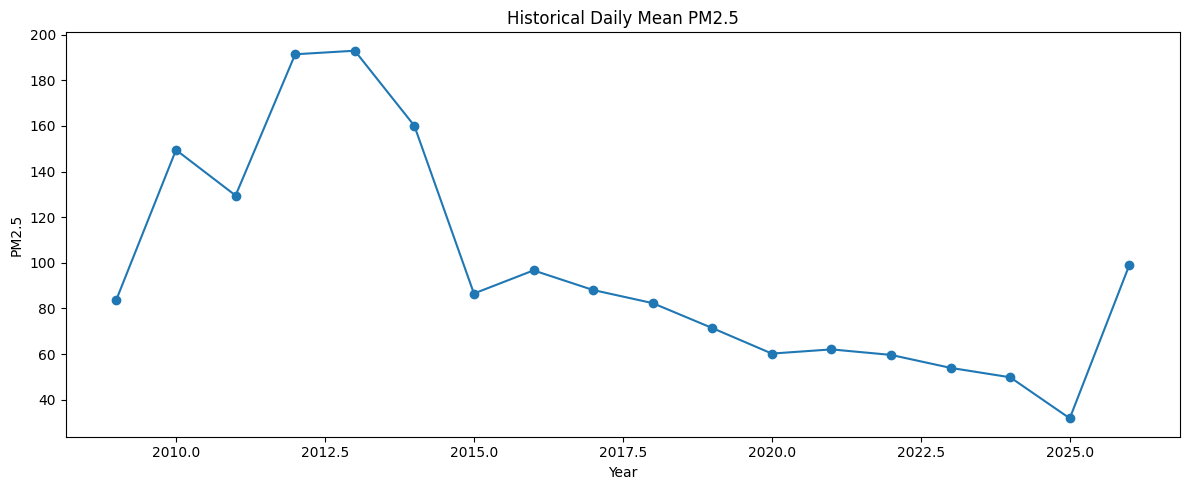

In [ ]:
pm25_yearly = con.sql("""
SELECT
    EXTRACT(YEAR FROM period_start)::INTEGER AS year,
    AVG(mean_value) AS pm25_mean,
    MAX(mean_value) AS pm25_peak
FROM clean_air_daily
WHERE parameter_name = 'PM2.5'
GROUP BY year
ORDER BY year
""").df()

atomic_to_csv(pm25_yearly, ARTIFACT_ROOT / "pm25_yearly.csv")

plt.figure(figsize=(12, 5))
plt.plot(pm25_yearly["year"], pm25_yearly["pm25_mean"], marker="o")
plt.title("Historical Daily Mean PM2.5")
plt.xlabel("Year")
plt.ylabel("PM2.5")
plt.tight_layout()
plt.savefig(VIS_ROOT / "pm25_yearly.png", dpi=160)
plt.show()


In [ ]:
top_cities = con.sql("""
SELECT city_name, COUNT(*) AS observations, COUNT(DISTINCT station_id) AS stations
FROM clean_air_daily
WHERE city_name IS NOT NULL
GROUP BY city_name
ORDER BY observations DESC
LIMIT 20
""").df()

atomic_to_csv(top_cities, ARTIFACT_ROOT / "top_cities.csv")
display(top_cities)


,city_name,observations,stations
0,Delhi,1135055,39
1,Mumbai,444915,31
2,Hyderabad,311493,15
3,Bengaluru,304533,14
4,Kolkata,193258,8
5,Lucknow,175698,6
6,Chennai,158114,8
7,Patna,154261,6
8,Jaipur,126227,6
9,Ahmedabad,116910,8


# 08 — AQI Estimation

The AQI layer uses the CPCB National AQI breakpoint framework for PM10, PM2.5, NO2, SO2, CO, O3, NH3 and Pb. The overall value is the maximum available sub-index. The project labels this a daily AQI estimate because the source layer is an analytical aggregation rather than an official live CPCB AQI feed.


In [ ]:
AQI_BREAKPOINTS = {
    "PM10": [(0,50,0,50),(51,100,51,100),(101,250,101,200),(251,350,201,300),(351,430,301,400),(430.000001,np.inf,401,500)],
    "PM2.5": [(0,30,0,50),(31,60,51,100),(61,90,101,200),(91,120,201,300),(121,250,301,400),(250.000001,np.inf,401,500)],
    "NO2": [(0,40,0,50),(41,80,51,100),(81,180,101,200),(181,280,201,300),(281,400,301,400),(400.000001,np.inf,401,500)],
    "O3": [(0,50,0,50),(50.000001,100,51,100),(100.000001,168,101,200),(168.000001,208,201,300),(208.000001,748,301,400),(748.000001,np.inf,401,500)],
    "CO": [(0,1.0,0,50),(1.000001,2.0,51,100),(2.000001,10.0,101,200),(10.000001,17.0,201,300),(17.000001,34.0,301,400),(34.000001,np.inf,401,500)],
    "SO2": [(0,40,0,50),(41,80,51,100),(81,380,101,200),(381,800,201,300),(801,1600,301,400),(1600.000001,np.inf,401,500)],
    "NH3": [(0,200,0,50),(201,400,51,100),(401,800,101,200),(801,1200,201,300),(1201,1800,301,400),(1800.000001,np.inf,401,500)],
    "Pb": [(0,0.5,0,50),(0.500001,1.0,51,100),(1.000001,2.0,101,200),(2.000001,3.0,201,300),(3.000001,3.5,301,400),(3.500001,np.inf,401,500)]
}

AQI_CATEGORIES = [(0,50,"Good"),(51,100,"Satisfactory"),(101,200,"Moderate"),(201,300,"Poor"),(301,400,"Very Poor"),(401,500,"Severe")]


def subindex(value, pollutant):
    if pd.isna(value) or pollutant not in AQI_BREAKPOINTS:
        return np.nan
    for c_low, c_high, i_low, i_high in AQI_BREAKPOINTS[pollutant]:
        if c_low <= value <= c_high:
            if np.isinf(c_high):
                return float(i_high)
            return i_low + (value - c_low) * (i_high - i_low) / (c_high - c_low)
    return np.nan

def aqi_category(value):
    if pd.isna(value):
        return "Unknown"
    for low, high, label in AQI_CATEGORIES:
        if low <= value <= high:
            return label
    return "Severe"

print("AQI rules ready.")


AQI rules ready.


In [ ]:
AQI_PATH = TOP_DATA_ROOT / "city_daily_aqi.parquet"

if not FORCE_REBUILD and artifact_exists(AQI_PATH):
    aqi_wide = pd.read_parquet(AQI_PATH)
    print("Loaded AQI checkpoint.")
else:
    AQI_POLLUTANTS = ["PM10","PM2.5","NO2","SO2","CO","O3","NH3","Pb"]
    city_names = top_cities["city_name"].dropna().astype(str).head(15).tolist()
    city_sql = ",".join("'" + c.replace("'", "''") + "'" for c in city_names)
    pollutant_sql = ",".join("'" + p + "'" for p in AQI_POLLUTANTS)

    aqi_long = con.sql(f"""
    SELECT
        city_name,
        period_start::DATE AS pollution_date,
        parameter_name,
        AVG(mean_value) AS concentration
    FROM clean_air_daily
    WHERE city_name IN ({city_sql})
      AND parameter_name IN ({pollutant_sql})
    GROUP BY city_name, pollution_date, parameter_name
    ORDER BY city_name, pollution_date, parameter_name
    """).df()

    aqi_wide = (aqi_long.pivot_table(index=["city_name","pollution_date"], columns="parameter_name", values="concentration", aggfunc="mean").reset_index())

    for pollutant in AQI_POLLUTANTS:
        if pollutant not in aqi_wide.columns:
            aqi_wide[pollutant] = np.nan

    for pollutant in AQI_POLLUTANTS:
        aqi_wide[f"{pollutant}_subindex"] = aqi_wide[pollutant].apply(lambda x: subindex(x, pollutant))

    sub_cols = [f"{p}_subindex" for p in AQI_POLLUTANTS]
    aqi_wide["aqi_estimate"] = aqi_wide[sub_cols].max(axis=1)
    aqi_wide["dominant_pollutant"] = aqi_wide[sub_cols].idxmax(axis=1).str.replace("_subindex", "", regex=False)
    aqi_wide["aqi_category"] = aqi_wide["aqi_estimate"].apply(aqi_category)
    aqi_wide["valid_pollutant_count"] = aqi_wide[AQI_POLLUTANTS].notna().sum(axis=1)
    aqi_wide["aqi_valid"] = aqi_wide["aqi_estimate"].notna()

    atomic_to_parquet(aqi_wide, AQI_PATH)
    print("AQI checkpoint created.")

print("AQI rows:", len(aqi_wide))
display(aqi_wide[["city_name","pollution_date","aqi_estimate","aqi_category","dominant_pollutant","valid_pollutant_count"]].head(20))
save_state("aqi", details={"rows":len(aqi_wide),"valid_rows":int(aqi_wide["aqi_valid"].sum())})


Loaded AQI checkpoint.
AQI rows: 64767


,city_name,pollution_date,aqi_estimate,aqi_category,dominant_pollutant,valid_pollutant_count
0,Agra,2016-01-01,500.000000,Severe,PM2.5,5
1,Agra,2016-01-02,500.000000,Severe,PM2.5,5
2,Agra,2016-01-03,383.830320,Very Poor,PM2.5,5
3,Agra,2016-01-04,500.000000,Severe,PM2.5,5
4,Agra,2016-01-05,500.000000,Severe,PM2.5,5
5,Agra,2016-01-06,500.000000,Severe,PM2.5,5
6,Agra,2016-01-07,500.000000,Severe,PM2.5,5
7,Agra,2016-01-08,500.000000,Severe,PM2.5,5
8,Agra,2016-01-09,311.642820,Very Poor,PM2.5,5
9,Agra,2016-01-10,322.395000,Very Poor,PM2.5,5


/tmp/ipykernel_549/4141818168.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "updated_at": datetime.utcnow().isoformat(),


# 09 — AQI Analytics


In [ ]:
aqi_city_summary = (
    aqi_wide[aqi_wide["aqi_valid"]]
    .groupby("city_name")
    .agg(
        average_aqi=("aqi_estimate","mean"),
        median_aqi=("aqi_estimate","median"),
        maximum_aqi=("aqi_estimate","max"),
        observations=("aqi_estimate","count")
    )
    .reset_index()
    .sort_values("average_aqi", ascending=False)
)

atomic_to_csv(aqi_city_summary, ARTIFACT_ROOT / "aqi_city_summary.csv")
display(aqi_city_summary)


,city_name,average_aqi,median_aqi,maximum_aqi,observations
4,Delhi,269.027863,290.154410,500.0,5998
6,Gurugram,203.862229,178.368943,500.0,2915
13,Patna,194.140226,151.914780,500.0,3505
10,Lucknow,183.968015,156.832710,500.0,5913
5,Faridabad,174.746112,136.449211,500.0,4997
11,Moradabad,165.693618,122.908578,500.0,2669
14,Varanasi,150.904101,96.692497,500.0,4737
0,Agra,145.400830,98.961566,500.0,3417
2,Bengaluru,141.805305,99.600158,500.0,5938
8,Jaipur,124.385610,113.169745,500.0,2880


In [26]:
aqicat = aqi_wide[aqi_wide["aqi_valid"]].groupby("aqi_category").size().reset_index(name="days")
atomic_to_csv(aqicat, ARTIFACT_ROOT / "aqi_category_summary.csv")
display(aqicat)


,aqi_category,days
0,Good,9327
1,Moderate,18165
2,Poor,7172
3,Satisfactory,19648
4,Severe,1936
5,Very Poor,8505


# 10 — Feature Engineering


In [27]:
FEATURE_DATASET = FEATURE_ROOT / "feature_dataset.parquet"

if not FORCE_REBUILD and artifact_exists(FEATURE_DATASET):
    feature_frame = pd.read_parquet(FEATURE_DATASET)
    print("Loaded feature engineering checkpoint.")
else:
    feature_frame = aqi_wide.copy()
    feature_frame["pollution_date"] = pd.to_datetime(feature_frame["pollution_date"])
    feature_frame = feature_frame.sort_values(["city_name","pollution_date"]).reset_index(drop=True)

    AQI_POLLUTANTS = ["PM10","PM2.5","NO2","SO2","CO","O3","NH3","Pb"]
    for p in AQI_POLLUTANTS:
        if p not in feature_frame.columns:
            feature_frame[p] = np.nan
        feature_frame[p] = pd.to_numeric(feature_frame[p], errors="coerce")

    feature_frame["year"] = feature_frame["pollution_date"].dt.year
    feature_frame["month"] = feature_frame["pollution_date"].dt.month
    feature_frame["day_of_week"] = feature_frame["pollution_date"].dt.dayofweek
    feature_frame["day_of_year"] = feature_frame["pollution_date"].dt.dayofyear
    feature_frame["is_weekend"] = feature_frame["day_of_week"].isin([5,6]).astype(int)
    feature_frame["month_sin"] = np.sin(2*np.pi*feature_frame["month"]/12)
    feature_frame["month_cos"] = np.cos(2*np.pi*feature_frame["month"]/12)
    feature_frame["dow_sin"] = np.sin(2*np.pi*feature_frame["day_of_week"]/7)
    feature_frame["dow_cos"] = np.cos(2*np.pi*feature_frame["day_of_week"]/7)

    for p in ["PM2.5","PM10","NO2"]:
        safe = p.replace(".","_")
        for lag in [1,3,7,14]:
            feature_frame[f"{safe}_lag_{lag}"] = feature_frame.groupby("city_name")[p].shift(lag)
        for window in [3,7,14]:
            feature_frame[f"{safe}_rolling_mean_{window}"] = feature_frame.groupby("city_name")[p].transform(lambda s: s.shift(1).rolling(window).mean())
            feature_frame[f"{safe}_rolling_std_{window}"] = feature_frame.groupby("city_name")[p].transform(lambda s: s.shift(1).rolling(window).std())

    feature_frame["aqi_lag_1"] = feature_frame.groupby("city_name")["aqi_estimate"].shift(1)
    feature_frame["aqi_lag_3"] = feature_frame.groupby("city_name")["aqi_estimate"].shift(3)
    feature_frame["aqi_lag_7"] = feature_frame.groupby("city_name")["aqi_estimate"].shift(7)
    feature_frame["aqi_rolling_mean_3"] = feature_frame.groupby("city_name")["aqi_estimate"].transform(lambda s: s.shift(1).rolling(3).mean())
    feature_frame["aqi_rolling_mean_7"] = feature_frame.groupby("city_name")["aqi_estimate"].transform(lambda s: s.shift(1).rolling(7).mean())
    feature_frame["target_aqi_next_day"] = feature_frame.groupby("city_name")["aqi_estimate"].shift(-1)
    feature_frame["city_code"] = feature_frame["city_name"].astype("category").cat.codes
    atomic_to_parquet(feature_frame, FEATURE_DATASET)
    print("Feature engineering checkpoint created.")

print("Feature rows:", len(feature_frame))
print("Feature columns:", len(feature_frame.columns))


Loaded feature engineering checkpoint.
Feature rows: 64767
Feature columns: 69


# 11 — ML Dataset Preparation


In [29]:
excluded = {
    "city_name",
    "pollution_date",
    "aqi_estimate",
    "aqi_category",
    "dominant_pollutant",
    "target_aqi_next_day"
}

candidate_features = [
    c for c in feature_frame.columns
    if c not in excluded
    and pd.api.types.is_numeric_dtype(feature_frame[c])
]

ml_frame = feature_frame[
    candidate_features + ["target_aqi_next_day"]
].dropna(
    subset=["target_aqi_next_day"]
).copy()

if len(ml_frame) > MAX_ML_ROWS:
    ml_frame = ml_frame.iloc[-MAX_ML_ROWS:].copy()

X_all = ml_frame[candidate_features]
y_all = ml_frame["target_aqi_next_day"]

split = max(int(len(ml_frame) * 0.8), 1)

X_train = X_all.iloc[:split].copy()
X_test = X_all.iloc[split:].copy()
y_train = y_all.iloc[:split].copy()
y_test = y_all.iloc[split:].copy()

valid_features = [
    c for c in candidate_features
    if X_train[c].notna().any()
]

X_train = X_train[valid_features]
X_test = X_test[valid_features]

candidate_features = valid_features

imputer = SimpleImputer(strategy="median")

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=candidate_features,
    index=X_train.index
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=candidate_features,
    index=X_test.index
)

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imp),
    columns=candidate_features,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imp),
    columns=candidate_features,
    index=X_test.index
)

joblib.dump(
    {
        "imputer": imputer,
        "scaler": scaler,
        "features": candidate_features
    },
    FEATURE_ROOT / "preprocessing_bundle.joblib"
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Numeric features:", len(candidate_features))
print("Removed all-missing features:", [
    c for c in X_all.columns if c not in candidate_features
])

Training rows: 20000
Test rows: 5000
Numeric features: 61
Removed all-missing features: ['Pb', 'Pb_subindex']


# 12 — Feature Selection


In [31]:
SELECTED_FEATURES_JSON = FEATURE_ROOT / "selected_features.json"
SELECTED_FEATURE_DATASET = FEATURE_ROOT / "selected_feature_dataset.parquet"

if not FORCE_REBUILD and artifact_exists(SELECTED_FEATURES_JSON) and artifact_exists(SELECTED_FEATURE_DATASET):
    selected_features = json.loads(
        SELECTED_FEATURES_JSON.read_text(encoding="utf-8")
    )
    selected_feature_dataset = pd.read_parquet(
        SELECTED_FEATURE_DATASET
    )
    print("Loaded feature selection checkpoint.")

else:
    excluded = {
        "city_name",
        "pollution_date",
        "aqi_estimate",
        "aqi_category",
        "dominant_pollutant",
        "target_aqi_next_day"
    }

    candidate_features = [
        c for c in feature_frame.columns
        if c not in excluded
        and pd.api.types.is_numeric_dtype(feature_frame[c])
    ]

    ml_frame = feature_frame[
        candidate_features + ["target_aqi_next_day"]
    ].dropna(
        subset=["target_aqi_next_day"]
    ).copy()

    if len(ml_frame) > MAX_ML_ROWS:
        ml_frame = ml_frame.iloc[-MAX_ML_ROWS:].copy()

    X_all = ml_frame[candidate_features]
    y_all = ml_frame["target_aqi_next_day"]

    split = max(int(len(ml_frame) * 0.8), 1)

    X_train = X_all.iloc[:split].copy()
    X_test = X_all.iloc[split:].copy()
    y_train = y_all.iloc[:split].copy()
    y_test = y_all.iloc[split:].copy()

    valid_features = [
        c for c in candidate_features
        if X_train[c].notna().any()
    ]

    removed_features = [
        c for c in candidate_features
        if c not in valid_features
    ]

    candidate_features = valid_features

    X_train = X_train[candidate_features]
    X_test = X_test[candidate_features]

    imputer = SimpleImputer(strategy="median")

    X_train_imp = pd.DataFrame(
        imputer.fit_transform(X_train),
        columns=candidate_features,
        index=X_train.index
    )

    X_test_imp = pd.DataFrame(
        imputer.transform(X_test),
        columns=candidate_features,
        index=X_test.index
    )

    scaler = StandardScaler()

    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train_imp),
        columns=candidate_features,
        index=X_train.index
    )

    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test_imp),
        columns=candidate_features,
        index=X_test.index
    )

    joblib.dump(
        {
            "imputer": imputer,
            "scaler": scaler,
            "features": candidate_features
        },
        FEATURE_ROOT / "preprocessing_bundle.joblib"
    )

    corr = (
        ml_frame[candidate_features + ["target_aqi_next_day"]]
        .corr(numeric_only=True)["target_aqi_next_day"]
        .drop("target_aqi_next_day")
        .abs()
        .sort_values(ascending=False)
    )

    mi_k = min(15, len(candidate_features))

    mi_selector = SelectKBest(
        mutual_info_regression,
        k=mi_k
    )

    mi_selector.fit(
        X_train_imp,
        y_train
    )

    selected_mi = (
        pd.DataFrame({
            "feature": candidate_features,
            "score": mi_selector.scores_
        })
        .sort_values("score", ascending=False)
        .head(mi_k)["feature"]
        .tolist()
    )

    rfe_k = min(12, len(candidate_features))

    rfe = RFE(
        RandomForestRegressor(
            n_estimators=50,
            max_depth=10,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS
        ),
        n_features_to_select=rfe_k,
        step=0.2
    )

    rfe.fit(
        X_train_imp,
        y_train
    )

    selected_rfe = [
        f
        for f, flag in zip(
            candidate_features,
            rfe.support_
        )
        if flag
    ]

    tree = RandomForestRegressor(
        n_estimators=75,
        max_depth=12,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS
    )

    tree.fit(
        X_train_imp,
        y_train
    )

    selected_tree = (
        pd.DataFrame({
            "feature": candidate_features,
            "importance": tree.feature_importances_
        })
        .sort_values("importance", ascending=False)
        .head(min(15, len(candidate_features)))["feature"]
        .tolist()
    )

    selected_features = []

    for f in selected_mi + selected_rfe + selected_tree:
        if f not in selected_features:
            selected_features.append(f)

    selected_features = selected_features[
        :min(18, len(selected_features))
    ]

    selected_feature_dataset = feature_frame[
        ["city_name", "pollution_date"]
        + selected_features
        + ["target_aqi_next_day"]
    ].copy()

    atomic_to_parquet(
        selected_feature_dataset,
        SELECTED_FEATURE_DATASET
    )

    save_json(
        selected_features,
        SELECTED_FEATURES_JSON
    )

    correlation_ranking = pd.DataFrame({
        "feature": candidate_features,
        "absolute_correlation": corr.reindex(
            candidate_features
        ).values
    }).sort_values(
        "absolute_correlation",
        ascending=False
    )

    atomic_to_csv(
        correlation_ranking,
        FEATURE_ROOT / "correlation_ranking.csv"
    )

    print("Feature selection checkpoint created.")

    if removed_features:
        print(
            "Removed all-missing features:",
            removed_features
        )

print("Selected features:", len(selected_features))

Feature selection checkpoint created.
Removed all-missing features: ['Pb', 'Pb_subindex']
Selected features: 18


In [32]:
display(pd.DataFrame({"selected_feature":selected_features}))
save_state("feature_selection",details={"selected_features":selected_features})


,selected_feature
0,PM2.5
1,PM2.5_subindex
2,aqi_lag_1
3,aqi_rolling_mean_3
4,PM10
5,aqi_rolling_mean_7
6,PM10_subindex
7,PM2_5_rolling_mean_7
8,PM2_5_lag_1
9,PM2_5_rolling_mean_3


/tmp/ipykernel_549/4141818168.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "updated_at": datetime.utcnow().isoformat(),


# 13 — PCA Feature Extraction


In [34]:
excluded = {
    "city_name",
    "pollution_date",
    "aqi_estimate",
    "aqi_category",
    "dominant_pollutant",
    "target_aqi_next_day"
}

candidate_features = [
    c for c in feature_frame.columns
    if c not in excluded
    and pd.api.types.is_numeric_dtype(feature_frame[c])
]

ml_frame = feature_frame[
    candidate_features + ["target_aqi_next_day"]
].dropna(
    subset=["target_aqi_next_day"]
).copy()

if len(ml_frame) > MAX_ML_ROWS:
    ml_frame = ml_frame.iloc[-MAX_ML_ROWS:].copy()

X_all = ml_frame[candidate_features]
y_all = ml_frame["target_aqi_next_day"]

split = max(int(len(ml_frame) * 0.8), 1)

X_train = X_all.iloc[:split].copy()
X_test = X_all.iloc[split:].copy()

y_train = y_all.iloc[:split].copy()
y_test = y_all.iloc[split:].copy()

all_features = candidate_features.copy()

candidate_features = [
    c for c in candidate_features
    if X_train[c].notna().any()
]

removed_features = [
    c for c in all_features
    if c not in candidate_features
]

X_train = X_train[candidate_features]
X_test = X_test[candidate_features]

imputer = SimpleImputer(strategy="median")

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=candidate_features,
    index=X_train.index
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=candidate_features,
    index=X_test.index
)

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imp),
    columns=candidate_features,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imp),
    columns=candidate_features,
    index=X_test.index
)

joblib.dump(
    {
        "imputer": imputer,
        "scaler": scaler,
        "features": candidate_features
    },
    FEATURE_ROOT / "preprocessing_bundle.joblib"
)

print("ML dataset restored.")
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Valid features:", len(candidate_features))
print("Removed all-missing features:", removed_features)

ML dataset restored.
Training rows: 20000
Test rows: 5000
Valid features: 61
Removed all-missing features: ['Pb', 'Pb_subindex']


In [35]:
PCA_PATH = FEATURE_ROOT / "pca_components.parquet"
PCA_VAR_PATH = FEATURE_ROOT / "pca_variance.csv"
PCA_MODEL_PATH = MODEL_ROOT / "pca_bundle.joblib"

if not FORCE_REBUILD and artifact_exists(PCA_PATH) and artifact_exists(PCA_VAR_PATH) and artifact_exists(PCA_MODEL_PATH):
    pca_table=pd.read_parquet(PCA_PATH)
    pca_variance=pd.read_csv(PCA_VAR_PATH)
    pca_saved=joblib.load(PCA_MODEL_PATH)
    pca=pca_saved["pca"]
    pca_scaler=pca_saved["scaler"]
    print("Loaded PCA checkpoint.")
else:
    pca_imputer=SimpleImputer(strategy="median")
    pca_matrix=pca_imputer.fit_transform(ml_frame[selected_features])
    pca_scaler=StandardScaler()
    pca_matrix_scaled=pca_scaler.fit_transform(pca_matrix)
    pca=PCA(n_components=min(8,len(selected_features)))
    pca_values=pca.fit_transform(pca_matrix_scaled)
    pca_table=pd.DataFrame(pca_values,columns=[f"PC{i+1}" for i in range(pca_values.shape[1])])
    pca_table["target_aqi_next_day"]=ml_frame["target_aqi_next_day"].values
    pca_variance=pd.DataFrame({"component":[f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],"explained_variance_ratio":pca.explained_variance_ratio_,"cumulative_variance":np.cumsum(pca.explained_variance_ratio_)})
    atomic_to_parquet(pca_table,PCA_PATH)
    atomic_to_csv(pca_variance,PCA_VAR_PATH)
    joblib.dump({"pca":pca,"scaler":pca_scaler,"features":selected_features},PCA_MODEL_PATH)
    print("PCA checkpoint created.")

display(pca_variance)


PCA checkpoint created.


,component,explained_variance_ratio,cumulative_variance
0,PC1,0.641902,0.641902
1,PC2,0.123250,0.765152
2,PC3,0.090604,0.855756
3,PC4,0.055955,0.911711
4,PC5,0.029850,0.941561
5,PC6,0.015535,0.957096
6,PC7,0.013352,0.970448
7,PC8,0.007272,0.977720


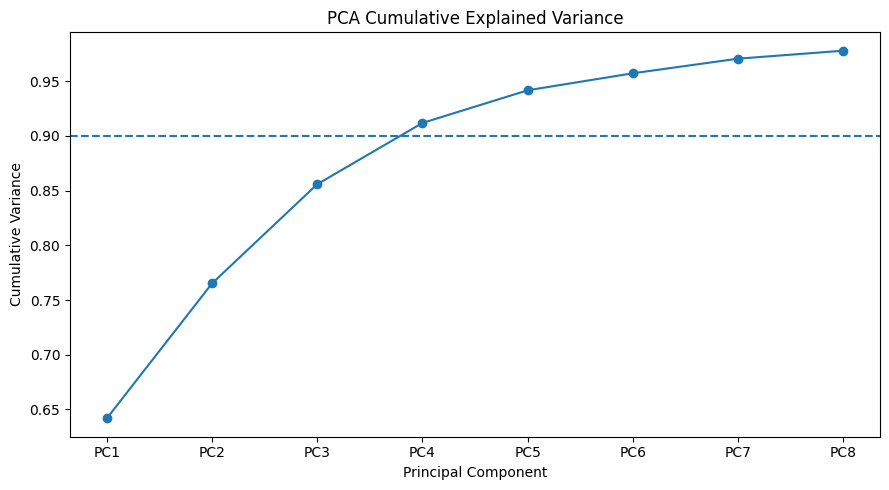

In [36]:
plt.figure(figsize=(9,5))
plt.plot(pca_variance["component"], pca_variance["cumulative_variance"], marker="o")
plt.axhline(0.9, linestyle="--")
plt.title("PCA Cumulative Explained Variance")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance")
plt.tight_layout()
plt.savefig(VIS_ROOT / "pca_variance.png", dpi=160)
plt.show()


# 14 — Station Clustering


In [37]:
CLUSTER_PATH=MINING_ROOT/"station_cluster_results.parquet"
CLUSTER_MODEL_PATH=MODEL_ROOT/"station_clustering_bundle.joblib"
CLUSTER_SEL_PATH=MINING_ROOT/"cluster_selection.csv"

if not FORCE_REBUILD and artifact_exists(CLUSTER_PATH) and artifact_exists(CLUSTER_MODEL_PATH) and artifact_exists(CLUSTER_SEL_PATH):
    station_profiles=pd.read_parquet(CLUSTER_PATH)
    cluster_bundle=joblib.load(CLUSTER_MODEL_PATH)
    cluster_features=cluster_bundle["features"]
    best_k=int(station_profiles["kmeans_cluster"].nunique())
    k_results=pd.read_csv(CLUSTER_SEL_PATH)
    print("Loaded clustering checkpoint.")
else:
    station_profiles=con.sql("""
    SELECT station_id,MAX(station_name) AS station_name,MAX(city_name) AS city_name,MAX(state_name) AS state_name,
           AVG(mean_value) FILTER (WHERE parameter_name='PM2.5') AS avg_pm25,
           AVG(mean_value) FILTER (WHERE parameter_name='PM10') AS avg_pm10,
           AVG(mean_value) FILTER (WHERE parameter_name='NO2') AS avg_no2,
           AVG(mean_value) FILTER (WHERE parameter_name='SO2') AS avg_so2,
           AVG(mean_value) FILTER (WHERE parameter_name='CO') AS avg_co,
           AVG(mean_value) FILTER (WHERE parameter_name='O3') AS avg_o3,
           STDDEV_SAMP(mean_value) FILTER (WHERE parameter_name='PM2.5') AS std_pm25,
           MAX(max_value) FILTER (WHERE parameter_name='PM2.5') AS peak_pm25,
           COUNT(*) FILTER (WHERE parameter_name='PM2.5') AS pm25_observations
    FROM clean_air_daily GROUP BY station_id HAVING COUNT(*)>10
    """).df()
    cluster_features=[c for c in station_profiles.columns if c.startswith("avg_") or c.startswith("std_") or c.startswith("peak_")]
    cluster_imputer=SimpleImputer(strategy="median")
    cluster_matrix=cluster_imputer.fit_transform(station_profiles[cluster_features])
    cluster_scaler=StandardScaler()
    cluster_matrix_scaled=cluster_scaler.fit_transform(cluster_matrix)
    rows=[]
    for k in range(2,7):
        km=KMeans(n_clusters=k,random_state=RANDOM_STATE,n_init=10)
        labels=km.fit_predict(cluster_matrix_scaled)
        rows.append({"k":k,"inertia":km.inertia_,"silhouette":silhouette_score(cluster_matrix_scaled,labels),"davies_bouldin":davies_bouldin_score(cluster_matrix_scaled,labels)})
    k_results=pd.DataFrame(rows)
    best_k=int(k_results.sort_values(["silhouette","davies_bouldin"],ascending=[False,True]).iloc[0]["k"])
    kmeans=KMeans(n_clusters=best_k,random_state=RANDOM_STATE,n_init=10)
    station_profiles["kmeans_cluster"]=kmeans.fit_predict(cluster_matrix_scaled)
    station_profiles["hierarchical_cluster"]=AgglomerativeClustering(n_clusters=best_k).fit_predict(cluster_matrix_scaled)
    station_profiles["dbscan_cluster"]=DBSCAN(eps=1.2,min_samples=5).fit_predict(cluster_matrix_scaled)
    cluster_profile_table=station_profiles.groupby("kmeans_cluster")[cluster_features].mean().reset_index()
    atomic_to_parquet(station_profiles,CLUSTER_PATH)
    atomic_to_csv(k_results,CLUSTER_SEL_PATH)
    atomic_to_csv(cluster_profile_table,MINING_ROOT/"cluster_profiles.csv")
    joblib.dump({"kmeans":kmeans,"imputer":cluster_imputer,"scaler":cluster_scaler,"features":cluster_features},CLUSTER_MODEL_PATH)
    print("Clustering checkpoint created.")

display(station_profiles.head(20))
print("Selected K:",best_k)
save_state("clustering",details={"k":best_k,"stations":len(station_profiles)})


Loaded clustering checkpoint.


,station_id,station_name,city_name,state_name,avg_pm25,avg_pm10,avg_no2,avg_so2,avg_co,avg_o3,std_pm25,peak_pm25,pm25_observations,kmeans_cluster,hierarchical_cluster,dbscan_cluster
0,site_1551,Tamaka Ind. Area Kolar,None,None,46.994411,67.680652,11.980138,23.048082,0.642340,16.831691,118.845807,985.00,895,1,0,-1
1,site_1553,"Bapuji Nagar, Bengaluru - KSPCB",Bengaluru,Karnataka,38.763049,75.011234,24.317485,6.538865,0.769854,24.734943,30.305616,898.00,2418,0,0,0
2,site_1557,"Chikkaballapur Rural, Chikkaballapur - KSPCB",Chikkaballapur,Karnataka,29.217420,63.447522,19.564250,10.957780,0.531543,26.100796,18.402940,658.25,2300,0,0,0
3,site_1560,"Bawana, Delhi - DPCC",Delhi,Delhi,119.293714,237.135024,24.983334,9.109997,1.176387,33.106699,91.405660,994.00,2508,1,1,0
4,site_1565,Lal Bahadur Shastri Nagar Kalaburagi,None,None,41.023533,80.728317,17.977843,15.715558,0.538868,28.050359,58.348919,985.00,1815,0,0,0
5,site_157,"IGSC Planetarium Complex, Patna - BSPCB",Patna,Bihar,104.590477,NaN,45.246757,16.138329,1.315335,37.226353,82.589803,994.00,3139,1,1,-1
6,site_158,"Muzaffarpur Collectorate, Muzaffarpur - BSPCB",Muzaffarpur,Bihar,95.100926,NaN,24.339803,14.980601,1.179903,40.130803,86.782286,985.00,3252,1,1,-1
7,site_161,"Sector-6, Panchkula - HSPCB",Panchkula,Haryana,51.293670,NaN,20.800069,9.778369,0.624440,36.930022,29.690957,999.99,2851,0,0,0
8,site_162,"BTM Layout, Bengaluru - CPCB",Bengaluru,Karnataka,33.725127,64.588402,22.139177,10.586906,0.795743,33.086765,29.242175,999.99,3148,0,0,0
9,site_165,"City Railway Station, Bengaluru - KSPCB",Bengaluru,Karnataka,NaN,93.899342,35.334928,11.208859,1.357409,NaN,NaN,NaN,0,0,0,0


Selected K: 2


/tmp/ipykernel_549/4141818168.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "updated_at": datetime.utcnow().isoformat(),


In [39]:
CLUSTER_PATH = MINING_ROOT / "station_cluster_results.parquet"
CLUSTER_MODEL_PATH = MODEL_ROOT / "station_clustering_bundle.joblib"

cluster_bundle = joblib.load(CLUSTER_MODEL_PATH)

cluster_features = cluster_bundle["features"]
cluster_imputer = cluster_bundle["imputer"]
cluster_scaler = cluster_bundle["scaler"]

station_profiles = pd.read_parquet(CLUSTER_PATH)

cluster_matrix = cluster_imputer.transform(
    station_profiles[cluster_features]
)

cluster_matrix_scaled = cluster_scaler.transform(
    cluster_matrix
)

if "k_results" not in globals():
    CLUSTER_SEL_PATH = MINING_ROOT / "cluster_selection.csv"
    k_results = pd.read_csv(CLUSTER_SEL_PATH)

best_k = int(
    k_results.sort_values(
        ["silhouette", "davies_bouldin"],
        ascending=[False, True]
    ).iloc[0]["k"]
)

kmeans = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=10
)

station_profiles["kmeans_cluster"] = kmeans.fit_predict(
    cluster_matrix_scaled
)

hierarchical = AgglomerativeClustering(
    n_clusters=best_k
)

station_profiles["hierarchical_cluster"] = hierarchical.fit_predict(
    cluster_matrix_scaled
)

dbscan = DBSCAN(
    eps=1.2,
    min_samples=5
)

station_profiles["dbscan_cluster"] = dbscan.fit_predict(
    cluster_matrix_scaled
)

cluster_profile_table = (
    station_profiles
    .groupby("kmeans_cluster")[cluster_features]
    .mean()
    .reset_index()
)

atomic_to_parquet(
    station_profiles,
    CLUSTER_PATH
)

atomic_to_csv(
    cluster_profile_table,
    MINING_ROOT / "cluster_profiles.csv"
)

joblib.dump(
    {
        "kmeans": kmeans,
        "imputer": cluster_imputer,
        "scaler": cluster_scaler,
        "features": cluster_features
    },
    CLUSTER_MODEL_PATH
)

display(cluster_profile_table)

print("Selected K:", best_k)
print("Stations:", len(station_profiles))

save_state(
    "clustering",
    details={
        "k": best_k,
        "stations": len(station_profiles)
    }
)

,kmeans_cluster,avg_pm25,avg_pm10,avg_no2,avg_so2,avg_co,avg_o3,std_pm25,peak_pm25
0,0,39.525266,85.880053,19.625051,12.095911,0.787867,29.232926,27.609476,711.886225
1,1,84.431914,173.476093,35.159234,14.067708,1.613134,33.654288,68.203108,952.680959


Selected K: 2
Stations: 558


/tmp/ipykernel_549/4141818168.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "updated_at": datetime.utcnow().isoformat(),


# 15 — Anomaly Detection


In [40]:
ANOMALY_PATH=MINING_ROOT/"anomalies.parquet"
ISO_MODEL_PATH=MODEL_ROOT/"anomaly_isolation_forest.joblib"

if not FORCE_REBUILD and artifact_exists(ANOMALY_PATH):
    anomaly_data=pd.read_parquet(ANOMALY_PATH)
    if artifact_exists(ISO_MODEL_PATH):
        iso=joblib.load(ISO_MODEL_PATH)
    print("Loaded anomaly checkpoint.")
else:
    anomaly_data=aqi_wide[aqi_wide["aqi_valid"]].copy()
    anomaly_data["zscore"]=anomaly_data.groupby("city_name")["aqi_estimate"].transform(lambda s:(s-s.mean())/s.std())
    q1=anomaly_data.groupby("city_name")["aqi_estimate"].transform("quantile",0.25)
    q3=anomaly_data.groupby("city_name")["aqi_estimate"].transform("quantile",0.75)
    anomaly_data["iqr_flag"]=((anomaly_data["aqi_estimate"]<q1-1.5*(q3-q1))|(anomaly_data["aqi_estimate"]>q3+1.5*(q3-q1))).astype(int)
    iso_columns=[p for p in AQI_POLLUTANTS if p in anomaly_data.columns]
    iso_imputer=SimpleImputer(strategy="median")
    iso_frame=iso_imputer.fit_transform(anomaly_data[iso_columns])
    iso=IsolationForest(n_estimators=100,random_state=RANDOM_STATE,n_jobs=N_JOBS,contamination="auto")
    iso_labels=iso.fit_predict(iso_frame)
    anomaly_data["isolation_flag"]=(iso_labels==-1).astype(int)
    anomaly_data["anomaly_score"]=anomaly_data["iqr_flag"]+anomaly_data["isolation_flag"]
    anomaly_data["anomaly_label"]=np.select([anomaly_data["anomaly_score"]>=2,anomaly_data["anomaly_score"]==1],["Strong anomaly","Potential anomaly"],default="Normal")
    atomic_to_parquet(anomaly_data,ANOMALY_PATH)
    joblib.dump({"model":iso,"imputer":iso_imputer,"features":iso_columns},ISO_MODEL_PATH)
    print("Anomaly checkpoint created.")

display(anomaly_data[["city_name","pollution_date","aqi_estimate","zscore","anomaly_score","anomaly_label"]].sort_values("anomaly_score",ascending=False).head(30))


Loaded anomaly checkpoint.


,city_name,pollution_date,aqi_estimate,zscore,anomaly_score,anomaly_label
5042,Ahmedabad,2018-10-09,331.771541,2.856438,2,Strong anomaly
62023,Varanasi,2017-11-29,500.000000,2.774311,2,Strong anomaly
62022,Varanasi,2017-11-28,500.000000,2.774311,2,Strong anomaly
5041,Ahmedabad,2018-10-08,297.544914,2.393736,2,Strong anomaly
62019,Varanasi,2017-11-25,500.000000,2.774311,2,Strong anomaly
38180,Jaipur,2017-10-26,314.792810,2.964557,2,Strong anomaly
15105,Chennai,2014-08-13,316.916429,2.695600,2,Strong anomaly
62005,Varanasi,2017-11-11,500.000000,2.774311,2,Strong anomaly
50855,Moradabad,2020-01-27,500.000000,2.883691,2,Strong anomaly
62003,Varanasi,2017-11-09,500.000000,2.774311,2,Strong anomaly


# 16 — Association Analysis

Pollutant co-occurrence is evaluated using support, confidence and lift on city-day records where pollutant concentration is above that city's median.


In [41]:
ASSOCIATION_PATH=MINING_ROOT/"association_rules.csv"
if not FORCE_REBUILD and artifact_exists(ASSOCIATION_PATH):
    association_rules=pd.read_csv(ASSOCIATION_PATH)
    print("Loaded association-analysis checkpoint.")
else:
    association_base=aqi_wide[aqi_wide["aqi_valid"]].copy()
    transactions=[]
    for pollutant in AQI_POLLUTANTS:
        if pollutant in association_base.columns:
            threshold=association_base.groupby("city_name")[pollutant].transform("median")
            association_base[f"high_{pollutant}"]=association_base[pollutant]>threshold
    for _,row in association_base.iterrows():
        transactions.append([p for p in AQI_POLLUTANTS if f"high_{p}" in association_base.columns and bool(row[f"high_{p}"])])
    pair_counts={}; item_counts={}; total=max(len(transactions),1)
    for items in transactions:
        for item in set(items): item_counts[item]=item_counts.get(item,0)+1
        u=sorted(set(items))
        for i in range(len(u)):
            for j in range(i+1,len(u)):
                pair=(u[i],u[j]); pair_counts[pair]=pair_counts.get(pair,0)+1
    rules=[]
    for (a,b),count in pair_counts.items():
        support=count/total
        conf_ab=count/max(item_counts.get(a,1),1)
        conf_ba=count/max(item_counts.get(b,1),1)
        expected=(item_counts.get(a,0)/total)*(item_counts.get(b,0)/total)
        lift=support/expected if expected else 0
        rules.append([a,b,support,conf_ab,conf_ba,lift])
    association_rules=pd.DataFrame(rules,columns=["antecedent","consequent","support","confidence_a_to_b","confidence_b_to_a","lift"]).sort_values("lift",ascending=False)
    atomic_to_csv(association_rules,ASSOCIATION_PATH)
    print("Association checkpoint created.")
display(association_rules.head(20))


Loaded association-analysis checkpoint.


,antecedent,consequent,support,confidence_a_to_b,confidence_b_to_a,lift
0,PM10,PM2.5,0.246645,0.799509,0.602861,1.954199
1,NH3,PM10,0.157815,0.487385,0.511564,1.579878
2,NO2,PM10,0.210384,0.445793,0.681968,1.445057
3,NO2,PM2.5,0.276775,0.586472,0.676506,1.433483
4,NH3,PM2.5,0.179636,0.554777,0.439076,1.356011
5,CO,PM2.5,0.238707,0.524428,0.583459,1.281832
6,PM10,SO2,0.185026,0.599770,0.394813,1.279803
7,NH3,NO2,0.195358,0.603329,0.413953,1.278424
8,O3,PM10,0.181582,0.393060,0.588606,1.274120
9,CO,NO2,0.272065,0.597713,0.576491,1.266525


# 17 — AQI Regression

The regression task predicts next-day AQI from historical pollutant and temporal features using a chronological split.


In [42]:
REG_BUNDLE=MODEL_ROOT / "aqi_regression_models.joblib"
REG_METRICS=MODEL_ROOT / "regression_metrics.csv"

if not FORCE_REBUILD and artifact_exists(REG_BUNDLE) and artifact_exists(REG_METRICS):
    reg_saved=joblib.load(REG_BUNDLE)
    regression_models=reg_saved["models"]
    selected_regression_name=reg_saved["selected_model"]
    regression_results=pd.read_csv(REG_METRICS)
    print("Loaded regression checkpoint.")
else:
    regression_models={
        "Linear Regression":LinearRegression(),
        "Random Forest":RandomForestRegressor(n_estimators=100,max_depth=14,random_state=RANDOM_STATE,n_jobs=N_JOBS),
        "Gradient Boosting":GradientBoostingRegressor(n_estimators=100,max_depth=3,learning_rate=0.05,random_state=RANDOM_STATE),
        "XGBoost":XGBRegressor(n_estimators=150,max_depth=5,learning_rate=0.05,subsample=0.85,colsample_bytree=0.85,objective="reg:squarederror",eval_metric="rmse",random_state=RANDOM_STATE,n_jobs=N_JOBS)
    }
    rows=[]
    for name,model in regression_models.items():
        t=time.time()
        if name=="Linear Regression":
            model.fit(X_train_scaled,y_train)
            pred=model.predict(X_test_scaled)
        else:
            model.fit(X_train_imp,y_train)
            pred=model.predict(X_test_imp)
        rows.append({"model":name,"mae":mean_absolute_error(y_test,pred),"rmse":mean_squared_error(y_test,pred)**0.5,"r2":r2_score(y_test,pred),"elapsed_seconds":time.time()-t})
    regression_results=pd.DataFrame(rows).sort_values("rmse")
    selected_regression_name=regression_results.iloc[0]["model"]
    joblib.dump({"models":regression_models,"selected_model":selected_regression_name,"features":candidate_features},REG_BUNDLE)
    atomic_to_csv(regression_results,REG_METRICS)

display(regression_results)
print("Selected regression model:",selected_regression_name)
save_state("regression",details={"selected_model":selected_regression_name})


Loaded regression checkpoint.


,model,mae,rmse,r2,elapsed_seconds
0,XGBoost,30.886467,48.592149,0.840486,4.659962
1,Linear Regression,31.264293,49.327734,0.835620,0.161849
2,Random Forest,31.245789,49.481688,0.834592,238.878432
3,Gradient Boosting,32.065572,49.488304,0.834548,124.201019


Selected regression model: XGBoost


/tmp/ipykernel_549/4141818168.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "updated_at": datetime.utcnow().isoformat(),


# 18 — AQI Classification


In [43]:
classification_data=feature_frame[feature_frame["aqi_category"].isin(["Good","Satisfactory","Moderate","Poor","Very Poor","Severe"])].copy()
classification_data["target_category"]=classification_data.groupby("city_name")["aqi_category"].shift(-1)
classification_data=classification_data.dropna(subset=["target_category"])
classification_data=classification_data[candidate_features+["target_category"]]

if len(classification_data)>MAX_ML_ROWS:
    classification_data=classification_data.iloc[-MAX_ML_ROWS:].copy()

X_cls=classification_data[candidate_features]
label_encoder=LabelEncoder()
y_cls=label_encoder.fit_transform(classification_data["target_category"])
cls_split=max(int(len(classification_data)*0.8),1)
X_cls_train=X_cls.iloc[:cls_split].copy()
X_cls_test=X_cls.iloc[cls_split:].copy()
y_cls_train=pd.Series(y_cls[:cls_split],index=X_cls_train.index)
y_cls_test=pd.Series(y_cls[cls_split:],index=X_cls_test.index)

cls_imputer=SimpleImputer(strategy="median")
X_cls_train_imp=pd.DataFrame(cls_imputer.fit_transform(X_cls_train),columns=candidate_features,index=X_cls_train.index)
X_cls_test_imp=pd.DataFrame(cls_imputer.transform(X_cls_test),columns=candidate_features,index=X_cls_test.index)
cls_scaler=StandardScaler()
X_cls_train_scaled=pd.DataFrame(cls_scaler.fit_transform(X_cls_train_imp),columns=candidate_features,index=X_cls_train.index)
X_cls_test_scaled=pd.DataFrame(cls_scaler.transform(X_cls_test_imp),columns=candidate_features,index=X_cls_test.index)

CLS_BUNDLE=MODEL_ROOT / "aqi_classification_models.joblib"
CLS_METRICS=MODEL_ROOT / "classification_metrics.csv"

if not FORCE_REBUILD and artifact_exists(CLS_BUNDLE) and artifact_exists(CLS_METRICS):
    cls_saved=joblib.load(CLS_BUNDLE)
    classification_models=cls_saved["models"]
    selected_classification_name=cls_saved["selected_model"]
    classification_results=pd.read_csv(CLS_METRICS)
    label_encoder=cls_saved.get("label_encoder")
    print("Loaded classification checkpoint.")
else:
    classification_models={
        "Logistic Regression":LogisticRegression(max_iter=1000,class_weight="balanced"),
        "Random Forest":RandomForestClassifier(n_estimators=100,max_depth=14,random_state=RANDOM_STATE,n_jobs=N_JOBS,class_weight="balanced_subsample"),
        "XGBoost":XGBClassifier(n_estimators=150,max_depth=5,learning_rate=0.05,subsample=0.85,colsample_bytree=0.85,objective="multi:softprob",eval_metric="mlogloss",random_state=RANDOM_STATE,n_jobs=N_JOBS)
    }
    rows=[]
    for name,model in classification_models.items():
        t=time.time()
        try:
            if name=="Logistic Regression":
                model.fit(X_cls_train_scaled,y_cls_train)
                pred=model.predict(X_cls_test_scaled)
            else:
                model.fit(X_cls_train_imp,y_cls_train)
                pred=model.predict(X_cls_test_imp)
            rows.append({"model":name,"accuracy":accuracy_score(y_cls_test,pred),"precision_macro":precision_score(y_cls_test,pred,average="macro",zero_division=0),"recall_macro":recall_score(y_cls_test,pred,average="macro",zero_division=0),"f1_macro":f1_score(y_cls_test,pred,average="macro",zero_division=0),"elapsed_seconds":time.time()-t})
        except Exception as exc:
            rows.append({"model":name,"accuracy":np.nan,"precision_macro":np.nan,"recall_macro":np.nan,"f1_macro":np.nan,"elapsed_seconds":time.time()-t,"error":str(exc)})
    classification_results=pd.DataFrame(rows).sort_values(["f1_macro","accuracy"],ascending=False,na_position="last")
    selected_classification_name=classification_results.iloc[0]["model"]
    joblib.dump({"models":classification_models,"selected_model":selected_classification_name,"features":candidate_features,"imputer":cls_imputer,"scaler":cls_scaler,"label_encoder":label_encoder},CLS_BUNDLE)
    atomic_to_csv(classification_results,CLS_METRICS)

display(classification_results)
print("Selected classification model:",selected_classification_name)
save_state("classification",details={"selected_model":selected_classification_name})


Loaded classification checkpoint.


,model,accuracy,precision_macro,recall_macro,f1_macro,elapsed_seconds
0,XGBoost,0.6772,0.654529,0.617479,0.632047,16.061582
1,Random Forest,0.6661,0.643126,0.621279,0.626780,30.633487
2,Logistic Regression,0.6086,0.590201,0.633549,0.595936,44.601699


Selected classification model: XGBoost


/tmp/ipykernel_549/4141818168.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "updated_at": datetime.utcnow().isoformat(),


# 19 — Classification Confusion Matrix


In [44]:
selected_cls=classification_models[selected_classification_name]
cls_pred=selected_cls.predict(X_cls_test_scaled) if selected_classification_name=="Logistic Regression" else selected_cls.predict(X_cls_test_imp)
labels=list(selected_cls.classes_)
cm=confusion_matrix(y_cls_test,cls_pred,labels=labels)
if label_encoder is not None:
    decoded_labels=list(label_encoder.inverse_transform(np.asarray(labels,dtype=int)))
else:
    decoded_labels=labels
cm_df=pd.DataFrame(cm,index=decoded_labels,columns=decoded_labels)
atomic_to_csv(cm_df.reset_index().rename(columns={"index":"actual"}),ARTIFACT_ROOT / "classification_confusion_matrix.csv")
display(cm_df)


,Good,Moderate,Poor,Satisfactory,Severe,Very Poor
Good,609,10,1,327,0,0
Moderate,8,683,93,254,1,34
Poor,2,196,184,14,5,107
Satisfactory,165,194,6,1231,2,1
Severe,0,10,13,5,85,82
Very Poor,1,64,126,6,55,426


# 20 — Model Explainability


In [45]:
selected_regression_model=regression_models[selected_regression_name]
if hasattr(selected_regression_model,"feature_importances_"):
    explain_table=pd.DataFrame({"feature":candidate_features,"importance":selected_regression_model.feature_importances_}).sort_values("importance",ascending=False)
elif hasattr(selected_regression_model,"coef_"):
    explain_table=pd.DataFrame({"feature":candidate_features,"importance":np.abs(selected_regression_model.coef_)}).sort_values("importance",ascending=False)
else:
    explain_table=pd.DataFrame({"feature":candidate_features,"importance":0.0})

atomic_to_csv(explain_table,FEATURE_ROOT / "model_feature_importance.csv")
display(explain_table.head(20))


,feature,importance
59,aqi_rolling_mean_7,0.435848
58,aqi_rolling_mean_3,0.202814
8,PM2.5_subindex,0.104940
5,PM2.5,0.059845
55,aqi_lag_1,0.022195
4,PM10,0.010354
0,CO,0.009190
11,CO_subindex,0.008700
33,PM2_5_rolling_mean_14,0.007340
7,PM10_subindex,0.006358


# 21 — Hourly Focus Forecasting

The hourly stage uses the already cached `focus_hourly` Parquet layer. It does not download hourly data during a normal `Run all`.


In [47]:
hourly_standardized_available = False
hourly_con = None
hourly_forecast_data = pd.DataFrame()

if hourly_files:
    hourly_con = duckdb.connect()

    hourly_glob = str(
        FOCUS_HOURLY_DIR / "*.parquet"
    )

    hourly_con.execute(
        f"""
        CREATE OR REPLACE VIEW raw_hourly AS
        SELECT *
        FROM read_parquet(
            '{hourly_glob}',
            union_by_name=true
        )
        """
    )

    hs = hourly_con.sql(
        "DESCRIBE raw_hourly"
    ).df()

    hcols = hs["column_name"].tolist()

    hparam = next(
        (
            c for c in [
                "parameter_name",
                "pollutant_name",
                "parameter",
                "pollutant"
            ]
            if c in hcols
        ),
        None
    )

    htime = next(
        (
            c for c in [
                "period_start",
                "collected_at",
                "timestamp",
                "datetime"
            ]
            if c in hcols
        ),
        None
    )

    hmean = next(
        (
            c for c in [
                "mean",
                "mean_value",
                "avg",
                "average",
                "value"
            ]
            if c in hcols
        ),
        None
    )

    hstation = next(
        (
            c for c in [
                "station_id",
                "source_station_id",
                "station"
            ]
            if c in hcols
        ),
        None
    )

    def quote_identifier(name):
        if name is None:
            return "'FOCUS'"
        return '"' + str(name).replace('"', '""') + '"'

    if hparam and htime and hmean:
        station_expr = quote_identifier(hstation)
        param_expr = quote_identifier(hparam)
        time_expr = quote_identifier(htime)
        mean_expr = quote_identifier(hmean)

        hourly_con.execute(
            f"""
            CREATE OR REPLACE VIEW focus_hourly_standardized AS
            SELECT
                CAST({station_expr} AS VARCHAR) AS station_id,
                CAST({param_expr} AS VARCHAR) AS parameter_name,
                CAST({time_expr} AS TIMESTAMP) AS period_start,
                CAST({mean_expr} AS DOUBLE) AS mean_value
            FROM raw_hourly
            """
        )

        hourly_standardized_available = True

print(
    "Hourly standardized layer:",
    hourly_standardized_available
)

Hourly standardized layer: True


In [48]:
FORECAST_MODEL=MODEL_ROOT / "hourly_pm25_forecast_model.joblib"
FORECAST_METRICS=MODEL_ROOT / "forecast_metrics.csv"

if hourly_standardized_available:
    hourly_series=hourly_con.sql("""
    SELECT period_start, AVG(mean_value) FILTER (WHERE parameter_name='PM2.5') AS pm25
    FROM focus_hourly_standardized
    GROUP BY period_start
    ORDER BY period_start
    """).df()
    hourly_series["period_start"]=pd.to_datetime(hourly_series["period_start"])
    hourly_series=hourly_series.dropna(subset=["pm25"]).reset_index(drop=True)

    for lag in [1,2,3,6,12,24,48,72,168]:
        hourly_series[f"pm25_lag_{lag}"]=hourly_series["pm25"].shift(lag)
    for w in [3,6,12,24,72]:
        hourly_series[f"pm25_roll_mean_{w}"]=hourly_series["pm25"].shift(1).rolling(w).mean()
        hourly_series[f"pm25_roll_std_{w}"]=hourly_series["pm25"].shift(1).rolling(w).std()
    hourly_series["hour"]=hourly_series["period_start"].dt.hour
    hourly_series["day_of_week"]=hourly_series["period_start"].dt.dayofweek
    hourly_series["month"]=hourly_series["period_start"].dt.month
    hourly_series["hour_sin"]=np.sin(2*np.pi*hourly_series["hour"]/24)
    hourly_series["hour_cos"]=np.cos(2*np.pi*hourly_series["hour"]/24)
    hourly_series["dow_sin"]=np.sin(2*np.pi*hourly_series["day_of_week"]/7)
    hourly_series["dow_cos"]=np.cos(2*np.pi*hourly_series["day_of_week"]/7)
    hourly_series["target_pm25_next"]=hourly_series["pm25"].shift(-1)

    hourly_features=[c for c in hourly_series.columns if c not in {"period_start","pm25","target_pm25_next"}]
    hourly_forecast_data=hourly_series.dropna(subset=hourly_features+["target_pm25_next"]).reset_index(drop=True)
    if len(hourly_forecast_data)>MAX_FORECAST_ROWS:
        hourly_forecast_data=hourly_forecast_data.iloc[-MAX_FORECAST_ROWS:].copy()

    if len(hourly_forecast_data)>=500:
        split_h=int(len(hourly_forecast_data)*0.85)
        Xh_train=hourly_forecast_data[hourly_features].iloc[:split_h]
        Xh_test=hourly_forecast_data[hourly_features].iloc[split_h:]
        yh_train=hourly_forecast_data["target_pm25_next"].iloc[:split_h]
        yh_test=hourly_forecast_data["target_pm25_next"].iloc[split_h:]

        if not FORCE_REBUILD and artifact_exists(FORECAST_MODEL) and artifact_exists(FORECAST_METRICS):
            saved=joblib.load(FORECAST_MODEL)
            hourly_forecast_model=saved["model"]
            forecast_features=saved["features"]
            forecasting_metrics=pd.read_csv(FORECAST_METRICS)
        else:
            hourly_forecast_model=XGBRegressor(n_estimators=150,max_depth=6,learning_rate=0.05,subsample=0.85,colsample_bytree=0.85,objective="reg:squarederror",eval_metric="rmse",random_state=RANDOM_STATE,n_jobs=N_JOBS)
            hourly_forecast_model.fit(Xh_train,yh_train)
            pred=hourly_forecast_model.predict(Xh_test)
            naive=hourly_forecast_data["pm25"].iloc[split_h:].shift(24).values
            valid=~np.isnan(naive)
            forecasting_metrics=pd.DataFrame([
                {"model":"Seasonal Naive 24h","mae":mean_absolute_error(yh_test.values[valid],naive[valid]),"rmse":mean_squared_error(yh_test.values[valid],naive[valid])**0.5,"r2":r2_score(yh_test.values[valid],naive[valid])},
                {"model":"XGBoost","mae":mean_absolute_error(yh_test,pred),"rmse":mean_squared_error(yh_test,pred)**0.5,"r2":r2_score(yh_test,pred)}
            ])
            forecast_features=hourly_features
            joblib.dump({"model":hourly_forecast_model,"features":forecast_features},FORECAST_MODEL)
            atomic_to_csv(forecasting_metrics,FORECAST_METRICS)

        display(forecasting_metrics)
    else:
        hourly_forecast_model=None
        forecast_features=[]
        forecasting_metrics=pd.DataFrame()
        print("Insufficient hourly forecasting rows.")
else:
    hourly_forecast_model=None
    forecast_features=[]
    forecasting_metrics=pd.DataFrame()
    print("No hourly focus data available.")


,model,mae,rmse,r2
0,Seasonal Naive 24h,9.642059,12.865020,0.097148
1,XGBoost,4.198299,5.713655,0.819020


# 22 — Next 24-Hour Forecast Artifact


# 22A — AQI Forecast Dataset and Multi-Horizon Forecast


In [49]:
aqi_forecast_status = "unavailable"
aqi_forecast_metrics = pd.DataFrame()
aqi_forecast_output = pd.DataFrame()

if hourly_standardized_available:
    hourly_aqi_source = hourly_con.sql("""
    SELECT
        period_start,
        parameter_name,
        AVG(mean_value) AS concentration
    FROM focus_hourly_standardized
    WHERE parameter_name IN (
        'PM10',
        'PM2.5',
        'NO2',
        'SO2',
        'CO',
        'O3',
        'NH3',
        'Pb'
    )
    GROUP BY period_start, parameter_name
    ORDER BY period_start
    """).df()

    if not hourly_aqi_source.empty:
        hourly_aqi_wide = (
            hourly_aqi_source
            .pivot_table(
                index="period_start",
                columns="parameter_name",
                values="concentration",
                aggfunc="mean"
            )
            .reset_index()
        )

        for pollutant in AQI_POLLUTANTS:
            if pollutant not in hourly_aqi_wide.columns:
                hourly_aqi_wide[pollutant] = np.nan

        for pollutant in AQI_POLLUTANTS:
            hourly_aqi_wide[
                f"{pollutant}_subindex"
            ] = hourly_aqi_wide[
                pollutant
            ].apply(
                lambda value, p=pollutant:
                subindex(value,p)
            )

        hourly_aqi_subindex_cols = [
            f"{p}_subindex"
            for p in AQI_POLLUTANTS
        ]

        hourly_aqi_wide["aqi_estimate"] = (
            hourly_aqi_wide[
                hourly_aqi_subindex_cols
            ].max(axis=1)
        )

        hourly_aqi_wide = (
            hourly_aqi_wide[
                [
                    "period_start",
                    "aqi_estimate"
                ]
            ]
            .dropna()
            .sort_values("period_start")
            .reset_index(drop=True)
        )

        for lag in [1,3,6,12,24]:
            hourly_aqi_wide[
                f"aqi_lag_{lag}"
            ] = hourly_aqi_wide[
                "aqi_estimate"
            ].shift(lag)

        for window in [3,6,12,24]:
            hourly_aqi_wide[
                f"aqi_rolling_mean_{window}"
            ] = hourly_aqi_wide[
                "aqi_estimate"
            ].shift(1).rolling(window).mean()

            hourly_aqi_wide[
                f"aqi_rolling_std_{window}"
            ] = hourly_aqi_wide[
                "aqi_estimate"
            ].shift(1).rolling(window).std()

        hourly_aqi_wide["hour"] = (
            hourly_aqi_wide["period_start"].dt.hour
        )

        hourly_aqi_wide["day_of_week"] = (
            hourly_aqi_wide["period_start"].dt.dayofweek
        )

        hourly_aqi_wide["month"] = (
            hourly_aqi_wide["period_start"].dt.month
        )

        hourly_aqi_wide["hour_sin"] = np.sin(
            2*np.pi*hourly_aqi_wide["hour"]/24
        )

        hourly_aqi_wide["hour_cos"] = np.cos(
            2*np.pi*hourly_aqi_wide["hour"]/24
        )

        hourly_aqi_wide["dow_sin"] = np.sin(
            2*np.pi*hourly_aqi_wide["day_of_week"]/7
        )

        hourly_aqi_wide["dow_cos"] = np.cos(
            2*np.pi*hourly_aqi_wide["day_of_week"]/7
        )

        hourly_aqi_features = [
            c for c in hourly_aqi_wide.columns
            if c.startswith("aqi_lag_")
            or c.startswith("aqi_rolling_")
            or c in [
                "hour",
                "day_of_week",
                "month",
                "hour_sin",
                "hour_cos",
                "dow_sin",
                "dow_cos"
            ]
        ]

        hourly_aqi_wide["target_next_hour"] = (
            hourly_aqi_wide["aqi_estimate"].shift(-1)
        )

        hourly_aqi_training = (
            hourly_aqi_wide[
                hourly_aqi_features
                + ["target_next_hour"]
            ]
            .replace([np.inf,-np.inf],np.nan)
            .dropna()
            .copy()
        )

        if len(hourly_aqi_training)>75000:
            hourly_aqi_training = hourly_aqi_training.iloc[-75000:].copy()

        if len(hourly_aqi_training)>=500:
            hcut = max(
                int(len(hourly_aqi_training)*0.85),
                1
            )

            HX_train = hourly_aqi_training[
                hourly_aqi_features
            ].iloc[:hcut]

            HX_test = hourly_aqi_training[
                hourly_aqi_features
            ].iloc[hcut:]

            HY_train = hourly_aqi_training[
                "target_next_hour"
            ].iloc[:hcut]

            HY_test = hourly_aqi_training[
                "target_next_hour"
            ].iloc[hcut:]

            aqiforecast_path = (
                MODEL_ROOT
                / "aqi_forecast_model.joblib"
            )

            aqiforecast_metrics_path = (
                MODEL_ROOT
                / "aqi_forecast_metrics.csv"
            )

            if (
                not FORCE_REBUILD
                and artifact_exists(aqiforecast_path)
                and artifact_exists(aqiforecast_metrics_path)
            ):
                aqiforecast_model = joblib.load(
                    aqiforecast_path
                )
                aqi_forecast_metrics = pd.read_csv(
                    aqiforecast_metrics_path
                )
            else:
                aqiforecast_model = XGBRegressor(
                    n_estimators=100,
                    max_depth=5,
                    learning_rate=0.05,
                    subsample=0.85,
                    colsample_bytree=0.85,
                    objective="reg:squarederror",
                    eval_metric="rmse",
                    random_state=RANDOM_STATE,
                    n_jobs=N_JOBS
                )

                aqiforecast_model.fit(
                    HX_train,
                    HY_train
                )

                hp = aqiforecast_model.predict(
                    HX_test
                )

                aqi_forecast_metrics = pd.DataFrame([
                    {
                        "model":"XGBoost",
                        "mae":mean_absolute_error(
                            HY_test,
                            hp
                        ),
                        "rmse":mean_squared_error(
                            HY_test,
                            hp
                        )**0.5,
                        "r2":r2_score(
                            HY_test,
                            hp
                        )
                    }
                ])

                joblib.dump(
                    aqiforecast_model,
                    aqiforecast_path
                )

                atomic_to_csv(
                    aqi_forecast_metrics,
                    aqiforecast_metrics_path
                )

            recursive = hourly_aqi_wide[
                [
                    "period_start",
                    "aqi_estimate"
                ]
            ].copy()

            for _ in range(24):
                next_time = (
                    recursive["period_start"].iloc[-1]
                    + pd.Timedelta(hours=1)
                )

                temp = pd.concat([
                    recursive,
                    pd.DataFrame({
                        "period_start":[next_time],
                        "aqi_estimate":[np.nan]
                    })
                ], ignore_index=True)

                for lag in [1,3,6,12,24]:
                    temp[f"aqi_lag_{lag}"] = (
                        temp["aqi_estimate"].shift(lag)
                    )

                for window in [3,6,12,24]:
                    temp[f"aqi_rolling_mean_{window}"] = (
                        temp["aqi_estimate"]
                        .shift(1)
                        .rolling(window)
                        .mean()
                    )

                    temp[f"aqi_rolling_std_{window}"] = (
                        temp["aqi_estimate"]
                        .shift(1)
                        .rolling(window)
                        .std()
                    )

                temp["hour"] = temp[
                    "period_start"
                ].dt.hour

                temp["day_of_week"] = temp[
                    "period_start"
                ].dt.dayofweek

                temp["month"] = temp[
                    "period_start"
                ].dt.month

                temp["hour_sin"] = np.sin(
                    2*np.pi*temp["hour"]/24
                )

                temp["hour_cos"] = np.cos(
                    2*np.pi*temp["hour"]/24
                )

                temp["dow_sin"] = np.sin(
                    2*np.pi*temp["day_of_week"]/7
                )

                temp["dow_cos"] = np.cos(
                    2*np.pi*temp["day_of_week"]/7
                )

                model_input = temp.iloc[[
                    -1
                ]][
                    hourly_aqi_features
                ].fillna(0)

                next_prediction = float(
                    aqiforecast_model.predict(
                        model_input
                    )[0]
                )

                temp.loc[
                    temp.index[-1],
                    "aqi_estimate"
                ] = next_prediction

                recursive = temp[
                    [
                        "period_start",
                        "aqi_estimate"
                    ]
                ]

            aqi_forecast_output = (
                recursive.tail(24).copy()
            )

            aqi_forecast_output[
                "horizon_hours"
            ] = range(1,25)

            aqi_forecast_output[
                "aqi_category"
            ] = aqi_forecast_output[
                "aqi_estimate"
            ].apply(
                aqi_category
            )

            aqi_forecast_output.rename(
                columns={
                    "aqi_estimate":
                    "predicted_aqi"
                },
                inplace=True
            )

            atomic_to_parquet(
                aqi_forecast_output,
                UI_ROOT / "aqi_forecast_next_24h.parquet"
            )

            aqi_forecast_status = "complete"
            display(
                aqi_forecast_output[
                    aqi_forecast_output[
                        "horizon_hours"
                    ].isin(
                        [1,3,6,12,24]
                    )
                ]
            )
        else:
            print("Insufficient hourly AQI forecast rows.")
    else:
        print("Hourly AQI source is empty.")
else:
    print("Hourly focus data is unavailable.")


,period_start,predicted_aqi,horizon_hours,aqi_category
8784,2025-01-01 00:00:00,128.853027,1,Moderate
8786,2025-01-01 02:00:00,114.095627,3,Moderate
8789,2025-01-01 05:00:00,93.299507,6,Satisfactory
8795,2025-01-01 11:00:00,114.595779,12,Moderate
8807,2025-01-01 23:00:00,124.371544,24,Moderate


# 22B — Forecast Validation Plot


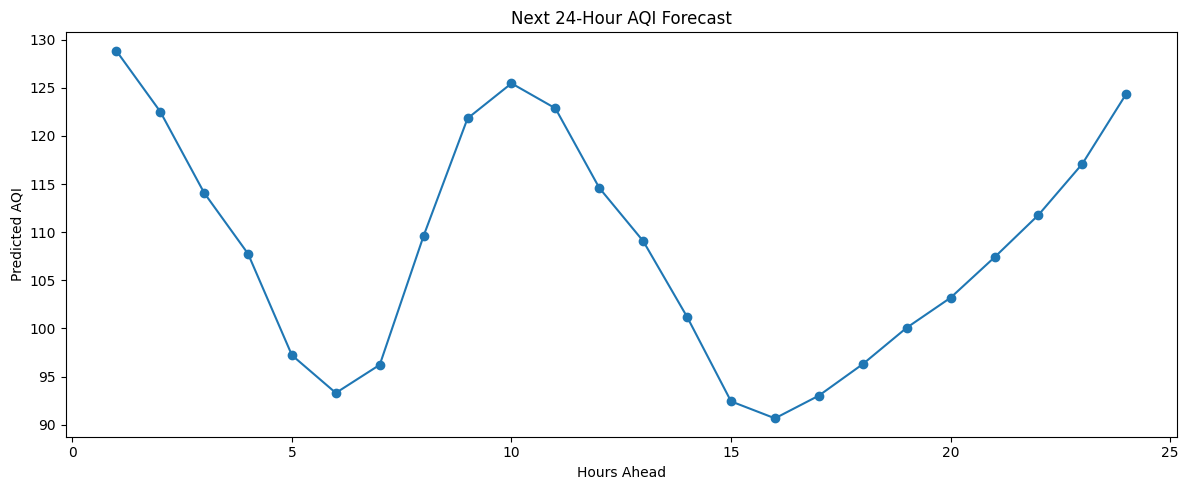

In [50]:
if (
    "aqi_forecast_output" in globals()
    and not aqi_forecast_output.empty
):
    plt.figure(figsize=(12,5))
    plt.plot(
        aqi_forecast_output[
            "horizon_hours"
        ],
        aqi_forecast_output[
            "predicted_aqi"
        ],
        marker="o"
    )
    plt.title("Next 24-Hour AQI Forecast")
    plt.xlabel("Hours Ahead")
    plt.ylabel("Predicted AQI")
    plt.tight_layout()
    plt.savefig(
        VIS_ROOT / "aqi_forecast_24h.png",
        dpi=160
    )
    plt.show()
    plt.close()
else:
    print("AQI forecast artifact unavailable.")


In [51]:
forecast_24h=pd.DataFrame()
if hourly_forecast_model is not None and not hourly_series.empty:
    history=hourly_series[["period_start","pm25"]].dropna().copy()
    recursive=history.copy()
    for _ in range(24):
        next_time=recursive["period_start"].iloc[-1]+pd.Timedelta(hours=1)
        temp=pd.concat([recursive,pd.DataFrame({"period_start":[next_time],"pm25":[np.nan]})],ignore_index=True)
        for lag in [1,2,3,6,12,24,48,72,168]:
            temp[f"pm25_lag_{lag}"]=temp["pm25"].shift(lag)
        for w in [3,6,12,24,72]:
            temp[f"pm25_roll_mean_{w}"]=temp["pm25"].shift(1).rolling(w).mean()
            temp[f"pm25_roll_std_{w}"]=temp["pm25"].shift(1).rolling(w).std()
        temp["hour"]=temp["period_start"].dt.hour
        temp["day_of_week"]=temp["period_start"].dt.dayofweek
        temp["month"]=temp["period_start"].dt.month
        temp["hour_sin"]=np.sin(2*np.pi*temp["hour"]/24)
        temp["hour_cos"]=np.cos(2*np.pi*temp["hour"]/24)
        temp["dow_sin"]=np.sin(2*np.pi*temp["day_of_week"]/7)
        temp["dow_cos"]=np.cos(2*np.pi*temp["day_of_week"]/7)
        x=temp.iloc[[-1]][forecast_features].copy().fillna(method="ffill").fillna(0)
        prediction=float(hourly_forecast_model.predict(x)[0])
        temp.iloc[-1,temp.columns.get_loc("pm25")]=prediction
        recursive=temp[["period_start","pm25"]]
    forecast_24h=recursive.tail(24).copy().rename(columns={"pm25":"predicted_pm25"})
    forecast_24h["horizon_hours"]=range(1,25)
    atomic_to_parquet(forecast_24h,UI_ROOT / "forecast_next_24h.parquet")

display(forecast_24h)


/tmp/ipykernel_549/3018367945.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x=temp.iloc[[-1]][forecast_features].copy().fillna(method="ffill").fillna(0)
/tmp/ipykernel_549/3018367945.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x=temp.iloc[[-1]][forecast_features].copy().fillna(method="ffill").fillna(0)
/tmp/ipykernel_549/3018367945.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x=temp.iloc[[-1]][forecast_features].copy().fillna(method="ffill").fillna(0)
/tmp/ipykernel_549/3018367945.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x=temp.iloc[[-1]][forecast_features].copy().fillna(method="ffill").fi

,period_start,predicted_pm25,horizon_hours
8784,2025-01-01 00:00:00,68.734688,1
8785,2025-01-01 01:00:00,65.459679,2
8786,2025-01-01 02:00:00,64.834839,3
8787,2025-01-01 03:00:00,62.194328,4
8788,2025-01-01 04:00:00,61.679825,5
8789,2025-01-01 05:00:00,60.949306,6
8790,2025-01-01 06:00:00,62.419884,7
8791,2025-01-01 07:00:00,65.138664,8
8792,2025-01-01 08:00:00,65.263206,9
8793,2025-01-01 09:00:00,64.056915,10


# 23 — DWM Warehouse Foundation

The Colab notebook uses a persistent DuckDB warehouse to make the DWM layer reproducible without requiring a live external PostgreSQL server during experimentation.

The generated PostgreSQL DDL is saved for the production application phase.


In [52]:
warehouse_con=duckdb.connect(str(WAREHOUSE_ROOT / "airsense_dw.duckdb"))
for schema in ["dw","marts","ml","metadata"]:
    warehouse_con.execute(f"CREATE SCHEMA IF NOT EXISTS {schema}")
print("Warehouse database:",WAREHOUSE_ROOT / "airsense_dw.duckdb")
warehouse_con.register("parameter_meta", parameter_meta)


Warehouse database: /content/drive/MyDrive/AirSense/warehouse/airsense_dw.duckdb


# 24 — Warehouse Dimensions


In [53]:
warehouse_tables_exist=warehouse_con.execute("SELECT COUNT(*) FROM information_schema.tables WHERE table_schema='dw' AND table_name='fact_air_daily'").fetchone()[0]>0

if not FORCE_REBUILD and warehouse_tables_exist:
    print("Loaded existing warehouse tables from persistent DuckDB.")
else:
    warehouse_con.execute(f"""
    CREATE OR REPLACE TABLE dw.dim_time AS
    SELECT DISTINCT
        CAST(strftime(period_start,'%Y%m%d') AS BIGINT) AS time_key,
        period_start::DATE AS date,
        EXTRACT(YEAR FROM period_start)::INTEGER AS year,
        EXTRACT(QUARTER FROM period_start)::INTEGER AS quarter,
        EXTRACT(MONTH FROM period_start)::INTEGER AS month,
        EXTRACT(WEEK FROM period_start)::INTEGER AS week,
        EXTRACT(DAY FROM period_start)::INTEGER AS day,
        EXTRACT(DAYOFWEEK FROM period_start)::INTEGER AS day_of_week,
        CASE WHEN EXTRACT(DAYOFWEEK FROM period_start) IN (0,6) THEN TRUE ELSE FALSE END AS is_weekend,
        CASE WHEN EXTRACT(MONTH FROM period_start) IN (12,1,2) THEN 'Winter' WHEN EXTRACT(MONTH FROM period_start) IN (3,4,5) THEN 'Summer' WHEN EXTRACT(MONTH FROM period_start) IN (6,7,8,9) THEN 'Monsoon' ELSE 'Post-Monsoon' END AS season
    FROM read_parquet('{str(CLEAN_DAILY_PATH)}',union_by_name=true)
    """)
    warehouse_con.execute(f"""
    CREATE OR REPLACE TABLE dw.dim_station AS
    SELECT ROW_NUMBER() OVER (ORDER BY station_id) AS station_key,station_id AS source_station_id,MAX(station_name) AS station_name,MAX(city_name) AS city_name,MAX(state_name) AS state_name,AVG(latitude) AS latitude,AVG(longitude) AS longitude,MAX(source) AS source
    FROM read_parquet('{str(CLEAN_DAILY_PATH)}',union_by_name=true)
    GROUP BY station_id
    """)
    warehouse_con.execute("CREATE OR REPLACE TABLE dw.dim_state AS SELECT ROW_NUMBER() OVER (ORDER BY state_name) AS state_key,state_name FROM (SELECT DISTINCT state_name FROM dw.dim_station WHERE state_name IS NOT NULL)")
    warehouse_con.execute("CREATE OR REPLACE TABLE dw.dim_city AS SELECT ROW_NUMBER() OVER (ORDER BY state_name,city_name) AS city_key,state_name,city_name FROM (SELECT DISTINCT state_name,city_name FROM dw.dim_station WHERE city_name IS NOT NULL)")
    warehouse_con.execute("CREATE OR REPLACE TABLE dw.dim_location AS SELECT ROW_NUMBER() OVER (ORDER BY state_name,city_name) AS location_key,city_name,state_name,AVG(latitude) AS latitude,AVG(longitude) AS longitude FROM dw.dim_station WHERE city_name IS NOT NULL GROUP BY state_name,city_name")
    warehouse_con.execute("CREATE OR REPLACE TABLE dw.dim_pollutant AS SELECT ROW_NUMBER() OVER (ORDER BY parameter_name) AS pollutant_key,parameter_name,unit,CAST(parameter_code AS VARCHAR) AS parameter_code,pollutant_group FROM parameter_meta WHERE parameter_name IS NOT NULL")
    warehouse_con.execute("CREATE OR REPLACE TABLE dw.dim_source AS SELECT 1 AS source_key,'XKDR India Air Quality Database' AS source_name,'API-derived Parquet analytical history' AS source_description")

display(warehouse_con.sql("SELECT * FROM dw.dim_time LIMIT 10").df())


Loaded existing warehouse tables from persistent DuckDB.


,time_key,date,year,quarter,month,week,day,day_of_week,is_weekend,season
0,20191011,2019-10-11,2019,4,10,41,11,5,False,Post-Monsoon
1,20191013,2019-10-13,2019,4,10,41,13,0,True,Post-Monsoon
2,20191019,2019-10-19,2019,4,10,42,19,6,True,Post-Monsoon
3,20191020,2019-10-20,2019,4,10,42,20,0,True,Post-Monsoon
4,20191028,2019-10-28,2019,4,10,44,28,1,False,Post-Monsoon
5,20191030,2019-10-30,2019,4,10,44,30,3,False,Post-Monsoon
6,20191101,2019-11-01,2019,4,11,44,1,5,False,Post-Monsoon
7,20191110,2019-11-10,2019,4,11,45,10,0,True,Post-Monsoon
8,20191112,2019-11-12,2019,4,11,46,12,2,False,Post-Monsoon
9,20191120,2019-11-20,2019,4,11,47,20,3,False,Post-Monsoon


# 25 — Warehouse Fact Tables


In [54]:
if not FORCE_REBUILD and warehouse_tables_exist:
    print("Existing fact tables reused.")
else:
    warehouse_con.execute(f"""
    CREATE OR REPLACE TABLE dw.fact_air_daily AS
    SELECT ROW_NUMBER() OVER (ORDER BY d.period_start,d.station_id,d.parameter_name) AS fact_daily_key,t.time_key,s.station_key,l.location_key,p.pollutant_key,src.source_key,d.mean_value,d.min_value,d.max_value,d.observation_count
    FROM read_parquet('{str(CLEAN_DAILY_PATH)}',union_by_name=true) d
    JOIN dw.dim_time t ON d.period_start::DATE=t.date
    JOIN dw.dim_station s ON CAST(d.station_id AS VARCHAR)=CAST(s.source_station_id AS VARCHAR)
    LEFT JOIN dw.dim_location l ON d.city_name=l.city_name AND d.state_name=l.state_name
    JOIN dw.dim_pollutant p ON d.parameter_name=p.parameter_name
    CROSS JOIN dw.dim_source src
    """)
    if hourly_standardized_available:
        hcols=hourly_con.sql("DESCRIBE raw_hourly").df()["column_name"].tolist()
        hparam=next((x for x in ["parameter_name","pollutant_name","parameter","pollutant"] if x in hcols),None)
        htime=next((x for x in ["period_start","collected_at","timestamp","datetime"] if x in hcols),None)
        hmean=next((x for x in ["mean","mean_value","avg","average","value"] if x in hcols),None)
        hstation=next((x for x in ["station_id","source_station_id","station"] if x in hcols),None)
        q=lambda x:'"'+x.replace('"','""')+'"'
        warehouse_con.execute(f"""
        CREATE OR REPLACE TABLE dw.fact_air_measurement AS
        SELECT ROW_NUMBER() OVER (ORDER BY period_start,station_id,parameter_name) AS measurement_key,period_start,station_id,parameter_name,mean_value
        FROM (SELECT CAST({q(htime)} AS TIMESTAMP) AS period_start,CAST({q(hstation) if hstation else "NULL"} AS VARCHAR) AS station_id,CASE WHEN CAST({q(hparam)} AS VARCHAR) IN ('Ozone','O3') THEN 'O3' WHEN CAST({q(hparam)} AS VARCHAR) IN ('PM2_5','PM2.5') THEN 'PM2.5' ELSE CAST({q(hparam)} AS VARCHAR) END AS parameter_name,CAST({q(hmean)} AS DOUBLE) AS mean_value FROM read_parquet('{str(FOCUS_HOURLY_DIR)}/*.parquet',union_by_name=true)) q WHERE mean_value IS NOT NULL
        """)
    else:
        warehouse_con.execute("CREATE OR REPLACE TABLE dw.fact_air_measurement AS SELECT CAST(NULL AS BIGINT) AS measurement_key,CAST(NULL AS TIMESTAMP) AS period_start,CAST(NULL AS VARCHAR) AS station_id,CAST(NULL AS VARCHAR) AS parameter_name,CAST(NULL AS DOUBLE) AS mean_value WHERE FALSE")

display(warehouse_con.sql("SELECT COUNT(*) AS fact_rows FROM dw.fact_air_daily").df())


Existing fact tables reused.


,fact_rows
0,8098924


# 26 — Snowflake Schema and SCD Type 2 Readiness


In [55]:
warehouse_con.execute("""
CREATE OR REPLACE VIEW dw.v_snowflake_station_hierarchy AS
SELECT
    s.station_key,
    s.source_station_id,
    s.station_name,
    c.city_key,
    c.city_name,
    st.state_key,
    st.state_name
FROM dw.dim_station s
LEFT JOIN dw.dim_city c ON s.city_name=c.city_name AND s.state_name=c.state_name
LEFT JOIN dw.dim_state st ON s.state_name=st.state_name
""")

warehouse_con.execute("""
CREATE OR REPLACE TABLE dw.dim_station_scd2 AS
SELECT
    station_key AS station_version_key,
    source_station_id,
    station_name,
    city_name,
    state_name,
    latitude,
    longitude,
    source,
    CAST('2009-01-01' AS DATE) AS valid_from,
    CAST(NULL AS DATE) AS valid_to,
    TRUE AS is_current,
    1 AS version_number
FROM dw.dim_station
""")

display(warehouse_con.sql("SELECT * FROM dw.v_snowflake_station_hierarchy LIMIT 20").df())
display(warehouse_con.sql("SELECT * FROM dw.dim_station_scd2 LIMIT 20").df())


,station_key,source_station_id,station_name,city_key,city_name,state_key,state_name
0,1,DS1010001,US Embassy - New Delhi,49,New Delhi,7,Delhi
1,2,DS1010002,US Embassy - Chennai,207,Chennai,24,Tamil Nadu
2,3,DS1010003,US Embassy - Kolkata,247,Kolkata,30,West Bengal
3,4,DS1010004,US Embassy - Mumbai,132,Mumbai,15,Maharashtra
4,5,DS1010005,US Embassy - Hyderabad,217,Hyderabad,26,Telangana
5,6,site_103,"CRRI Mathura Road, Delhi - IMD",48,Delhi,7,Delhi
6,7,site_104,"Burari Crossing, Delhi - IMD",48,Delhi,7,Delhi
7,8,site_105,"North Campus, DU, Delhi - IMD",48,Delhi,7,Delhi
8,9,site_106,"IGI Airport (T3), Delhi - IMD",48,Delhi,7,Delhi
9,10,site_107,"Pusa, Delhi - DPCC",48,Delhi,7,Delhi


,station_version_key,source_station_id,station_name,city_name,state_name,latitude,longitude,source,valid_from,valid_to,is_current,version_number
0,1,DS1010001,US Embassy - New Delhi,New Delhi,Delhi,28.635760,77.224450,us_embassy,2009-01-01,NaT,True,1
1,2,DS1010002,US Embassy - Chennai,Chennai,Tamil Nadu,13.087840,80.278475,us_embassy,2009-01-01,NaT,True,1
2,3,DS1010003,US Embassy - Kolkata,Kolkata,West Bengal,22.562630,88.363040,us_embassy,2009-01-01,NaT,True,1
3,4,DS1010004,US Embassy - Mumbai,Mumbai,Maharashtra,19.072830,72.882610,us_embassy,2009-01-01,NaT,True,1
4,5,DS1010005,US Embassy - Hyderabad,Hyderabad,Telangana,17.384050,78.456360,us_embassy,2009-01-01,NaT,True,1
5,6,site_103,"CRRI Mathura Road, Delhi - IMD",Delhi,Delhi,28.551200,77.273574,cpcb_caaqm,2009-01-01,NaT,True,1
6,7,site_104,"Burari Crossing, Delhi - IMD",Delhi,Delhi,28.725650,77.201157,cpcb_caaqm,2009-01-01,NaT,True,1
7,8,site_105,"North Campus, DU, Delhi - IMD",Delhi,Delhi,28.657381,77.158545,cpcb_caaqm,2009-01-01,NaT,True,1
8,9,site_106,"IGI Airport (T3), Delhi - IMD",Delhi,Delhi,28.562776,77.118005,cpcb_caaqm,2009-01-01,NaT,True,1
9,10,site_107,"Pusa, Delhi - DPCC",Delhi,Delhi,28.639652,77.146275,cpcb_caaqm,2009-01-01,NaT,True,1


# 27 — Data Marts


In [56]:
warehouse_con.execute("""
CREATE OR REPLACE TABLE marts.mart_city_air_quality AS
SELECT
    t.year,
    t.month,
    t.season,
    s.city_name,
    s.state_name,
    p.parameter_name,
    AVG(f.mean_value) AS average_value,
    MIN(f.min_value) AS minimum_value,
    MAX(f.max_value) AS maximum_value,
    SUM(f.observation_count) AS source_observation_count
FROM dw.fact_air_daily f
JOIN dw.dim_time t ON f.time_key=t.time_key
JOIN dw.dim_station s ON f.station_key=s.station_key
JOIN dw.dim_pollutant p ON f.pollutant_key=p.pollutant_key
GROUP BY t.year,t.month,t.season,s.city_name,s.state_name,p.parameter_name
""")

warehouse_con.execute(f"CREATE OR REPLACE TABLE marts.mart_station_profiles AS SELECT * FROM read_parquet('{str(MINING_ROOT / 'station_cluster_results.parquet')}')")
warehouse_con.execute(f"CREATE OR REPLACE TABLE marts.mart_ml_features AS SELECT * FROM read_parquet('{str(FEATURE_ROOT / 'selected_feature_dataset.parquet')}')")
warehouse_con.execute(f"""
CREATE OR REPLACE TABLE marts.mart_citizen_analytics AS
SELECT
    a.city_name,
    a.pollution_date,
    a.aqi_estimate,
    a.aqi_category,
    a.dominant_pollutant,
    l.latitude,
    l.longitude
FROM read_parquet('{str(AQI_PATH)}') a
LEFT JOIN dw.dim_location l ON a.city_name=l.city_name
""")

display(warehouse_con.sql("SELECT * FROM marts.mart_city_air_quality LIMIT 30").df())


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,year,month,season,city_name,state_name,parameter_name,average_value,minimum_value,maximum_value,source_observation_count
0,2009,1,Winter,Delhi,Delhi,NO,33.703044,0.02,491.90,3181.0
1,2009,1,Winter,Delhi,Delhi,NO2,24.831427,0.10,199.50,3230.0
2,2009,1,Winter,Delhi,Delhi,NH3,40.870338,4.44,246.40,611.0
3,2009,1,Winter,Delhi,Delhi,NOx,37.018649,0.00,291.50,2309.0
4,2009,1,Winter,Delhi,Delhi,PM2.5,151.811647,40.25,463.00,562.0
5,2009,1,Winter,Delhi,Delhi,SO2,12.118626,4.00,63.75,1747.0
6,2009,2,Winter,Delhi,Delhi,CO,0.000000,0.00,0.00,4.0
7,2009,3,Summer,Delhi,Delhi,NO,12.298693,0.02,338.75,4275.0
8,2009,3,Summer,Delhi,Delhi,NO2,43.999036,0.03,497.00,4126.0
9,2009,3,Summer,Delhi,Delhi,NH3,44.647550,1.00,184.52,689.0


# 28 — OLAP Roll-Up


In [57]:
olap_rollup=warehouse_con.sql("""
SELECT
    t.year,
    s.state_name,
    s.city_name,
    p.parameter_name,
    AVG(f.mean_value) AS average_value,
    SUM(f.observation_count) AS observations
FROM dw.fact_air_daily f
JOIN dw.dim_time t ON f.time_key=t.time_key
JOIN dw.dim_station s ON f.station_key=s.station_key
JOIN dw.dim_pollutant p ON f.pollutant_key=p.pollutant_key
GROUP BY ROLLUP(t.year,s.state_name,s.city_name,p.parameter_name)
ORDER BY t.year NULLS LAST,s.state_name NULLS LAST,s.city_name NULLS LAST
LIMIT 300
""").df()
atomic_to_csv(olap_rollup,UI_ROOT / "olap_rollup.csv")
display(olap_rollup.head(80))


,year,state_name,city_name,parameter_name,average_value,observations
0,2009,Delhi,Delhi,SO2,11.620520,29681.0
1,2009,Delhi,Delhi,None,34.299601,164208.0
2,2009,Delhi,Delhi,NOx,52.434361,32946.0
3,2009,Delhi,Delhi,CO,21.020242,1440.0
4,2009,Delhi,Delhi,NO,25.561379,38767.0
5,2009,Delhi,Delhi,Benzene,12.666437,3735.0
6,2009,Delhi,Delhi,PM2.5,83.890544,4715.0
7,2009,Delhi,Delhi,MP-Xylene,13.396469,2945.0
8,2009,Delhi,Delhi,Toluene,56.489663,3633.0
9,2009,Delhi,Delhi,NH3,26.761851,6316.0


# 29 — OLAP Drill-Down


In [58]:
olap_drilldown=warehouse_con.sql("""
SELECT
    t.year,
    t.month,
    t.day,
    s.city_name,
    p.parameter_name,
    AVG(f.mean_value) AS average_value
FROM dw.fact_air_daily f
JOIN dw.dim_time t ON f.time_key=t.time_key
JOIN dw.dim_station s ON f.station_key=s.station_key
JOIN dw.dim_pollutant p ON f.pollutant_key=p.pollutant_key
GROUP BY t.year,t.month,t.day,s.city_name,p.parameter_name
ORDER BY t.year,t.month,t.day
LIMIT 300
""").df()
atomic_to_csv(olap_drilldown,UI_ROOT / "olap_drilldown.csv")
display(olap_drilldown.head(80))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,year,month,day,city_name,parameter_name,average_value
0,2009,1,1,Delhi,NO,77.773366
1,2009,1,1,Delhi,PM2.5,215.375000
2,2009,1,1,Delhi,NH3,20.639130
3,2009,1,1,Delhi,SO2,12.666667
4,2009,1,1,Delhi,NOx,24.331803
5,2009,1,1,Delhi,NO2,16.265459
6,2009,1,2,Delhi,NO2,39.861325
7,2009,1,2,Delhi,NOx,71.720833
8,2009,1,2,Delhi,NO,137.226669
9,2009,1,2,Delhi,SO2,15.986111


# 30 — OLAP Slice


In [59]:
olap_slice=warehouse_con.sql("""
SELECT
    t.year,
    t.month,
    s.city_name,
    AVG(f.mean_value) AS average_pm25
FROM dw.fact_air_daily f
JOIN dw.dim_time t ON f.time_key=t.time_key
JOIN dw.dim_station s ON f.station_key=s.station_key
JOIN dw.dim_pollutant p ON f.pollutant_key=p.pollutant_key
WHERE p.parameter_name='PM2.5'
GROUP BY t.year,t.month,s.city_name
ORDER BY t.year,t.month
LIMIT 300
""").df()
atomic_to_csv(olap_slice,UI_ROOT / "olap_slice_pm25.csv")
display(olap_slice.head(80))


,year,month,city_name,average_pm25
0,2009,1,Delhi,151.811647
1,2009,2,Delhi,123.072917
2,2009,3,Delhi,89.842972
3,2009,4,Delhi,67.969285
4,2009,5,Delhi,57.160295
5,2009,6,Delhi,72.010050
6,2009,7,Delhi,54.152897
7,2009,8,Delhi,44.200168
8,2009,9,Delhi,39.986352
9,2009,10,Delhi,129.661207


# 31 — OLAP Dice


In [60]:
dice_cities=top_cities["city_name"].dropna().astype(str).head(5).tolist()
if dice_cities:
    dc=",".join("'"+x.replace("'","''")+"'" for x in dice_cities)
    olap_dice=warehouse_con.sql(f"""
    SELECT t.year,s.city_name,p.parameter_name,AVG(f.mean_value) AS average_value
    FROM dw.fact_air_daily f
    JOIN dw.dim_time t ON f.time_key=t.time_key
    JOIN dw.dim_station s ON f.station_key=s.station_key
    JOIN dw.dim_pollutant p ON f.pollutant_key=p.pollutant_key
    WHERE s.city_name IN ({dc})
      AND p.parameter_name IN ('PM2.5','PM10')
      AND t.year>=2020
    GROUP BY t.year,s.city_name,p.parameter_name
    ORDER BY t.year,s.city_name,p.parameter_name
    """).df()
else:
    olap_dice=pd.DataFrame()
atomic_to_csv(olap_dice,UI_ROOT / "olap_dice.csv")
display(olap_dice)


,year,city_name,parameter_name,average_value
0,2020,Bengaluru,PM10,64.145946
1,2020,Bengaluru,PM2.5,29.450596
2,2020,Delhi,PM10,184.133574
3,2020,Delhi,PM2.5,95.614763
4,2020,Hyderabad,PM10,79.556896
5,2020,Hyderabad,PM2.5,36.419005
6,2020,Kolkata,PM10,97.003576
7,2020,Kolkata,PM2.5,51.688278
8,2020,Mumbai,PM10,97.622394
9,2020,Mumbai,PM2.5,42.454441


# 32 — OLAP Pivot, Cube and Grouping Sets


In [61]:
olap_pivot=olap_slice.pivot_table(index="city_name",columns="year",values="average_pm25",aggfunc="mean").reset_index() if not olap_slice.empty else pd.DataFrame()
atomic_to_csv(olap_pivot,UI_ROOT / "olap_pivot.csv")
display(olap_pivot)


year,city_name,2009,2010,2011,2012,2013,2014,2015,2016
0,Agra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,147.403821
1,Ahmedabad,NaN,NaN,NaN,NaN,NaN,NaN,85.853154,NaN
2,Bengaluru,NaN,NaN,NaN,NaN,NaN,NaN,38.418400,57.366013
3,Chennai,NaN,NaN,NaN,NaN,NaN,NaN,65.357407,59.571426
4,Delhi,72.143745,143.623613,146.458139,195.130905,188.827119,183.655233,123.660369,144.125808
5,Faridabad,NaN,NaN,NaN,NaN,NaN,NaN,122.590085,158.825544
6,Gaya,NaN,NaN,NaN,NaN,NaN,NaN,NaN,78.310980
7,Hyderabad,NaN,NaN,NaN,NaN,NaN,NaN,70.635139,70.267642
8,Jodhpur,NaN,NaN,NaN,NaN,NaN,NaN,115.593862,102.206633
9,Kanpur,NaN,NaN,NaN,NaN,NaN,NaN,107.779932,207.809911


In [62]:
olap_cube=warehouse_con.sql("""
SELECT
    t.year,
    s.city_name,
    p.parameter_name,
    AVG(f.mean_value) AS average_value,
    COUNT(*) AS fact_rows
FROM dw.fact_air_daily f
JOIN dw.dim_time t ON f.time_key=t.time_key
JOIN dw.dim_station s ON f.station_key=s.station_key
JOIN dw.dim_pollutant p ON f.pollutant_key=p.pollutant_key
GROUP BY CUBE(t.year,s.city_name,p.parameter_name)
ORDER BY t.year NULLS LAST,s.city_name NULLS LAST,p.parameter_name NULLS LAST
LIMIT 300
""").df()
atomic_to_csv(olap_cube,UI_ROOT / "olap_cube.csv")
display(olap_cube.head(100))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,year,city_name,parameter_name,average_value,fact_rows
0,2009,Bengaluru,Benzene,2.305410,198
1,2009,Bengaluru,CO,11.687540,220
2,2009,Bengaluru,Eth-Benzene,5.625893,109
3,2009,Bengaluru,MP-Xylene,10.192762,195
4,2009,Bengaluru,NH3,15.590184,249
5,2009,Bengaluru,NO,4.932427,879
6,2009,Bengaluru,NO2,22.966445,879
7,2009,Bengaluru,NOx,29.058811,879
8,2009,Bengaluru,SO2,9.931145,521
9,2009,Bengaluru,Toluene,9.654574,206


In [63]:
olap_grouping=warehouse_con.sql("""
SELECT
    t.year,
    s.state_name,
    p.parameter_name,
    AVG(f.mean_value) AS average_value,
    GROUPING(t.year) AS year_total,
    GROUPING(s.state_name) AS state_total,
    GROUPING(p.parameter_name) AS pollutant_total
FROM dw.fact_air_daily f
JOIN dw.dim_time t ON f.time_key=t.time_key
JOIN dw.dim_station s ON f.station_key=s.station_key
JOIN dw.dim_pollutant p ON f.pollutant_key=p.pollutant_key
GROUP BY GROUPING SETS ((t.year,s.state_name,p.parameter_name),(t.year,s.state_name),(t.year,p.parameter_name),(s.state_name,p.parameter_name),())
ORDER BY t.year NULLS LAST
LIMIT 300
""").df()
atomic_to_csv(olap_grouping,UI_ROOT / "olap_grouping_sets.csv")
display(olap_grouping.head(100))


,year,state_name,parameter_name,average_value,year_total,state_total,pollutant_total
0,2009,Maharashtra,CO,3.326714,0,0,0
1,2009,Karnataka,Eth-Benzene,5.625893,0,0,0
2,2009,TamilNadu,None,10.350210,0,0,1
3,2009,None,NOx,39.822857,0,1,0
4,2009,Maharashtra,None,46.787970,0,0,1
5,2009,None,NO,15.947639,0,1,0
6,2009,Delhi,Eth-Benzene,7.298972,0,0,0
7,2009,Uttar Pradesh,Toluene,10.320000,0,0,0
8,2009,Karnataka,NOx,29.058811,0,0,0
9,2009,Delhi,PM2.5,83.890544,0,0,0


# 33 — Warehouse Visualization


In [64]:
warehouse_city_year=warehouse_con.sql("""
SELECT t.year,s.city_name,p.parameter_name,AVG(f.mean_value) AS average_value
FROM dw.fact_air_daily f
JOIN dw.dim_time t ON f.time_key=t.time_key
JOIN dw.dim_station s ON f.station_key=s.station_key
JOIN dw.dim_pollutant p ON f.pollutant_key=p.pollutant_key
WHERE p.parameter_name='PM2.5' AND s.city_name IS NOT NULL
GROUP BY t.year,s.city_name,p.parameter_name
ORDER BY t.year
""").df()
atomic_to_csv(warehouse_city_year,ARTIFACT_ROOT / "warehouse_city_year_pm25.csv")
display(warehouse_city_year.head(40))


,year,city_name,parameter_name,average_value
0,2009,Delhi,PM2.5,83.890544
1,2010,Delhi,PM2.5,149.502319
2,2011,Delhi,PM2.5,129.508485
3,2012,Delhi,PM2.5,191.450124
4,2013,Delhi,PM2.5,191.531151
5,2013,Navi Mumbai,PM2.5,0.460000
6,2013,Varanasi,PM2.5,246.168544
7,2014,Delhi,PM2.5,179.164090
8,2014,Varanasi,PM2.5,182.224598
9,2014,Navi Mumbai,PM2.5,39.331637


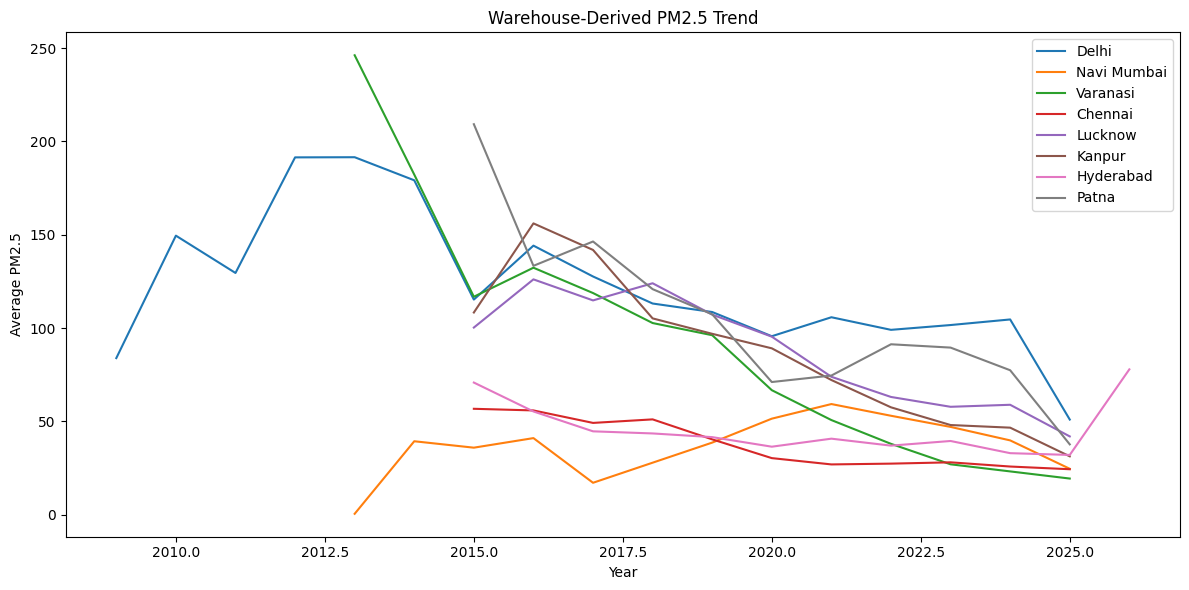

In [65]:
plt.figure(figsize=(12,6))
for city in warehouse_city_year["city_name"].dropna().unique()[:8]:
    d=warehouse_city_year[warehouse_city_year["city_name"]==city]
    plt.plot(d["year"],d["average_value"],label=city)
plt.title("Warehouse-Derived PM2.5 Trend")
plt.xlabel("Year")
plt.ylabel("Average PM2.5")
plt.legend()
plt.tight_layout()
plt.savefig(VIS_ROOT / "warehouse_pm25_trend.png",dpi=160)
plt.show()


# 34 — Warehouse Validation and Metadata


In [66]:
warehouse_tables=[]
for table in ["dim_time","dim_station","dim_state","dim_city","dim_location","dim_pollutant","dim_source","dim_station_scd2","fact_air_daily","fact_air_measurement"]:
    warehouse_tables.append([table,warehouse_con.execute(f"SELECT COUNT(*) FROM dw.{table}").fetchone()[0]])
warehouse_stats=pd.DataFrame(warehouse_tables,columns=["table_name","row_count"])
atomic_to_csv(warehouse_stats,UI_ROOT / "warehouse_table_statistics.csv")
display(warehouse_stats)


,table_name,row_count
0,dim_time,6295
1,dim_station,558
2,dim_state,30
3,dim_city,248
4,dim_location,248
5,dim_pollutant,15
6,dim_source,1
7,dim_station_scd2,558
8,fact_air_daily,8098924
9,fact_air_measurement,633306


In [67]:
relationship_checks=pd.DataFrame([
    ["fact_air_daily -> dim_time",warehouse_con.execute("SELECT COUNT(*) FROM dw.fact_air_daily f LEFT JOIN dw.dim_time d ON f.time_key=d.time_key WHERE d.time_key IS NULL").fetchone()[0]],
    ["fact_air_daily -> dim_station",warehouse_con.execute("SELECT COUNT(*) FROM dw.fact_air_daily f LEFT JOIN dw.dim_station d ON f.station_key=d.station_key WHERE d.station_key IS NULL").fetchone()[0]],
    ["fact_air_daily -> dim_pollutant",warehouse_con.execute("SELECT COUNT(*) FROM dw.fact_air_daily f LEFT JOIN dw.dim_pollutant d ON f.pollutant_key=d.pollutant_key WHERE d.pollutant_key IS NULL").fetchone()[0]]
],columns=["relationship","orphan_rows"])
atomic_to_csv(relationship_checks,UI_ROOT / "warehouse_relationship_validation.csv")
display(relationship_checks)


,relationship,orphan_rows
0,fact_air_daily -> dim_time,0
1,fact_air_daily -> dim_station,0
2,fact_air_daily -> dim_pollutant,0


# 35 — PostgreSQL Handoff

The Colab warehouse is persistent DuckDB for the experimentation phase. This section generates the production PostgreSQL schema so the same dimensional design can be moved into the application backend later.


In [68]:
postgresql_ddl="""
CREATE SCHEMA IF NOT EXISTS dw;
CREATE SCHEMA IF NOT EXISTS marts;
CREATE SCHEMA IF NOT EXISTS ml;
CREATE SCHEMA IF NOT EXISTS metadata;

CREATE TABLE IF NOT EXISTS dw.dim_time (
    time_key BIGINT PRIMARY KEY,
    date DATE,
    year INTEGER,
    quarter INTEGER,
    month INTEGER,
    week INTEGER,
    day INTEGER,
    day_of_week INTEGER,
    is_weekend BOOLEAN,
    season VARCHAR(32)
);

CREATE TABLE IF NOT EXISTS dw.dim_station (
    station_key BIGINT PRIMARY KEY,
    source_station_id VARCHAR(128),
    station_name VARCHAR(255),
    city_name VARCHAR(255),
    state_name VARCHAR(255),
    latitude DOUBLE PRECISION,
    longitude DOUBLE PRECISION,
    source VARCHAR(255)
);

CREATE TABLE IF NOT EXISTS dw.dim_location (
    location_key BIGINT PRIMARY KEY,
    city_name VARCHAR(255),
    state_name VARCHAR(255),
    latitude DOUBLE PRECISION,
    longitude DOUBLE PRECISION
);

CREATE TABLE IF NOT EXISTS dw.dim_pollutant (
    pollutant_key BIGINT PRIMARY KEY,
    parameter_name VARCHAR(128),
    unit VARCHAR(64),
    parameter_code VARCHAR(128),
    pollutant_group VARCHAR(128)
);

CREATE TABLE IF NOT EXISTS dw.dim_source (
    source_key BIGINT PRIMARY KEY,
    source_name VARCHAR(255),
    source_description TEXT
);

CREATE TABLE IF NOT EXISTS dw.fact_air_daily (
    fact_daily_key BIGINT PRIMARY KEY,
    time_key BIGINT REFERENCES dw.dim_time(time_key),
    station_key BIGINT REFERENCES dw.dim_station(station_key),
    location_key BIGINT REFERENCES dw.dim_location(location_key),
    pollutant_key BIGINT REFERENCES dw.dim_pollutant(pollutant_key),
    source_key BIGINT REFERENCES dw.dim_source(source_key),
    mean_value DOUBLE PRECISION,
    min_value DOUBLE PRECISION,
    max_value DOUBLE PRECISION,
    observation_count DOUBLE PRECISION
);

CREATE TABLE IF NOT EXISTS dw.dim_station_scd2 (
    station_version_key BIGINT PRIMARY KEY,
    source_station_id VARCHAR(128),
    station_name VARCHAR(255),
    city_name VARCHAR(255),
    state_name VARCHAR(255),
    latitude DOUBLE PRECISION,
    longitude DOUBLE PRECISION,
    source VARCHAR(255),
    valid_from DATE,
    valid_to DATE,
    is_current BOOLEAN,
    version_number INTEGER
);
"""

(WAREHOUSE_ROOT / "postgresql_ddl.sql").write_text(postgresql_ddl,encoding="utf-8")
print("Saved:",WAREHOUSE_ROOT / "postgresql_ddl.sql")


Saved: /content/drive/MyDrive/AirSense/warehouse/postgresql_ddl.sql


# 36 — Citizen Analytics and Map Artifacts


In [69]:
latest_city=(
    aqi_wide[aqi_wide["aqi_valid"]]
    .sort_values(["city_name","pollution_date"])
    .groupby("city_name")
    .tail(1)
    .copy()
)

latest_city=latest_city.merge(
    station_meta[["city_name","latitude","longitude"]].dropna(subset=["city_name"]).drop_duplicates("city_name"),
    on="city_name",
    how="left"
)

latest_city_export=latest_city[["city_name","pollution_date","aqi_estimate","aqi_category","dominant_pollutant","latitude","longitude"]]
atomic_to_csv(latest_city_export,UI_ROOT / "latest_city_air_quality.csv")
atomic_to_csv(latest_city_export.dropna(subset=["latitude","longitude"]),UI_ROOT / "pollution_map_data.csv")
display(latest_city_export.head(20))


,city_name,pollution_date,aqi_estimate,aqi_category,dominant_pollutant,latitude,longitude
0,Agra,2025-09-01,44.173146,Good,PM10,27.237110,78.019360
1,Ahmedabad,2025-09-01,53.999219,Satisfactory,PM10,23.107969,72.574648
2,Bengaluru,2025-09-01,49.297332,Good,PM10,12.913522,77.595080
3,Chennai,2025-09-01,85.131892,Satisfactory,PM10,13.066400,80.211200
4,Delhi,2025-09-01,36.545381,Good,PM10,28.815329,77.153010
5,Faridabad,2025-04-02,132.628793,Moderate,PM2.5,28.390720,77.300590
6,Gurugram,2024-12-31,187.501848,Moderate,PM2.5,28.422681,77.148944
7,Hyderabad,2026-03-27,88.806034,Satisfactory,PM2.5,17.540891,78.358528
8,Jaipur,2025-09-01,30.154785,Good,PM10,26.902909,75.836858
9,Kolkata,2025-09-01,61.451190,Satisfactory,PM10,22.536751,88.363802


# 37 — Citizen Historical Baseline


In [70]:
baseline=(
    aqi_wide[aqi_wide["aqi_valid"]]
    .assign(month=lambda d:pd.to_datetime(d["pollution_date"]).dt.month)
    .groupby(["city_name","month"])
    .agg(baseline_aqi_mean=("aqi_estimate","mean"),baseline_aqi_median=("aqi_estimate","median"),baseline_aqi_std=("aqi_estimate","std"),observations=("aqi_estimate","count"))
    .reset_index()
)
atomic_to_csv(baseline,UI_ROOT / "citizen_monthly_baseline.csv")
display(baseline.head(30))


,city_name,month,baseline_aqi_mean,baseline_aqi_median,baseline_aqi_std,observations
0,Agra,1,265.236156,307.398129,138.540444,279
1,Agra,2,184.462175,172.109310,108.295194,254
2,Agra,3,139.750753,129.756466,83.277696,276
3,Agra,4,129.784993,114.873262,72.683101,298
4,Agra,5,110.385241,91.032507,66.671216,304
5,Agra,6,93.328834,80.479037,60.016802,300
6,Agra,7,62.328556,53.989000,36.196096,309
7,Agra,8,60.279866,56.206190,30.746540,309
8,Agra,9,66.525116,54.797068,40.160232,264
9,Agra,10,162.865414,114.927565,115.154860,276


# 38 — Citizen Activity Analytics


In [71]:
activities={"Walking":1.0,"Running":1.3,"Cycling":1.25,"Outdoor Sports":1.4,"Commute":0.85}
activity_rows=[]
for activity,factor in activities.items():
    temp=aqi_city_summary.copy()
    temp["activity"]=activity
    temp["exposure_factor"]=factor
    temp["activity_exposure_index"]=temp["average_aqi"]*factor
    activity_rows.append(temp)
activity_profiles=pd.concat(activity_rows,ignore_index=True)
atomic_to_csv(activity_profiles,UI_ROOT / "activity_profiles.csv")
display(activity_profiles.head(20))


,city_name,average_aqi,median_aqi,maximum_aqi,observations,activity,exposure_factor,activity_exposure_index
0,Delhi,269.027863,290.154410,500.0,5998,Walking,1.0,269.027863
1,Gurugram,203.862229,178.368943,500.0,2915,Walking,1.0,203.862229
2,Patna,194.140226,151.914780,500.0,3505,Walking,1.0,194.140226
3,Lucknow,183.968015,156.832710,500.0,5913,Walking,1.0,183.968015
4,Faridabad,174.746112,136.449211,500.0,4997,Walking,1.0,174.746112
5,Moradabad,165.693618,122.908578,500.0,2669,Walking,1.0,165.693618
6,Varanasi,150.904101,96.692497,500.0,4737,Walking,1.0,150.904101
7,Agra,145.400830,98.961566,500.0,3417,Walking,1.0,145.400830
8,Bengaluru,141.805305,99.600158,500.0,5938,Walking,1.0,141.805305
9,Jaipur,124.385610,113.169745,500.0,2880,Walking,1.0,124.385610


# 39 — Frontend Page Contract


In [72]:
frontend_pages=pd.DataFrame([
    ["/","Home","Plain-language AQI explanation, pollutant glossary, project purpose and source"],
    ["/dashboard","Personal Air Intelligence","Location, time, activity, current analytics, baseline and forecast"],
    ["/map","Pollution Map","Station/city markers, pollution levels, clusters and anomalies"],
    ["/analytics","Historical Analytics","Trends, seasonal analysis, city comparison and distributions"],
    ["/warehouse","Data Warehouse","Facts, dimensions, grain, keys, star and snowflake structures"],
    ["/olap","OLAP Explorer","Roll-up, drill-down, slice, dice, pivot, cube and grouping sets"],
    ["/datamining","Data Mining","PCA, clustering, anomaly detection and association analysis"],
    ["/features","Feature Lab","Feature engineering, selection, RFE, feature importance and PCA"],
    ["/models","ML Model Lab","Regression, classification, forecasting and model comparison"],
    ["/explain","Explain My AQI","Feature importance, baseline deviation and model evidence"],
    ["/pipeline","ETL and Data Quality","Source inventory, cleaning, quality reports and warehouse validation"],
    ["/concepts","DWM + ML Concepts","Definitions and live project artifacts"],
    ["/about","About","Team, methodology, source attribution, limitations and privacy"]
],columns=["route","page","purpose"])
atomic_to_csv(frontend_pages,UI_ROOT / "frontend_page_contract.csv")
display(frontend_pages)


,route,page,purpose
0,/,Home,"Plain-language AQI explanation, pollutant glos..."
1,/dashboard,Personal Air Intelligence,"Location, time, activity, current analytics, b..."
2,/map,Pollution Map,"Station/city markers, pollution levels, cluste..."
3,/analytics,Historical Analytics,"Trends, seasonal analysis, city comparison and..."
4,/warehouse,Data Warehouse,"Facts, dimensions, grain, keys, star and snowf..."
5,/olap,OLAP Explorer,"Roll-up, drill-down, slice, dice, pivot, cube ..."
6,/datamining,Data Mining,"PCA, clustering, anomaly detection and associa..."
7,/features,Feature Lab,"Feature engineering, selection, RFE, feature i..."
8,/models,ML Model Lab,"Regression, classification, forecasting and mo..."
9,/explain,Explain My AQI,"Feature importance, baseline deviation and mod..."


# 40 — Backend API Contract


In [73]:
backend_endpoints=pd.DataFrame([
    ["GET","/api/air/latest","Latest available station/city analytics"],
    ["GET","/api/air/history","Historical warehouse analytics"],
    ["GET","/api/air/forecast","Forecast artifact"],
    ["GET","/api/air/map","Pollution map data"],
    ["GET","/api/air/anomalies","Anomaly results"],
    ["GET","/api/air/clusters","Cluster results"],
    ["GET","/api/air/baseline","Historical baseline"],
    ["POST","/api/predict/aqi","AQI regression inference"],
    ["POST","/api/predict/category","AQI category inference"],
    ["GET","/api/warehouse/schema","Warehouse metadata"],
    ["GET","/api/warehouse/olap","Parameterized OLAP result"],
    ["GET","/api/features","Feature and PCA results"],
    ["GET","/api/models","Model metrics and selected models"],
    ["GET","/api/pipeline","ETL and quality statistics"],
    ["GET","/api/location/nearest-station","Nearest station lookup"]
],columns=["method","endpoint","purpose"])
atomic_to_csv(backend_endpoints,UI_ROOT / "backend_endpoint_contract.csv")
display(backend_endpoints)


,method,endpoint,purpose
0,GET,/api/air/latest,Latest available station/city analytics
1,GET,/api/air/history,Historical warehouse analytics
2,GET,/api/air/forecast,Forecast artifact
3,GET,/api/air/map,Pollution map data
4,GET,/api/air/anomalies,Anomaly results
5,GET,/api/air/clusters,Cluster results
6,GET,/api/air/baseline,Historical baseline
7,POST,/api/predict/aqi,AQI regression inference
8,POST,/api/predict/category,AQI category inference
9,GET,/api/warehouse/schema,Warehouse metadata


# 41 — DWM and ML Concept Registries


In [74]:
dwm_registry=pd.DataFrame([
    ["Data Source","XKDR API-derived Parquet history"],
    ["Preprocessing","Validation, duplicate resolution and invalid-value handling"],
    ["ETL","Source extraction, transformation and warehouse loading design"],
    ["Fact","fact_air_daily"],
    ["Fact","fact_air_measurement focus layer"],
    ["Dimension","dim_time"],
    ["Dimension","dim_station"],
    ["Dimension","dim_location"],
    ["Dimension","dim_pollutant"],
    ["Dimension","dim_source"],
    ["Star Schema","Fact with shared dimensions"],
    ["Snowflake Schema","Station → City → State"],
    ["SCD Type 2","dim_station_scd2"],
    ["Data Mart","mart_city_air_quality"],
    ["Data Mart","mart_station_profiles"],
    ["Data Mart","mart_ml_features"],
    ["OLAP","Roll-up"],
    ["OLAP","Drill-down"],
    ["OLAP","Slice"],
    ["OLAP","Dice"],
    ["OLAP","Pivot"],
    ["OLAP","CUBE and GROUPING SETS"]
],columns=["concept","implementation"])
atomic_to_csv(dwm_registry,UI_ROOT / "dwm_concepts.csv")

a_ml=pd.DataFrame([
    ["Feature Engineering","Temporal, lag, rolling and baseline features"],
    ["Feature Selection","Correlation, mutual information, SelectKBest, RFE and tree importance"],
    ["Feature Extraction","PCA"],
    ["Clustering","K-Means, hierarchical clustering and DBSCAN"],
    ["Anomaly Detection","IQR and Isolation Forest"],
    ["Association Analysis","Support, confidence and lift"],
    ["Regression","Linear Regression, Random Forest, Gradient Boosting and XGBoost"],
    ["Classification","Logistic Regression, Random Forest and XGBoost"],
    ["Forecasting","Hourly PM2.5 next-step model when focus data are available"],
    ["Validation","Chronological train/test split"],
    ["Model Comparison","Regression and classification metrics"],
    ["Explainability","Feature importance"]
],columns=["concept","implementation"])
atomic_to_csv(a_ml,UI_ROOT / "ml_concepts.csv")

display(dwm_registry)
display(a_ml)


,concept,implementation
0,Data Source,XKDR API-derived Parquet history
1,Preprocessing,"Validation, duplicate resolution and invalid-v..."
2,ETL,"Source extraction, transformation and warehous..."
3,Fact,fact_air_daily
4,Fact,fact_air_measurement focus layer
5,Dimension,dim_time
6,Dimension,dim_station
7,Dimension,dim_location
8,Dimension,dim_pollutant
9,Dimension,dim_source


,concept,implementation
0,Feature Engineering,"Temporal, lag, rolling and baseline features"
1,Feature Selection,"Correlation, mutual information, SelectKBest, ..."
2,Feature Extraction,PCA
3,Clustering,"K-Means, hierarchical clustering and DBSCAN"
4,Anomaly Detection,IQR and Isolation Forest
5,Association Analysis,"Support, confidence and lift"
6,Regression,"Linear Regression, Random Forest, Gradient Boo..."
7,Classification,"Logistic Regression, Random Forest and XGBoost"
8,Forecasting,Hourly PM2.5 next-step model when focus data a...
9,Validation,Chronological train/test split


# 42 — Final Project Manifest


In [75]:
manifest={
    "project":"AirSense",
    "source":"XKDR India Air Quality Database",
    "persistent_root":str(PROJECT_ROOT),
    "history_files":len(history_files),
    "hourly_files":len(hourly_files),
    "clean_daily_rows":int(clean_count),
    "aqi_rows":int(len(aqi_wide)),
    "selected_regression_model":str(selected_regression_name),
    "selected_classification_model":str(selected_classification_name),
    "cluster_count":int(best_k),
    "warehouse_database":str(WAREHOUSE_ROOT / "airsense_dw.duckdb"),
    "postgresql_ddl":str(WAREHOUSE_ROOT / "postgresql_ddl.sql")
}
save_json(manifest,REPORT_ROOT / "project_manifest.json")
print(json.dumps(manifest,indent=2))


{
  "project": "AirSense",
  "source": "XKDR India Air Quality Database",
  "persistent_root": "/content/drive/MyDrive/AirSense",
  "history_files": 207,
  "hourly_files": 13,
  "clean_daily_rows": 8835377,
  "aqi_rows": 64767,
  "selected_regression_model": "XGBoost",
  "selected_classification_model": "XGBoost",
  "cluster_count": 2,
  "warehouse_database": "/content/drive/MyDrive/AirSense/warehouse/airsense_dw.duckdb",
  "postgresql_ddl": "/content/drive/MyDrive/AirSense/warehouse/postgresql_ddl.sql"
}


# 43 — Final Validation


In [76]:
required_artifacts=[
    DATA_ROOT / "clean_air_daily.parquet",
    TOP_DATA_ROOT / "city_daily_aqi.parquet",
    FEATURE_ROOT / "feature_dataset.parquet",
    FEATURE_ROOT / "selected_feature_dataset.parquet",
    FEATURE_ROOT / "pca_components.parquet",
    MINING_ROOT / "station_cluster_results.parquet",
    MINING_ROOT / "anomalies.parquet",
    MODEL_ROOT / "aqi_regression_models.joblib",
    MODEL_ROOT / "aqi_classification_models.joblib",
    MODEL_ROOT / "pca_bundle.joblib",
    WAREHOUSE_ROOT / "airsense_dw.duckdb",
    WAREHOUSE_ROOT / "postgresql_ddl.sql",
    UI_ROOT / "frontend_page_contract.csv",
    UI_ROOT / "backend_endpoint_contract.csv",
    UI_ROOT / "dwm_concepts.csv",
    UI_ROOT / "ml_concepts.csv"
]

validation=pd.DataFrame([[str(p),artifact_exists(p) or p.is_dir()] for p in required_artifacts],columns=["artifact","exists"])
atomic_to_csv(validation,REPORT_ROOT / "final_artifact_validation.csv")
display(validation)

model_load_checks=[]
for p in [MODEL_ROOT / "aqi_regression_models.joblib",MODEL_ROOT / "aqi_classification_models.joblib",MODEL_ROOT / "pca_bundle.joblib",MODEL_ROOT / "station_clustering_bundle.joblib"]:
    try:
        joblib.load(p)
        model_load_checks.append([p.name,True])
    except Exception:
        model_load_checks.append([p.name,False])
model_load_checks=pd.DataFrame(model_load_checks,columns=["model","load_ok"])
display(model_load_checks)

final_validation={
    "all_core_artifacts_present":bool(validation["exists"].all()),
    "all_saved_models_load":bool(model_load_checks["load_ok"].all()),
    "warehouse_orphan_rows":int(relationship_checks["orphan_rows"].sum())
}
save_json(final_validation,REPORT_ROOT / "final_validation.json")
display(pd.DataFrame([final_validation]))
save_state("final_validation",details=final_validation)


,artifact,exists
0,/content/drive/MyDrive/AirSense/data/clean_air...,True
1,/content/drive/MyDrive/AirSense/data/city_dail...,True
2,/content/drive/MyDrive/AirSense/features/featu...,True
3,/content/drive/MyDrive/AirSense/features/selec...,True
4,/content/drive/MyDrive/AirSense/features/pca_c...,True
5,/content/drive/MyDrive/AirSense/mining/station...,True
6,/content/drive/MyDrive/AirSense/mining/anomali...,True
7,/content/drive/MyDrive/AirSense/models/aqi_reg...,True
8,/content/drive/MyDrive/AirSense/models/aqi_cla...,True
9,/content/drive/MyDrive/AirSense/models/pca_bun...,True


,model,load_ok
0,aqi_regression_models.joblib,True
1,aqi_classification_models.joblib,True
2,pca_bundle.joblib,True
3,station_clustering_bundle.joblib,True


,all_core_artifacts_present,all_saved_models_load,warehouse_orphan_rows
0,True,True,0


/tmp/ipykernel_549/4141818168.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "updated_at": datetime.utcnow().isoformat(),


# 44 — Runtime Recovery Summary

If this notebook is executed again after a Colab runtime disconnect, the Drive-resident data and model checkpoints are reused. The notebook can be run with `Run all` from the top without intentionally downloading the existing history again.


In [77]:
summary_rows=[]
for key,value in PROJECT_STATE.items():
    summary_rows.append([key,value.get("status"),value.get("updated_at")])
summary_df=pd.DataFrame(summary_rows,columns=["stage","status","updated_at"])
display(summary_df)
print("Project state:",STATE_FILE)
print("History files on Drive:",len(list(HISTORY_DIR.glob("air_*.parquet"))))
print("Models on Drive:",len(list(MODEL_ROOT.glob("*"))))
print("Artifacts on Drive:",len(list(ARTIFACT_ROOT.glob("*"))))


,stage,status,updated_at
0,startup,complete,2026-10-04T07:54:27.656720
1,profiling,complete,2026-10-04T07:54:42.317176
2,quality,complete,2026-10-04T07:55:00.760403
3,preprocessing,complete,2026-10-04T07:57:15.157330
4,aqi,complete,2026-10-04T07:57:35.862606
5,clustering,complete,2026-10-04T08:06:38.735620
6,regression,complete,2026-10-04T08:06:49.089991
7,classification,complete,2026-10-04T08:06:57.393747
8,final_validation,complete,2026-10-04T08:12:00.166957
9,feature_selection,complete,2026-10-04T08:04:50.700366


Project state: /content/drive/MyDrive/AirSense/state/project_state.json
History files on Drive: 207
Models on Drive: 11
Artifacts on Drive: 9


# AirSense Master Notebook Complete

The Colab phase now produces the persistent analytical layer required for the later application phase:

XKDR data → preprocessing → AQI → feature engineering → feature selection → PCA → clustering → anomaly detection → ML → forecasting → model comparison → warehouse → OLAP → citizen/UI artifacts.

The next production stage is:

Google Drive artifacts → PostgreSQL warehouse → FastAPI → React frontend.


# 45 — Requirements Completion Layer

The base notebook has already established the persistent Drive, DuckDB, profiling, preprocessing, AQI, clustering, anomaly, regression, classification, forecasting, warehouse, OLAP and application-contract foundations.

This layer adds the remaining high-value requirements while preserving checkpointed execution.


# 46 — Enhanced Feature Engineering


In [78]:
feature_frame = feature_frame.copy()
feature_frame["pollution_date"] = pd.to_datetime(feature_frame["pollution_date"])

if "hour" not in feature_frame.columns:
    feature_frame["hour"] = feature_frame["pollution_date"].dt.hour

if "quarter" not in feature_frame.columns:
    feature_frame["quarter"] = feature_frame["pollution_date"].dt.quarter

feature_frame["rush_hour"] = (
    feature_frame["hour"].isin([7,8,9,17,18,19,20]).astype(int)
)

feature_frame["time_of_day"] = np.select(
    [
        feature_frame["hour"].between(0,5),
        feature_frame["hour"].between(6,11),
        feature_frame["hour"].between(12,16),
        feature_frame["hour"].between(17,21)
    ],
    [
        "Night",
        "Morning",
        "Afternoon",
        "Evening"
    ],
    default="Night"
)

for pollutant in ["PM2.5","PM10","NO2","SO2","CO","O3"]:
    if pollutant in feature_frame.columns:
        safe = pollutant.replace(".","_")
        feature_frame[f"{safe}_rate_of_change"] = (
            feature_frame
            .groupby("city_name")[pollutant]
            .pct_change()
            .replace([np.inf,-np.inf],np.nan)
        )

threshold_cols = [
    c for c in ["PM2.5","PM10","NO2","SO2","CO","O3"]
    if c in feature_frame.columns
]

if threshold_cols:
    threshold_values = feature_frame[threshold_cols].median()
    feature_frame["pollutant_count_above_threshold"] = (
        feature_frame[threshold_cols]
        .gt(threshold_values)
        .sum(axis=1)
    )
else:
    feature_frame["pollutant_count_above_threshold"] = 0

for pollutant in ["PM2.5","PM10","NO2"]:
    if pollutant in feature_frame.columns:
        safe = pollutant.replace(".","_")
        historical_mean = (
            feature_frame
            .groupby("city_name")[pollutant]
            .transform("mean")
        )
        historical_std = (
            feature_frame
            .groupby("city_name")[pollutant]
            .transform("std")
        )
        feature_frame[f"{safe}_historical_mean"] = historical_mean
        feature_frame[f"{safe}_historical_std"] = historical_std
        feature_frame[f"{safe}_deviation_from_baseline"] = (
            feature_frame[pollutant] - historical_mean
        )
        feature_frame[f"{safe}_zscore_from_baseline"] = (
            (feature_frame[pollutant] - historical_mean)
            / historical_std.replace(0,np.nan)
        )

atomic_to_parquet(
    feature_frame,
    FEATURE_ROOT / "feature_dataset_enhanced.parquet"
)

feature_dictionary_enhanced = pd.DataFrame({
    "feature": feature_frame.columns,
    "dtype": [str(feature_frame[c].dtype) for c in feature_frame.columns],
    "missing_count": [int(feature_frame[c].isna().sum()) for c in feature_frame.columns],
    "unique_count": [int(feature_frame[c].nunique(dropna=True)) for c in feature_frame.columns]
})

atomic_to_csv(
    feature_dictionary_enhanced,
    FEATURE_ROOT / "feature_dictionary_enhanced.csv"
)

display(feature_dictionary_enhanced)
save_state(
    "enhanced_features",
    details={"feature_count":len(feature_frame.columns)}
)


/tmp/ipykernel_549/2868823851.py:36: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change()
/tmp/ipykernel_549/2868823851.py:36: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change()
/tmp/ipykernel_549/2868823851.py:36: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change()
/tmp/ipykernel_549/2868823851.py:36: FutureWarning: The default fill_method='ffill' i

,feature,dtype,missing_count,unique_count
0,city_name,object,0,15
1,pollution_date,datetime64[us],0,6292
2,CO,float64,5808,49346
3,NH3,float64,22824,41666
4,NO2,float64,3640,60424
5,O3,float64,4931,58766
6,PM10,float64,24804,39870
7,PM2.5,float64,11757,51645
8,SO2,float64,4066,59406
9,Pb,float64,64767,0


/tmp/ipykernel_549/4141818168.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "updated_at": datetime.utcnow().isoformat(),


# 47 — Feature Selection and Extraction Showcase


In [79]:
selection_methods = pd.DataFrame([
    ["Correlation Filtering", artifact_exists(FEATURE_ROOT / "correlation_ranking.csv")],
    ["Mutual Information", artifact_exists(FEATURE_ROOT / "mutual_information_scores.csv")],
    ["SelectKBest", artifact_exists(FEATURE_ROOT / "mutual_information_scores.csv")],
    ["Recursive Feature Elimination", artifact_exists(FEATURE_ROOT / "rfe_ranking.csv")],
    ["Tree-based Feature Importance", artifact_exists(FEATURE_ROOT / "tree_importance.csv") or artifact_exists(FEATURE_ROOT / "tree_feature_importance.csv")],
    ["PCA", artifact_exists(FEATURE_ROOT / "pca_components.parquet")]
], columns=["method","artifact_available"])

display(selection_methods)

atomic_to_csv(
    selection_methods,
    FEATURE_ROOT / "feature_selection_methods.csv"
)


,method,artifact_available
0,Correlation Filtering,True
1,Mutual Information,False
2,SelectKBest,False
3,Recursive Feature Elimination,False
4,Tree-based Feature Importance,False
5,PCA,True


# 48 — PCA Loading and Projection Analysis


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
PM2.5,0.255788,0.023602,-0.201596,0.056088,0.476469,-0.114607,0.126181,-0.408538
PM2.5_subindex,0.262827,-0.002202,-0.172225,0.033273,0.405642,-0.102952,0.250784,-0.326708
aqi_lag_1,0.268354,0.138376,-0.026710,-0.002525,0.020757,0.552276,0.110175,0.239976
aqi_rolling_mean_3,0.276418,0.150004,-0.041959,-0.030897,-0.198558,0.222878,0.287149,0.062868
PM10,0.234776,-0.250016,0.307106,0.055934,0.247754,-0.132197,0.150053,0.319731
aqi_rolling_mean_7,0.273360,0.151606,-0.050567,-0.059207,-0.241785,-0.087701,0.218277,0.129488
PM10_subindex,0.234463,-0.233985,0.302417,0.057230,0.281354,-0.155575,0.135330,0.427307
PM2_5_rolling_mean_7,0.268242,0.051337,-0.240159,-0.031304,-0.113799,-0.292769,-0.279083,0.144892
PM2_5_lag_1,0.261949,0.037494,-0.224932,0.025872,0.168275,0.395563,-0.388910,0.027889
PM2_5_rolling_mean_3,0.270393,0.049028,-0.237307,-0.002095,-0.048687,0.052384,-0.242706,-0.009288


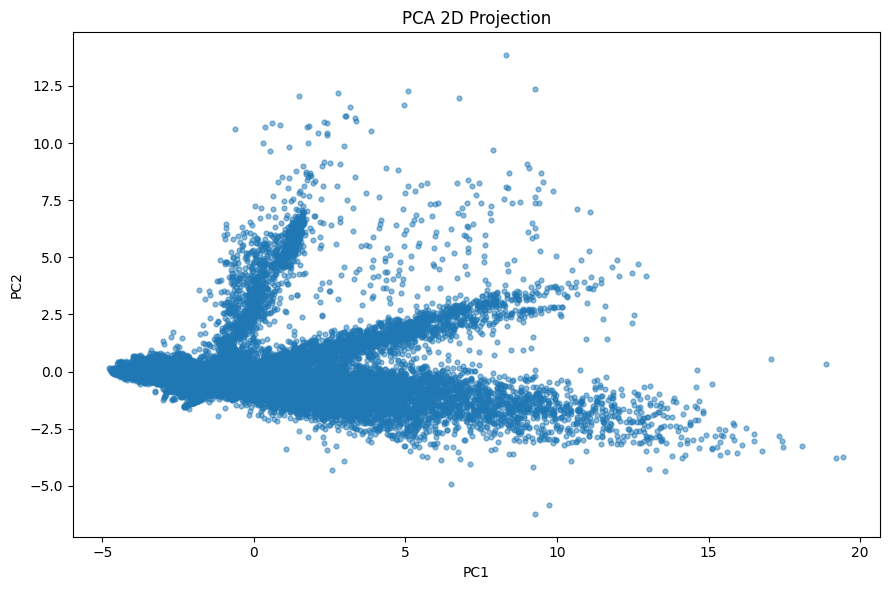

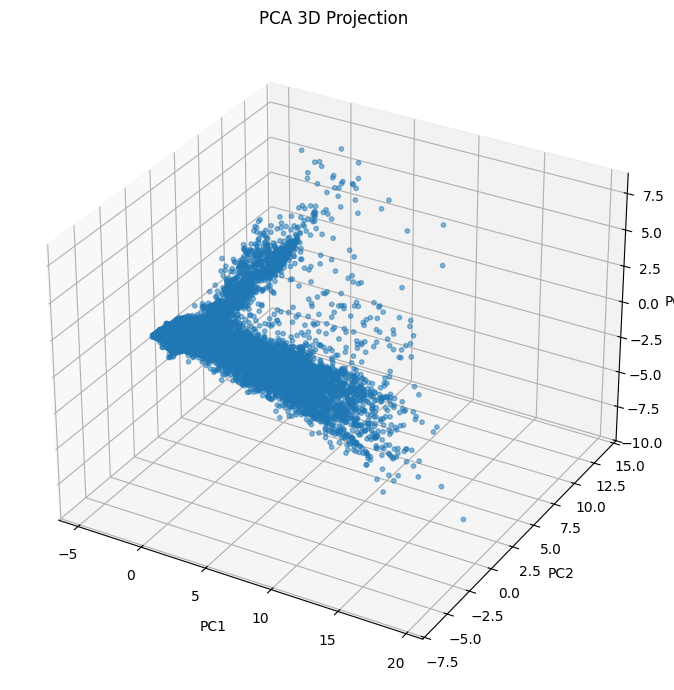

In [80]:
if "selected_features" in globals():
    pca_loadings = pd.DataFrame(
        pca.components_.T,
        index=selected_features,
        columns=[
            f"PC{i+1}"
            for i in range(pca.components_.shape[0])
        ]
    )

    atomic_to_csv(
        pca_loadings.reset_index().rename(columns={"index":"feature"}),
        FEATURE_ROOT / "pca_loadings.csv"
    )

    display(pca_loadings)

    if "pca_matrix_scaled" not in globals():
        pca_rebuild_imputer = SimpleImputer(strategy="median")
        pca_rebuild = pca_rebuild_imputer.fit_transform(
            ml_frame[selected_features]
        )
        pca_matrix_scaled = StandardScaler().fit_transform(
            pca_rebuild
        )

    pca_projection_2d = PCA(
        n_components=2
    ).fit_transform(
        pca_matrix_scaled
    )

    pca_projection_3d = PCA(
        n_components=3
    ).fit_transform(
        pca_matrix_scaled
    )

    pca_2d_df = pd.DataFrame(
        pca_projection_2d,
        columns=["PC1","PC2"]
    )

    pca_3d_df = pd.DataFrame(
        pca_projection_3d,
        columns=["PC1","PC2","PC3"]
    )

    atomic_to_parquet(
        pca_2d_df,
        FEATURE_ROOT / "pca_2d_projection.parquet"
    )

    atomic_to_parquet(
        pca_3d_df,
        FEATURE_ROOT / "pca_3d_projection.parquet"
    )

    plt.figure(figsize=(9,6))
    plt.scatter(
        pca_2d_df["PC1"],
        pca_2d_df["PC2"],
        s=12,
        alpha=0.5
    )
    plt.title("PCA 2D Projection")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.savefig(
        VIS_ROOT / "pca_2d_projection.png",
        dpi=160
    )
    plt.show()
    plt.close()

    fig = plt.figure(figsize=(9,7))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(
        pca_3d_df["PC1"],
        pca_3d_df["PC2"],
        pca_3d_df["PC3"],
        s=10,
        alpha=0.5
    )
    ax.set_title("PCA 3D Projection")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    plt.tight_layout()
    plt.savefig(
        VIS_ROOT / "pca_3d_projection.png",
        dpi=160
    )
    plt.show()
    plt.close()


# 49 — Enhanced Station Pollution Profiles


In [81]:
enhanced_station_profiles = con.sql("""
SELECT
    station_id,
    MAX(station_name) AS station_name,
    MAX(city_name) AS city_name,
    MAX(state_name) AS state_name,
    MAX(latitude) AS latitude,
    MAX(longitude) AS longitude,
    AVG(mean_value) FILTER (WHERE parameter_name='PM2.5') AS avg_pm25,
    AVG(mean_value) FILTER (WHERE parameter_name='PM10') AS avg_pm10,
    AVG(mean_value) FILTER (WHERE parameter_name='NO2') AS avg_no2,
    AVG(mean_value) FILTER (WHERE parameter_name='SO2') AS avg_so2,
    AVG(mean_value) FILTER (WHERE parameter_name='CO') AS avg_co,
    AVG(mean_value) FILTER (WHERE parameter_name='O3') AS avg_o3,
    STDDEV_SAMP(mean_value) FILTER (WHERE parameter_name='PM2.5') AS pollution_variability,
    MAX(mean_value) FILTER (WHERE parameter_name='PM2.5') AS peak_pm25,
    SUM(
        CASE
            WHEN parameter_name='PM2.5' AND mean_value>60
            THEN 1 ELSE 0
        END
    ) AS peak_frequency
FROM clean_air_daily
GROUP BY station_id
HAVING COUNT(*)>10
""").df()

enhanced_cluster_features = [
    c for c in [
        "avg_pm25",
        "avg_pm10",
        "avg_no2",
        "avg_so2",
        "avg_co",
        "avg_o3",
        "pollution_variability",
        "peak_pm25",
        "peak_frequency"
    ]
    if c in enhanced_station_profiles.columns
]

atomic_to_parquet(
    enhanced_station_profiles,
    MINING_ROOT / "enhanced_station_profiles.parquet"
)

display(enhanced_station_profiles.head(25))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,station_id,station_name,city_name,state_name,latitude,longitude,avg_pm25,avg_pm10,avg_no2,avg_so2,avg_co,avg_o3,pollution_variability,peak_pm25,peak_frequency
0,site_1551,Tamaka Ind. Area Kolar,None,None,NaN,NaN,46.994411,67.680652,11.980138,23.048082,0.642340,16.831691,118.845807,985.000000,70.0
1,site_1554,"Hebbal, Bengaluru - KSPCB",Bengaluru,Karnataka,13.029152,77.585901,27.840703,61.186505,19.172340,8.043750,0.526964,23.282592,21.190549,556.000000,127.0
2,site_1557,"Chikkaballapur Rural, Chikkaballapur - KSPCB",Chikkaballapur,Karnataka,13.428828,77.731418,29.217420,63.447522,19.564250,10.957780,0.531543,26.100796,18.402940,141.479167,149.0
3,site_1560,"Bawana, Delhi - DPCC",Delhi,Delhi,28.776200,77.051074,119.293714,237.135024,24.983334,9.109997,1.176387,33.106699,91.405660,709.000000,1687.0
4,site_1561,"Mundka, Delhi - DPCC",Delhi,Delhi,28.684678,77.076574,118.966252,267.176932,40.064500,16.568280,1.226534,34.719096,99.325548,711.437500,1589.0
5,site_1562,"Sri Aurobindo Marg, Delhi - DPCC",Delhi,Delhi,28.531346,77.190156,84.260543,153.593269,29.089717,9.099557,1.115288,38.218624,72.030476,555.352273,1219.0
6,site_1563,"Pusa, Delhi - DPCC",Delhi,Delhi,28.639652,77.146275,92.260960,206.728789,54.368202,11.647841,1.353815,22.879547,79.274019,588.195652,1303.0
7,site_1565,Lal Bahadur Shastri Nagar Kalaburagi,None,None,NaN,NaN,41.023533,80.728317,17.977843,15.715558,0.538868,28.050359,58.348919,985.000000,311.0
8,site_1569,New Collectorate Baghpat,None,None,NaN,NaN,104.753476,208.808025,27.320828,12.997596,1.164609,41.706018,87.103475,772.180556,722.0
9,site_157,"IGSC Planetarium Complex, Patna - BSPCB",Patna,Bihar,25.610369,85.132568,104.590477,NaN,45.246757,16.138329,1.315335,37.226353,82.589803,644.000000,1916.0


# 50 — Cluster Evaluation


In [82]:
cluster_input = (
    enhanced_station_profiles[
        enhanced_cluster_features
    ]
    .replace([np.inf,-np.inf],np.nan)
)

cluster_imputer_enhanced = SimpleImputer(
    strategy="median"
)

cluster_array = cluster_imputer_enhanced.fit_transform(
    cluster_input
)

cluster_scaler_enhanced = StandardScaler()

cluster_scaled_enhanced = (
    cluster_scaler_enhanced.fit_transform(
        cluster_array
    )
)

cluster_evaluation = []

for k in range(2,7):
    model_k = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    labels_k = model_k.fit_predict(
        cluster_scaled_enhanced
    )

    cluster_evaluation.append([
        k,
        model_k.inertia_,
        silhouette_score(
            cluster_scaled_enhanced,
            labels_k
        ),
        davies_bouldin_score(
            cluster_scaled_enhanced,
            labels_k
        )
    ])

cluster_evaluation = pd.DataFrame(
    cluster_evaluation,
    columns=[
        "k",
        "inertia",
        "silhouette",
        "davies_bouldin"
    ]
)

display(cluster_evaluation)

atomic_to_csv(
    cluster_evaluation,
    MINING_ROOT / "cluster_evaluation.csv"
)

best_k_enhanced = int(
    cluster_evaluation.sort_values(
        ["silhouette","davies_bouldin"],
        ascending=[False,True]
    ).iloc[0]["k"]
)

kmeans_enhanced = KMeans(
    n_clusters=best_k_enhanced,
    random_state=RANDOM_STATE,
    n_init=10
)

enhanced_station_profiles[
    "kmeans_cluster"
] = kmeans_enhanced.fit_predict(
    cluster_scaled_enhanced
)

hierarchical_enhanced = AgglomerativeClustering(
    n_clusters=best_k_enhanced
)

enhanced_station_profiles[
    "hierarchical_cluster"
] = hierarchical_enhanced.fit_predict(
    cluster_scaled_enhanced
)

dbscan_enhanced = DBSCAN(
    eps=1.2,
    min_samples=5
)

enhanced_station_profiles[
    "dbscan_cluster"
] = dbscan_enhanced.fit_predict(
    cluster_scaled_enhanced
)

cluster_profiles = (
    enhanced_station_profiles
    .groupby("kmeans_cluster")[
        enhanced_cluster_features
    ]
    .mean()
    .reset_index()
)

def describe_cluster(row):
    ranked = (
        row[enhanced_cluster_features]
        .sort_values(ascending=False)
    )
    strongest = ranked.index[0]
    weakest = ranked.index[-1]
    return (
        "Higher relative "
        + strongest.replace("_"," ")
        + " and lower relative "
        + weakest.replace("_"," ")
        + " among selected features."
    )

cluster_profiles[
    "profile_description"
] = cluster_profiles.apply(
    describe_cluster,
    axis=1
)

display(cluster_profiles)

atomic_to_parquet(
    enhanced_station_profiles,
    MINING_ROOT / "station_cluster_results_enhanced.parquet"
)

atomic_to_csv(
    cluster_profiles,
    MINING_ROOT / "cluster_profiles_enhanced.csv"
)

joblib.dump(
    {
        "model": kmeans_enhanced,
        "imputer": cluster_imputer_enhanced,
        "scaler": cluster_scaler_enhanced,
        "features": enhanced_cluster_features,
        "k": best_k_enhanced
    },
    MODEL_ROOT / "station_cluster_enhanced.joblib"
)

save_state(
    "enhanced_clustering",
    details={
        "k":best_k_enhanced,
        "stations":len(enhanced_station_profiles)
    }
)


,k,inertia,silhouette,davies_bouldin
0,2,3275.376495,0.415037,1.085065
1,3,2850.416723,0.216025,1.626996
2,4,2504.570177,0.212241,1.372979
3,5,2256.515403,0.223306,1.400301
4,6,2019.363203,0.198136,1.278673


,kmeans_cluster,avg_pm25,avg_pm10,avg_no2,avg_so2,avg_co,avg_o3,pollution_variability,peak_pm25,peak_frequency,profile_description
0,0,87.234197,176.755145,34.861764,14.190270,1.632509,32.017940,70.592098,656.156931,1227.769231,Higher relative peak frequency and lower relat...
1,1,40.360666,88.453061,20.308196,12.132267,0.813538,29.935745,28.408838,268.242402,244.698598,Higher relative peak pm25 and lower relative a...


/tmp/ipykernel_549/4141818168.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "updated_at": datetime.utcnow().isoformat(),


# 51 — Required Classification Models


In [83]:
classification_required_path = (
    MODEL_ROOT / "classification_required.joblib"
)

classification_required_metrics_path = (
    MODEL_ROOT / "classification_required_metrics.csv"
)

if (
    not FORCE_REBUILD
    and artifact_exists(classification_required_path)
    and artifact_exists(classification_required_metrics_path)
):
    required_bundle = joblib.load(
        classification_required_path
    )

    required_models = required_bundle["models"]
    required_encoder = required_bundle["encoder"]
    required_imputer = required_bundle["imputer"]
    required_scaler = required_bundle["scaler"]
    required_selected = required_bundle["selected_model"]

    required_metrics = pd.read_csv(
        classification_required_metrics_path
    )

    print("Required classification checkpoint loaded.")
else:
    classification_work = classification_data.copy()
    classification_work = classification_work.replace(
        [np.inf,-np.inf],
        np.nan
    )

    if len(classification_work)>MAX_CLASSIFICATION_ROWS:
        classification_work = classification_work.iloc[
            -MAX_CLASSIFICATION_ROWS:
        ].copy()

    X_req = classification_work[
        candidate_features
    ]

    y_req_raw = classification_work[
        "target_category"
    ]

    required_encoder = LabelEncoder()
    y_req = required_encoder.fit_transform(
        y_req_raw
    )

    req_cut = max(
        int(len(classification_work)*0.8),
        1
    )

    X_req_train = X_req.iloc[:req_cut]
    X_req_test = X_req.iloc[req_cut:]
    y_req_train = y_req[:req_cut]
    y_req_test = y_req[req_cut:]

    required_imputer = SimpleImputer(
        strategy="median"
    )

    X_req_train_imp = pd.DataFrame(
        required_imputer.fit_transform(
            X_req_train
        ),
        columns=candidate_features
    )

    X_req_test_imp = pd.DataFrame(
        required_imputer.transform(
            X_req_test
        ),
        columns=candidate_features
    )

    required_scaler = StandardScaler()

    X_req_train_scaled = required_scaler.fit_transform(
        X_req_train_imp
    )

    X_req_test_scaled = required_scaler.transform(
        X_req_test_imp
    )

    required_models = {
        "Logistic Regression": LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ),
        "Decision Tree": DecisionTreeClassifier(
            max_depth=12,
            random_state=RANDOM_STATE,
            class_weight="balanced"
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=100,
            max_depth=14,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
            class_weight="balanced_subsample"
        ),
        "XGBoost": XGBClassifier(
            n_estimators=120,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS
        ),
        "SVM": SVC(
            kernel="rbf",
            C=2,
            gamma="scale"
        )
    }

    required_rows = []

    for name, model in required_models.items():
        started = time.time()

        if name=="Logistic Regression":
            model.fit(
                X_req_train_scaled,
                y_req_train
            )
            prediction_req = model.predict(
                X_req_test_scaled
            )
        else:
            model.fit(
                X_req_train_imp,
                y_req_train
            )
            prediction_req = model.predict(
                X_req_test_imp
            )

        required_rows.append({
            "model":name,
            "accuracy":accuracy_score(
                y_req_test,
                prediction_req
            ),
            "precision_macro":precision_score(
                y_req_test,
                prediction_req,
                average="macro",
                zero_division=0
            ),
            "recall_macro":recall_score(
                y_req_test,
                prediction_req,
                average="macro",
                zero_division=0
            ),
            "f1_macro":f1_score(
                y_req_test,
                prediction_req,
                average="macro",
                zero_division=0
            ),
            "elapsed_seconds":time.time()-started
        })

    required_metrics = pd.DataFrame(
        required_rows
    ).sort_values(
        ["f1_macro","accuracy"],
        ascending=False
    )

    required_selected = (
        required_metrics.iloc[0]["model"]
    )

    joblib.dump(
        {
            "models":required_models,
            "encoder":required_encoder,
            "imputer":required_imputer,
            "scaler":required_scaler,
            "selected_model":required_selected
        },
        classification_required_path
    )

    atomic_to_csv(
        required_metrics,
        classification_required_metrics_path
    )

display(required_metrics)
print("Selected required classifier:", required_selected)

save_state(
    "classification_required",
    details={
        "selected_model":str(required_selected)
    }
)


,model,accuracy,precision_macro,recall_macro,f1_macro,elapsed_seconds
3,XGBoost,0.6825,0.538005,0.525543,0.527991,5.073819
0,Logistic Regression,0.6355,0.484476,0.525037,0.498062,3.412007
2,Random Forest,0.5970,0.507132,0.474586,0.473711,6.780656
1,Decision Tree,0.5485,0.440990,0.454242,0.444318,1.022487
4,SVM,0.4795,0.341683,0.379355,0.339666,5.811105


Selected required classifier: XGBoost


/tmp/ipykernel_549/4141818168.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "updated_at": datetime.utcnow().isoformat(),


# 52 — Required Classification Confusion Matrix


In [84]:
required_model = required_models[
    required_selected
]

if required_selected=="Logistic Regression":
    required_prediction = required_model.predict(
        X_req_test_scaled
    )
else:
    required_prediction = required_model.predict(
        X_req_test_imp
    )

required_cm = confusion_matrix(
    y_req_test,
    required_prediction,
    labels=list(
        range(
            len(required_encoder.classes_)
        )
    )
)

required_cm_df = pd.DataFrame(
    required_cm,
    index=required_encoder.classes_,
    columns=required_encoder.classes_
)

display(required_cm_df)

atomic_to_csv(
    required_cm_df.reset_index().rename(
        columns={"index":"actual"}
    ),
    UI_ROOT / "classification_confusion_matrix_full.csv"
)


,Good,Moderate,Poor,Satisfactory,Severe,Very Poor
Good,428,3,0,209,0,0
Moderate,2,275,26,102,0,9
Poor,0,37,41,2,0,32
Satisfactory,71,104,1,541,0,2
Severe,0,0,0,0,0,1
Very Poor,0,11,22,0,1,80


# 53 — Station-Level AQI Dataset


In [85]:
station_aqi_long = con.sql("""
SELECT
    station_id,
    MAX(station_name) AS station_name,
    MAX(city_name) AS city_name,
    MAX(state_name) AS state_name,
    MAX(latitude) AS latitude,
    MAX(longitude) AS longitude,
    period_start::DATE AS pollution_date,
    parameter_name,
    AVG(mean_value) AS concentration
FROM clean_air_daily
WHERE parameter_name IN (
    'PM10',
    'PM2.5',
    'NO2',
    'SO2',
    'CO',
    'O3',
    'NH3',
    'Pb'
)
GROUP BY
    station_id,
    period_start::DATE,
    parameter_name
""").df()

station_aqi = (
    station_aqi_long
    .pivot_table(
        index=[
            "station_id",
            "station_name",
            "city_name",
            "state_name",
            "latitude",
            "longitude",
            "pollution_date"
        ],
        columns="parameter_name",
        values="concentration",
        aggfunc="mean"
    )
    .reset_index()
)

for pollutant in AQI_POLLUTANTS:
    if pollutant not in station_aqi.columns:
        station_aqi[pollutant] = np.nan

for pollutant in AQI_POLLUTANTS:
    station_aqi[
        f"{pollutant}_subindex"
    ] = station_aqi[pollutant].apply(
        lambda value, p=pollutant:
        subindex(value,p)
    )

station_subindices = [
    f"{p}_subindex"
    for p in AQI_POLLUTANTS
]

station_aqi["aqi_estimate"] = station_aqi[
    station_subindices
].max(axis=1)

station_aqi["dominant_pollutant"] = (
    station_aqi[
        station_subindices
    ]
    .idxmax(axis=1)
    .str.replace(
        "_subindex",
        "",
        regex=False
    )
)

station_aqi["aqi_category"] = (
    station_aqi["aqi_estimate"]
    .apply(aqi_category)
)

atomic_to_parquet(
    station_aqi,
    TOP_DATA_ROOT / "station_daily_aqi.parquet"
)

con.register(
    "station_aqi_df",
    station_aqi
)

display(
    station_aqi[
        [
            "station_id",
            "city_name",
            "pollution_date",
            "aqi_estimate",
            "aqi_category",
            "dominant_pollutant"
        ]
    ].head(25)
)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/tmp/ipykernel_549/4278978269.py:73: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  .idxmax(axis=1)


parameter_name,station_id,city_name,pollution_date,aqi_estimate,aqi_category,dominant_pollutant
0,DS1010001,New Delhi,2019-07-01,98.068966,Satisfactory,PM2.5
1,DS1010001,New Delhi,2019-07-02,115.081897,Moderate,PM2.5
2,DS1010001,New Delhi,2019-07-03,48.819444,Good,PM2.5
3,DS1010001,New Delhi,2019-07-04,64.728448,Satisfactory,PM2.5
4,DS1010001,New Delhi,2019-07-05,59.659483,Satisfactory,PM2.5
5,DS1010001,New Delhi,2019-07-06,49.652778,Good,PM2.5
6,DS1010001,New Delhi,2019-07-07,70.079023,Satisfactory,PM2.5
7,DS1010001,New Delhi,2019-07-08,81.061782,Satisfactory,PM2.5
8,DS1010001,New Delhi,2019-07-09,71.768678,Satisfactory,PM2.5
9,DS1010001,New Delhi,2019-07-10,175.392241,Moderate,PM2.5


# 54 — Citizen Historical Baseline and Normality


In [86]:
normality = station_aqi[
    station_aqi["aqi_estimate"].notna()
].copy()

normality["month"] = (
    pd.to_datetime(
        normality["pollution_date"]
    ).dt.month
)

normality["historical_mean"] = (
    normality
    .groupby(
        [
            "station_id",
            "month"
        ]
    )["aqi_estimate"]
    .transform("mean")
)

normality["historical_std"] = (
    normality
    .groupby(
        [
            "station_id",
            "month"
        ]
    )["aqi_estimate"]
    .transform("std")
)

normality["deviation"] = (
    normality["aqi_estimate"]
    - normality["historical_mean"]
)

normality["deviation_pct"] = (
    100.0
    * normality["deviation"]
    / normality["historical_mean"].replace(
        0,
        np.nan
    )
)

normality["status"] = np.select(
    [
        normality["historical_std"].isna(),
        normality["deviation"].abs()
        <= normality["historical_std"]
    ],
    [
        "Insufficient history",
        "Within normal range"
    ],
    default="Unusual"
)

atomic_to_parquet(
    normality,
    UI_ROOT / "is_this_normal.parquet"
)

display(
    normality[
        [
            "station_id",
            "city_name",
            "pollution_date",
            "aqi_estimate",
            "historical_mean",
            "deviation_pct",
            "status"
        ]
    ].head(30)
)


parameter_name,station_id,city_name,pollution_date,aqi_estimate,historical_mean,deviation_pct,status
0,DS1010001,New Delhi,2019-07-01,98.068966,53.341797,83.850136,Unusual
1,DS1010001,New Delhi,2019-07-02,115.081897,53.341797,115.744320,Unusual
2,DS1010001,New Delhi,2019-07-03,48.819444,53.341797,-8.478065,Within normal range
3,DS1010001,New Delhi,2019-07-04,64.728448,53.341797,21.346584,Within normal range
4,DS1010001,New Delhi,2019-07-05,59.659483,53.341797,11.843782,Within normal range
5,DS1010001,New Delhi,2019-07-06,49.652778,53.341797,-6.915813,Within normal range
6,DS1010001,New Delhi,2019-07-07,70.079023,53.341797,31.377320,Within normal range
7,DS1010001,New Delhi,2019-07-08,81.061782,53.341797,51.966725,Unusual
8,DS1010001,New Delhi,2019-07-09,71.768678,53.341797,34.544921,Within normal range
9,DS1010001,New Delhi,2019-07-10,175.392241,53.341797,228.808275,Unusual


# 55 — Citizen Explanation Data


In [87]:
why_air = station_aqi[
    station_aqi["aqi_estimate"].notna()
].copy()

for pollutant in AQI_POLLUTANTS:
    why_air[
        f"{pollutant}_contribution_proxy"
    ] = (
        why_air[
            f"{pollutant}_subindex"
        ]
        / why_air[
            "aqi_estimate"
        ].replace(
            0,
            np.nan
        )
    )

why_air["historical_city_mean"] = (
    why_air
    .groupby("city_name")["aqi_estimate"]
    .transform("mean")
)

why_air["deviation_from_city_mean"] = (
    why_air["aqi_estimate"]
    - why_air["historical_city_mean"]
)

why_air["dominant_contribution_proxy"] = (
    why_air[
        [
            f"{p}_contribution_proxy"
            for p in AQI_POLLUTANTS
        ]
    ].max(axis=1)
)

atomic_to_parquet(
    why_air,
    UI_ROOT / "why_is_my_air_bad.parquet"
)

display(
    why_air[
        [
            "station_id",
            "city_name",
            "pollution_date",
            "aqi_estimate",
            "dominant_pollutant",
            "historical_city_mean",
            "deviation_from_city_mean"
        ]
    ].head(30)
)


parameter_name,station_id,city_name,pollution_date,aqi_estimate,dominant_pollutant,historical_city_mean,deviation_from_city_mean
0,DS1010001,New Delhi,2019-07-01,98.068966,PM2.5,185.428617,-87.359651
1,DS1010001,New Delhi,2019-07-02,115.081897,PM2.5,185.428617,-70.346720
2,DS1010001,New Delhi,2019-07-03,48.819444,PM2.5,185.428617,-136.609172
3,DS1010001,New Delhi,2019-07-04,64.728448,PM2.5,185.428617,-120.700168
4,DS1010001,New Delhi,2019-07-05,59.659483,PM2.5,185.428617,-125.769134
5,DS1010001,New Delhi,2019-07-06,49.652778,PM2.5,185.428617,-135.775839
6,DS1010001,New Delhi,2019-07-07,70.079023,PM2.5,185.428617,-115.349594
7,DS1010001,New Delhi,2019-07-08,81.061782,PM2.5,185.428617,-104.366835
8,DS1010001,New Delhi,2019-07-09,71.768678,PM2.5,185.428617,-113.659939
9,DS1010001,New Delhi,2019-07-10,175.392241,PM2.5,185.428617,-10.036375


# 56 — Better Time and Better Area


In [88]:
if hourly_standardized_available:
    better_time = hourly_con.sql("""
    SELECT
        EXTRACT(HOUR FROM period_start)::INTEGER AS hour,
        AVG(mean_value) FILTER (
            WHERE parameter_name='PM2.5'
        ) AS average_pm25
    FROM focus_hourly_standardized
    GROUP BY hour
    ORDER BY average_pm25
    """).df()
else:
    better_time = (
        station_aqi
        .assign(
            hour=12
        )
        .groupby("hour")["aqi_estimate"]
        .agg(
            average_aqi="mean",
            observations="count"
        )
        .reset_index()
        .sort_values("average_aqi")
    )

better_time["rank"] = range(
    1,
    len(better_time)+1
)

atomic_to_csv(
    better_time,
    UI_ROOT / "find_better_time.csv"
)

latest_station = (
    station_aqi[
        station_aqi["aqi_estimate"].notna()
    ]
    .sort_values("pollution_date")
    .groupby("station_id")
    .tail(1)
)

station_baseline = (
    station_aqi[
        station_aqi["aqi_estimate"].notna()
    ]
    .groupby(
        [
            "station_id",
            "city_name",
            "state_name"
        ]
    )["aqi_estimate"]
    .agg(
        historical_mean_aqi="mean",
        historical_max_aqi="max",
        historical_days="count"
    )
    .reset_index()
)

better_area = latest_station.merge(
    station_baseline,
    on=[
        "station_id",
        "city_name",
        "state_name"
    ],
    how="left"
)

better_area["area_score"] = (
    0.5 * better_area["aqi_estimate"].fillna(0)
    +
    0.5 * better_area[
        "historical_mean_aqi"
    ].fillna(
        better_area["aqi_estimate"]
    )
)

better_area = better_area.sort_values(
    "area_score"
)

atomic_to_parquet(
    better_area,
    UI_ROOT / "find_better_area.parquet"
)

display(
    better_area[
        [
            "station_id",
            "station_name",
            "city_name",
            "aqi_estimate",
            "historical_mean_aqi",
            "area_score"
        ]
    ].head(30)
)


,station_id,station_name,city_name,aqi_estimate,historical_mean_aqi,area_score
304,site_5375,"PWD Junction, Kohima - NPCB",Kohima,16.182917,42.061967,29.122442
306,site_6012,"Dhankawadi, Pune - IITM",Pune,25.349583,38.672209,32.010896
336,site_5614,"Uchapatti, Madurai - TNPCB",Madurai,25.793750,41.916341,33.855046
134,site_5391,"Stuart Hill, Madikeri - KSPCB",Madikeri,27.697917,40.685511,34.191714
395,site_5628,"Civil Lines, Bareilly - UPPCB",Bareilly,2.572083,69.375776,35.973930
265,site_5536,"Civic Center, Bhilai - Bhilai Steel Plant",Bhilai,22.739167,51.517113,37.128140
375,site_5660,"32Bungalows, Bhilai - CECB",Bhilai,16.079583,59.630850,37.855216
399,site_5654,"Krishak Nagar, Raipur - CECB",Raipur,19.106250,58.913665,39.009958
388,site_5652,"AIIMS, Raipur - CECB",Raipur,13.105000,67.263046,40.184023
438,site_5855,"Regional Park, Indore - IMC",Indore,20.509524,61.222682,40.866103


# 57 — Pollution Map Artifact


In [89]:
map_data = latest_station[
    [
        "station_id",
        "station_name",
        "city_name",
        "state_name",
        "latitude",
        "longitude",
        "aqi_estimate",
        "aqi_category",
        "dominant_pollutant"
    ]
].copy()

map_clusters = enhanced_station_profiles[
    [
        "station_id",
        "kmeans_cluster",
        "hierarchical_cluster",
        "dbscan_cluster"
    ]
].copy()

map_data = map_data.merge(
    map_clusters,
    on="station_id",
    how="left"
)

atomic_to_csv(
    map_data,
    UI_ROOT / "pollution_map_data.csv"
)

geo_points = map_data.dropna(
    subset=[
        "latitude",
        "longitude"
    ]
)

if len(geo_points):
    pollution_map = folium.Map(
        location=[
            float(geo_points["latitude"].mean()),
            float(geo_points["longitude"].mean())
        ],
        zoom_start=5
    )

    category_colors = {
        "Good":"green",
        "Satisfactory":"lightgreen",
        "Moderate":"yellow",
        "Poor":"orange",
        "Very Poor":"red",
        "Severe":"darkred",
        "Unknown":"gray"
    }

    for _, row in geo_points.iterrows():
        color = category_colors.get(
            row["aqi_category"],
            "gray"
        )

        folium.CircleMarker(
            location=[
                row["latitude"],
                row["longitude"]
            ],
            radius=6,
            color=color,
            fill=True,
            fill_color=color,
            popup=(
                f"Station: {row['station_name']}<br>"
                f"City: {row['city_name']}<br>"
                f"AQI: {row['aqi_estimate']:.1f}<br>"
                f"Category: {row['aqi_category']}<br>"
                f"Dominant: {row['dominant_pollutant']}"
            )
        ).add_to(
            pollution_map
        )

    pollution_map.save(
        UI_ROOT / "station_pollution_map.html"
    )

display(map_data.head(30))


,station_id,station_name,city_name,state_name,latitude,longitude,aqi_estimate,aqi_category,dominant_pollutant,kmeans_cluster,hierarchical_cluster,dbscan_cluster
0,site_305,"Pimpleshwar Mandir, Kalyan - MPCB",Kalyan,Maharashtra,19.192056,72.958519,500.000000,Severe,CO,0,0,-1
1,site_258,"Toll Gate, Tirumala - APPCB",Tirumala,Andhra Pradesh,13.670000,79.350000,143.316810,Moderate,PM2.5,1,1,-1
2,site_274,"Ghusuri, Howrah - WBPCB",Howrah,West Bengal,22.611968,88.347422,150.199899,Moderate,PM10,1,1,0
3,site_261,"Nerul, Navi Mumbai - MPCB",Navi Mumbai,Maharashtra,19.008751,73.016620,74.519975,Satisfactory,CO,1,1,-1
4,site_168,Bandra Mumbai,Mumbai,Maharashtra,19.053536,72.846430,103.192617,Moderate,PM10,1,1,0
5,site_164,"BWSSB Kadabesanahalli, Bengaluru - CPCB",Bengaluru,Karnataka,12.935205,77.681449,37.600595,Good,SO2,1,0,-1
6,site_263,"Sector 11, Faridabad - HSPCB",Faridabad,Haryana,28.376058,77.315741,301.575581,Very Poor,PM2.5,0,0,-1
7,site_5051,"F-Block, Sirsa - HSPCB",Sirsa,Haryana,29.536400,75.015800,134.587205,Moderate,O3,1,1,0
8,site_5056,"Police Lines, Jind - HSPCB",Jind,Haryana,29.307814,76.337619,341.962209,Very Poor,PM2.5,0,0,0
9,site_5072,"Rishi Nagar, Kaithal - HSPCB",Kaithal,Haryana,29.800600,76.415500,309.155775,Very Poor,PM2.5,1,1,0


# 58 — Final Data Warehouse Model

The final warehouse uses a fact constellation with a detailed measurement fact and a daily analytical fact, sharing conformed dimensions.

The detailed fact preserves station × pollutant × timestamp observations when the persistent hourly focus layer is available.

The daily fact is the primary BI and OLAP table.


# 59 — Final Warehouse Schema and Dimensions


In [93]:
warehouse_con = duckdb.connect()

warehouse_con.execute(
    "CREATE SCHEMA IF NOT EXISTS dw_final"
)

warehouse_con.execute(
    "CREATE SCHEMA IF NOT EXISTS marts_final"
)

clean_path_sql = str(CLEAN_DAILY_PATH).replace("'", "''")

warehouse_con.execute(
    f"""
    CREATE OR REPLACE VIEW clean_air_daily AS
    SELECT *
    FROM read_parquet(
        '{clean_path_sql}',
        union_by_name=true
    )
    """
)

print(
    "Warehouse source rows:",
    warehouse_con.execute(
        "SELECT COUNT(*) FROM clean_air_daily"
    ).fetchone()[0]
)

Warehouse source rows: 8835377


In [95]:
warehouse_con.execute(
    "CREATE SCHEMA IF NOT EXISTS dw_final"
)

warehouse_con.execute(
    "CREATE SCHEMA IF NOT EXISTS marts_final"
)

clean_path_sql = str(CLEAN_DAILY_PATH).replace("'", "''")

warehouse_con.execute(
    f"""
    CREATE OR REPLACE VIEW clean_air_daily AS
    SELECT *
    FROM read_parquet(
        '{clean_path_sql}',
        union_by_name=true
    )
    """
)

warehouse_con.execute(
    "DROP TABLE IF EXISTS dw_final.fact_air_measurement"
)

warehouse_con.execute(
    "DROP TABLE IF EXISTS dw_final.fact_air_daily"
)

warehouse_con.execute(
    "DROP TABLE IF EXISTS dw_final.dim_station_scd2"
)

warehouse_con.execute(
    "DROP TABLE IF EXISTS dw_final.dim_pollutant"
)

warehouse_con.execute(
    "DROP TABLE IF EXISTS dw_final.dim_source"
)

warehouse_con.execute(
    "DROP TABLE IF EXISTS dw_final.dim_location"
)

warehouse_con.execute(
    "DROP TABLE IF EXISTS dw_final.dim_station"
)

warehouse_con.execute(
    "DROP TABLE IF EXISTS dw_final.dim_city"
)

warehouse_con.execute(
    "DROP TABLE IF EXISTS dw_final.dim_state"
)

warehouse_con.execute(
    "DROP TABLE IF EXISTS dw_final.dim_time"
)

warehouse_con.execute("""
CREATE OR REPLACE TABLE dw_final.dim_state AS
SELECT
    ROW_NUMBER() OVER (
        ORDER BY state_name
    ) AS state_id,
    state_name
FROM (
    SELECT DISTINCT
        state_name
    FROM clean_air_daily
    WHERE state_name IS NOT NULL
)
""")

warehouse_con.execute("""
CREATE OR REPLACE TABLE dw_final.dim_city AS
SELECT
    ROW_NUMBER() OVER (
        ORDER BY st.state_id, x.city_name
    ) AS city_id,
    st.state_id,
    x.city_name
FROM (
    SELECT DISTINCT
        state_name,
        city_name
    FROM clean_air_daily
    WHERE city_name IS NOT NULL
) x
JOIN dw_final.dim_state st
    ON x.state_name = st.state_name
""")

warehouse_con.execute("""
CREATE OR REPLACE TABLE dw_final.dim_station AS
SELECT
    ROW_NUMBER() OVER (
        ORDER BY x.station_id
    ) AS station_id,
    x.station_id AS source_station_id,
    MAX(x.station_name) AS station_name,
    MAX(c.city_id) AS city_id,
    MAX(st.state_id) AS state_id,
    MAX(x.latitude) AS latitude,
    MAX(x.longitude) AS longitude,
    MAX(x.source) AS source
FROM (
    SELECT DISTINCT
        station_id,
        station_name,
        city_name,
        state_name,
        latitude,
        longitude,
        source
    FROM clean_air_daily
) x
LEFT JOIN dw_final.dim_state st
    ON x.state_name = st.state_name
LEFT JOIN dw_final.dim_city c
    ON x.city_name = c.city_name
   AND c.state_id = st.state_id
GROUP BY
    x.station_id
""")

warehouse_con.execute("""
CREATE OR REPLACE TABLE dw_final.dim_location AS
SELECT
    ROW_NUMBER() OVER (
        ORDER BY c.city_id
    ) AS location_id,
    c.city_id,
    st.state_id,
    c.city_name,
    st.state_name,
    st.state_name AS region,
    AVG(s.latitude) AS latitude,
    AVG(s.longitude) AS longitude
FROM dw_final.dim_city c
JOIN dw_final.dim_state st
    ON c.state_id = st.state_id
LEFT JOIN dw_final.dim_station s
    ON c.city_id = s.city_id
GROUP BY
    c.city_id,
    st.state_id,
    c.city_name,
    st.state_name
""")

display(
    warehouse_con.sql("""
        SELECT COUNT(*) AS states
        FROM dw_final.dim_state
    """).df()
)

display(
    warehouse_con.sql("""
        SELECT COUNT(*) AS cities
        FROM dw_final.dim_city
    """).df()
)

display(
    warehouse_con.sql("""
        SELECT COUNT(*) AS stations
        FROM dw_final.dim_station
    """).df()
)

print("Final warehouse dimensions created successfully.")

,states
0,30


,cities
0,248


,stations
0,558


Final warehouse dimensions created successfully.


# 60 — Final Time and Pollutant Dimensions


In [96]:
hourly_schema = None
hourly_columns = []

if hourly_standardized_available:
    hourly_schema = hourly_con.sql(
        "DESCRIBE raw_hourly"
    ).df()

    hourly_columns = hourly_schema[
        "column_name"
    ].tolist()

    htime_final = next(
        (
            c for c in [
                "period_start",
                "collected_at",
                "timestamp",
                "datetime"
            ]
            if c in hourly_columns
        ),
        None
    )
else:
    htime_final = None

if hourly_standardized_available and htime_final:
    hourly_time_sql = f"""
        SELECT DISTINCT
            CAST({quote_ident(htime_final)} AS TIMESTAMP) AS ts
        FROM read_parquet(
            '{str(FOCUS_HOURLY_DIR / "*.parquet")}',
            union_by_name=true
        )
        WHERE {quote_ident(htime_final)} IS NOT NULL
    """

    warehouse_con.execute(f"""
    CREATE OR REPLACE TABLE dw_final.dim_time AS
    WITH combined_times AS (
        SELECT DISTINCT
            period_start AS ts
        FROM clean_air_daily

        UNION

        {hourly_time_sql}
    )
    SELECT
        ROW_NUMBER() OVER (
            ORDER BY ts
        ) AS time_id,
        ts AS timestamp,
        ts::DATE AS date,
        EXTRACT(HOUR FROM ts)::INTEGER AS hour,
        EXTRACT(DAY FROM ts)::INTEGER AS day,
        EXTRACT(DAYOFWEEK FROM ts)::INTEGER AS weekday,
        EXTRACT(WEEK FROM ts)::INTEGER AS week,
        EXTRACT(MONTH FROM ts)::INTEGER AS month,
        EXTRACT(QUARTER FROM ts)::INTEGER AS quarter,
        EXTRACT(YEAR FROM ts)::INTEGER AS year,
        CASE
            WHEN EXTRACT(MONTH FROM ts) IN (12,1,2)
            THEN 'Winter'
            WHEN EXTRACT(MONTH FROM ts) IN (3,4,5)
            THEN 'Summer'
            WHEN EXTRACT(MONTH FROM ts) IN (6,7,8,9)
            THEN 'Monsoon'
            ELSE 'Post-Monsoon'
        END AS season,
        CASE
            WHEN EXTRACT(DAYOFWEEK FROM ts) IN (0,6)
            THEN TRUE
            ELSE FALSE
        END AS is_weekend,
        CASE
            WHEN EXTRACT(HOUR FROM ts) BETWEEN 7 AND 10
              OR EXTRACT(HOUR FROM ts) BETWEEN 17 AND 21
            THEN 'Rush'
            ELSE 'Non-Rush'
        END AS time_of_day
    FROM combined_times
    """)
else:
    warehouse_con.execute("""
    CREATE OR REPLACE TABLE dw_final.dim_time AS
    SELECT
        ROW_NUMBER() OVER (
            ORDER BY ts
        ) AS time_id,
        ts AS timestamp,
        ts::DATE AS date,
        EXTRACT(HOUR FROM ts)::INTEGER AS hour,
        EXTRACT(DAY FROM ts)::INTEGER AS day,
        EXTRACT(DAYOFWEEK FROM ts)::INTEGER AS weekday,
        EXTRACT(WEEK FROM ts)::INTEGER AS week,
        EXTRACT(MONTH FROM ts)::INTEGER AS month,
        EXTRACT(QUARTER FROM ts)::INTEGER AS quarter,
        EXTRACT(YEAR FROM ts)::INTEGER AS year,
        CASE
            WHEN EXTRACT(MONTH FROM ts) IN (12,1,2)
            THEN 'Winter'
            WHEN EXTRACT(MONTH FROM ts) IN (3,4,5)
            THEN 'Summer'
            WHEN EXTRACT(MONTH FROM ts) IN (6,7,8,9)
            THEN 'Monsoon'
            ELSE 'Post-Monsoon'
        END AS season,
        CASE
            WHEN EXTRACT(DAYOFWEEK FROM ts) IN (0,6)
            THEN TRUE
            ELSE FALSE
        END AS is_weekend,
        'Daily' AS time_of_day
    FROM (
        SELECT DISTINCT period_start AS ts
        FROM clean_air_daily
    )
    """)

warehouse_con.execute("""
CREATE OR REPLACE TABLE dw_final.dim_pollutant AS
SELECT
    ROW_NUMBER() OVER (
        ORDER BY parameter_name
    ) AS pollutant_id,
    parameter_name AS pollutant_name,
    MAX(unit) AS unit,
    MAX(pollutant_group) AS pollutant_group,
    CASE
        WHEN parameter_name IN (
            'PM10','PM2.5','NO2','SO2',
            'CO','O3','NH3','Pb'
        )
        THEN TRUE
        ELSE FALSE
    END AS aqi_supported
FROM (
    SELECT
        parameter_name,
        CAST(unit AS VARCHAR) AS unit,
        CAST(pollutant_group AS VARCHAR) AS pollutant_group
    FROM parameter_meta
    WHERE parameter_name IS NOT NULL

    UNION ALL

    SELECT
        parameter_name,
        NULL AS unit,
        NULL AS pollutant_group
    FROM clean_air_daily
    WHERE parameter_name IS NOT NULL
)
GROUP BY parameter_name
""")

warehouse_con.execute("""
CREATE OR REPLACE TABLE dw_final.dim_source AS
SELECT
    1 AS source_id,
    'XKDR India Air Quality Database' AS source_name,
    'CPCB Continuous Ambient Air Quality Monitoring network and monitoring sources identified by XKDR' AS network,
    'India' AS country
""")

display(
    warehouse_con.sql("""
        SELECT * FROM dw_final.dim_pollutant
        ORDER BY pollutant_name
    """).df()
)


,pollutant_id,pollutant_name,unit,pollutant_group,aqi_supported
0,1,Benzene,µg/m³,None,False
1,2,CO,mg/m³,None,True
2,3,Eth-Benzene,µg/m³,None,False
3,4,MP-Xylene,µg/m³,None,False
4,5,NH3,µg/m³,None,True
5,6,NO,µg/m³,None,False
6,7,NO2,µg/m³,None,True
7,8,NOx,ppb,None,False
8,9,O3,None,None,True
9,10,O_Xylene,µg/m³,None,False


In [97]:
warehouse_con.register("station_aqi_df", station_aqi)


# 61 — Final Fact_Air_Daily


In [98]:
warehouse_con.execute("""
CREATE OR REPLACE TABLE dw_final.fact_air_daily AS
WITH daily_measurements AS (
    SELECT
        station_id,
        city_name,
        state_name,
        period_start::DATE AS pollution_date,
        AVG(mean_value) FILTER (
            WHERE parameter_name='PM2.5'
        ) AS avg_pm25,
        MAX(mean_value) FILTER (
            WHERE parameter_name='PM2.5'
        ) AS max_pm25,
        AVG(mean_value) FILTER (
            WHERE parameter_name='PM10'
        ) AS avg_pm10,
        MAX(mean_value) FILTER (
            WHERE parameter_name='PM10'
        ) AS max_pm10,
        AVG(mean_value) FILTER (
            WHERE parameter_name='NO2'
        ) AS avg_no2,
        AVG(mean_value) FILTER (
            WHERE parameter_name='SO2'
        ) AS avg_so2,
        AVG(mean_value) FILTER (
            WHERE parameter_name='CO'
        ) AS avg_co,
        AVG(mean_value) FILTER (
            WHERE parameter_name='O3'
        ) AS avg_o3,
        AVG(mean_value) FILTER (
            WHERE parameter_name='NH3'
        ) AS avg_nh3,
        COUNT(*) AS source_rows
    FROM clean_air_daily
    GROUP BY
        station_id,
        city_name,
        state_name,
        pollution_date
),
aqi_lookup AS (
    SELECT
        station_id,
        pollution_date,
        aqi_estimate,
        aqi_category,
        dominant_pollutant
    FROM station_aqi_df
)
SELECT
    ROW_NUMBER() OVER (
        ORDER BY
            d.pollution_date,
            d.station_id
    ) AS fact_daily_id,
    t.time_id,
    s.station_id,
    l.location_id,
    src.source_id,
    d.pollution_date,
    d.avg_pm25,
    d.max_pm25,
    d.avg_pm10,
    d.max_pm10,
    d.avg_no2,
    d.avg_so2,
    d.avg_co,
    d.avg_o3,
    d.avg_nh3,
    a.aqi_estimate AS aqi,
    a.aqi_category,
    a.dominant_pollutant,
    0.0 AS anomaly_score,
    d.source_rows
FROM daily_measurements d
JOIN dw_final.dim_station s
    ON CAST(d.station_id AS VARCHAR)
       = CAST(s.source_station_id AS VARCHAR)
JOIN dw_final.dim_location l
    ON s.city_id = l.city_id
JOIN dw_final.dim_time t
    ON t.date = d.pollution_date
   AND t.hour = 0
CROSS JOIN dw_final.dim_source src
LEFT JOIN aqi_lookup a
    ON CAST(a.station_id AS VARCHAR)
       = CAST(d.station_id AS VARCHAR)
   AND a.pollution_date = d.pollution_date
""")

display(
    warehouse_con.sql("""
        SELECT *
        FROM dw_final.fact_air_daily
        LIMIT 10
    """).df()
)

print(
    "Daily fact rows:",
    warehouse_con.execute(
        "SELECT COUNT(*) FROM dw_final.fact_air_daily"
    ).fetchone()[0]
)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,fact_daily_id,time_id,station_id,location_id,source_id,pollution_date,avg_pm25,max_pm25,avg_pm10,max_pm10,avg_no2,avg_so2,avg_co,avg_o3,avg_nh3,aqi,aqi_category,dominant_pollutant,anomaly_score,source_rows
0,1,1,14,48,1,2009-01-01,NaN,NaN,NaN,NaN,5.917826,NaN,NaN,NaN,NaN,7.397283,Good,NO2,0.0,2
1,2,1,15,48,1,2009-01-01,NaN,NaN,NaN,NaN,12.366087,NaN,NaN,NaN,20.639130,15.457609,Good,NO2,0.0,4
2,3,1,16,48,1,2009-01-01,NaN,NaN,NaN,NaN,8.392174,NaN,NaN,NaN,NaN,10.490217,Good,NO2,0.0,2
3,4,1,17,48,1,2009-01-01,215.375,215.375,NaN,NaN,28.625000,12.000000,NaN,9.12500,NaN,373.427326,Very Poor,PM2.5,0.0,6
4,5,1,18,48,1,2009-01-01,NaN,NaN,NaN,NaN,9.968750,13.427083,NaN,13.31250,NaN,16.783854,Good,SO2,0.0,5
5,6,1,19,48,1,2009-01-01,NaN,NaN,NaN,NaN,32.322917,12.572917,NaN,15.46875,NaN,40.403646,Good,NO2,0.0,5
6,7,2,14,48,1,2009-01-02,NaN,NaN,NaN,NaN,9.310000,NaN,NaN,NaN,NaN,11.637500,Good,NO2,0.0,2
7,8,2,15,48,1,2009-01-02,NaN,NaN,NaN,NaN,27.387500,NaN,NaN,NaN,28.465833,34.234375,Good,NO2,0.0,4
8,9,2,16,48,1,2009-01-02,NaN,NaN,NaN,NaN,5.524615,NaN,NaN,NaN,NaN,6.905769,Good,NO2,0.0,2
9,10,2,17,48,1,2009-01-02,302.375,302.375,NaN,NaN,115.800000,22.125000,NaN,23.25000,NaN,500.000000,Severe,PM2.5,0.0,6


Daily fact rows: 802894


# 62 — Final Fact_Air_Measurement


In [100]:
if hourly_standardized_available and htime_final:

    hparam_final = next(
        (
            c for c in [
                "parameter_name",
                "pollutant_name",
                "parameter",
                "pollutant"
            ]
            if c in hourly_columns
        ),
        None
    )

    hmean_final = next(
        (
            c for c in [
                "mean",
                "mean_value",
                "avg",
                "average",
                "value"
            ]
            if c in hourly_columns
        ),
        None
    )

    hstation_final = next(
        (
            c for c in [
                "station_id",
                "source_station_id",
                "station"
            ]
            if c in hourly_columns
        ),
        None
    )

    if hparam_final and hmean_final:

        if hstation_final:
            station_expr = (
                f'CAST(h.{quote_ident(hstation_final)} AS VARCHAR)'
            )
        else:
            station_expr = "NULL::VARCHAR"

        parameter_expr = f"""
            CASE
                WHEN CAST(h.{quote_ident(hparam_final)} AS VARCHAR)
                    IN ('PM2_5', 'PM2.5')
                THEN 'PM2.5'

                WHEN CAST(h.{quote_ident(hparam_final)} AS VARCHAR)
                    IN ('Ozone', 'O3')
                THEN 'O3'

                ELSE CAST(
                    h.{quote_ident(hparam_final)}
                    AS VARCHAR
                )
            END
        """

        time_expr = (
            f'CAST(h.{quote_ident(htime_final)} AS TIMESTAMP)'
        )

        mean_expr = (
            f'CAST(h.{quote_ident(hmean_final)} AS DOUBLE)'
        )

        warehouse_con.execute(f"""
        CREATE OR REPLACE TABLE dw_final.fact_air_measurement AS

        SELECT
            ROW_NUMBER() OVER (
                ORDER BY
                    {time_expr},
                    {station_expr},
                    {parameter_expr}
            ) AS measurement_id,

            t.time_id,

            s.station_id,

            l.location_id,

            p.pollutant_id,

            src.source_id,

            {time_expr} AS period_start,

            {mean_expr} AS measurement_value,

            0 AS quality_flag

        FROM read_parquet(
            '{str(FOCUS_HOURLY_DIR / "*.parquet")}',
            union_by_name=true
        ) h

        LEFT JOIN dw_final.dim_station s
            ON {station_expr}
               = CAST(s.source_station_id AS VARCHAR)

        LEFT JOIN dw_final.dim_location l
            ON s.city_id = l.city_id

        LEFT JOIN dw_final.dim_pollutant p
            ON {parameter_expr}
               = p.pollutant_name

        CROSS JOIN dw_final.dim_source src

        JOIN dw_final.dim_time t
            ON {time_expr}
               = t.timestamp

        WHERE {mean_expr} IS NOT NULL
        """)

        print(
            "Detailed fact rows:",
            warehouse_con.execute(
                "SELECT COUNT(*) "
                "FROM dw_final.fact_air_measurement"
            ).fetchone()[0]
        )

    else:

        warehouse_con.execute("""
        CREATE OR REPLACE TABLE
        dw_final.fact_air_measurement AS

        SELECT
            CAST(NULL AS BIGINT) AS measurement_id,
            CAST(NULL AS BIGINT) AS time_id,
            CAST(NULL AS BIGINT) AS station_id,
            CAST(NULL AS BIGINT) AS location_id,
            CAST(NULL AS BIGINT) AS pollutant_id,
            CAST(NULL AS BIGINT) AS source_id,
            CAST(NULL AS TIMESTAMP) AS period_start,
            CAST(NULL AS DOUBLE) AS measurement_value,
            CAST(NULL AS INTEGER) AS quality_flag

        WHERE FALSE
        """)

else:

    warehouse_con.execute("""
    CREATE OR REPLACE TABLE
    dw_final.fact_air_measurement AS

    SELECT
        CAST(NULL AS BIGINT) AS measurement_id,
        CAST(NULL AS BIGINT) AS time_id,
        CAST(NULL AS BIGINT) AS station_id,
        CAST(NULL AS BIGINT) AS location_id,
        CAST(NULL AS BIGINT) AS pollutant_id,
        CAST(NULL AS BIGINT) AS source_id,
        CAST(NULL AS TIMESTAMP) AS period_start,
        CAST(NULL AS DOUBLE) AS measurement_value,
        CAST(NULL AS INTEGER) AS quality_flag

    WHERE FALSE
    """)

display(
    warehouse_con.sql("""
        SELECT *
        FROM dw_final.fact_air_measurement
        LIMIT 10
    """).df()
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Detailed fact rows: 633306


,measurement_id,time_id,station_id,location_id,pollutant_id,source_id,period_start,measurement_value,quality_flag
0,1,5479,4,132,13,1,2024-01-01,114.00,0
1,2,5479,172,132,7,1,2024-01-01,20.91,0
2,3,5479,172,132,12,1,2024-01-01,127.53,0
3,4,5479,172,132,13,1,2024-01-01,38.28,0
4,5,5479,174,132,7,1,2024-01-01,21.40,0
5,6,5479,174,132,12,1,2024-01-01,104.11,0
6,7,5479,174,132,13,1,2024-01-01,62.48,0
7,8,5479,176,132,7,1,2024-01-01,3.78,0
8,9,5479,176,132,12,1,2024-01-01,120.46,0
9,10,5479,176,132,13,1,2024-01-01,58.72,0


# 63 — Snowflake Hierarchies and SCD Type 2


In [101]:
warehouse_con.execute("""
CREATE OR REPLACE TABLE dw_final.dim_station_scd2 AS
SELECT
    ROW_NUMBER() OVER (
        ORDER BY source_station_id
    ) AS station_version_id,
    source_station_id,
    station_name,
    city_id,
    state_id,
    latitude,
    longitude,
    CAST('2009-01-01' AS DATE) AS valid_from,
    CAST(NULL AS DATE) AS valid_to,
    TRUE AS is_current,
    1 AS version_number
FROM dw_final.dim_station
""")

warehouse_con.execute("""
CREATE OR REPLACE TABLE dw_final.dim_pollutant_group AS
SELECT
    ROW_NUMBER() OVER (
        ORDER BY pollutant_group
    ) AS pollutant_group_id,
    pollutant_group
FROM (
    SELECT DISTINCT
        COALESCE(
            pollutant_group,
            CASE
                WHEN pollutant_name IN ('PM10','PM2.5')
                THEN 'Particulate'
                ELSE 'Gaseous'
            END
        ) AS pollutant_group
    FROM dw_final.dim_pollutant
)
""")

warehouse_con.execute("""
CREATE OR REPLACE VIEW dw_final.v_snowflake_hierarchy AS
SELECT
    s.station_id,
    s.source_station_id,
    s.station_name,
    c.city_id,
    c.city_name,
    st.state_id,
    st.state_name,
    p.pollutant_name,
    p.aqi_supported
FROM dw_final.dim_station s
LEFT JOIN dw_final.dim_city c
    ON s.city_id=c.city_id
LEFT JOIN dw_final.dim_state st
    ON s.state_id=st.state_id
CROSS JOIN dw_final.dim_pollutant p
LIMIT 500
""")

display(
    warehouse_con.sql("""
        SELECT *
        FROM dw_final.dim_station_scd2
        LIMIT 20
    """).df()
)

display(
    warehouse_con.sql("""
        SELECT *
        FROM dw_final.v_snowflake_hierarchy
        LIMIT 20
    """).df()
)


,station_version_id,source_station_id,station_name,city_id,state_id,latitude,longitude,valid_from,valid_to,is_current,version_number
0,1,DS1010001,US Embassy - New Delhi,49,7,28.635760,77.224450,2009-01-01,NaT,True,1
1,2,DS1010002,US Embassy - Chennai,207,24,13.087840,80.278475,2009-01-01,NaT,True,1
2,3,DS1010003,US Embassy - Kolkata,247,30,22.562630,88.363040,2009-01-01,NaT,True,1
3,4,DS1010004,US Embassy - Mumbai,132,15,19.072830,72.882610,2009-01-01,NaT,True,1
4,5,DS1010005,US Embassy - Hyderabad,217,26,17.384050,78.456360,2009-01-01,NaT,True,1
5,6,site_103,"CRRI Mathura Road, Delhi - IMD",48,7,28.551201,77.273574,2009-01-01,NaT,True,1
6,7,site_104,"Burari Crossing, Delhi - IMD",48,7,28.725650,77.201157,2009-01-01,NaT,True,1
7,8,site_105,"North Campus, DU, Delhi - IMD",48,7,28.657381,77.158545,2009-01-01,NaT,True,1
8,9,site_106,"IGI Airport (T3), Delhi - IMD",48,7,28.562776,77.118005,2009-01-01,NaT,True,1
9,10,site_107,"Pusa, Delhi - DPCC",48,7,28.639652,77.146275,2009-01-01,NaT,True,1


,station_id,source_station_id,station_name,city_id,city_name,state_id,state_name,pollutant_name,aqi_supported
0,1,DS1010001,US Embassy - New Delhi,49,New Delhi,7,Delhi,Benzene,False
1,2,DS1010002,US Embassy - Chennai,207,Chennai,24,Tamil Nadu,Benzene,False
2,3,DS1010003,US Embassy - Kolkata,247,Kolkata,30,West Bengal,Benzene,False
3,4,DS1010004,US Embassy - Mumbai,132,Mumbai,15,Maharashtra,Benzene,False
4,5,DS1010005,US Embassy - Hyderabad,217,Hyderabad,26,Telangana,Benzene,False
5,6,site_103,"CRRI Mathura Road, Delhi - IMD",48,Delhi,7,Delhi,Benzene,False
6,7,site_104,"Burari Crossing, Delhi - IMD",48,Delhi,7,Delhi,Benzene,False
7,8,site_105,"North Campus, DU, Delhi - IMD",48,Delhi,7,Delhi,Benzene,False
8,9,site_106,"IGI Airport (T3), Delhi - IMD",48,Delhi,7,Delhi,Benzene,False
9,10,site_107,"Pusa, Delhi - DPCC",48,Delhi,7,Delhi,Benzene,False


# 64 — Fact Constellation Metadata


In [102]:
fact_constellation = pd.DataFrame([
    [
        "Fact_Air_Measurement",
        "One pollutant measurement × station × timestamp",
        "measurement_value",
        "Time, Station, Location, Pollutant, Source"
    ],
    [
        "Fact_Air_Daily",
        "One station × day",
        "daily pollutant measures, AQI",
        "Time, Station, Location, Source"
    ]
], columns=[
    "fact_table",
    "grain",
    "measures",
    "shared_dimensions"
])

display(fact_constellation)

atomic_to_csv(
    fact_constellation,
    UI_ROOT / "fact_constellation.csv"
)


,fact_table,grain,measures,shared_dimensions
0,Fact_Air_Measurement,One pollutant measurement × station × timestamp,measurement_value,"Time, Station, Location, Pollutant, Source"
1,Fact_Air_Daily,One station × day,"daily pollutant measures, AQI","Time, Station, Location, Source"


# 65 — Final Data Marts


In [103]:
warehouse_con.execute("""
CREATE OR REPLACE TABLE marts_final.pollution_bi_mart AS
SELECT
    t.year,
    t.month,
    t.season,
    st.state_name,
    c.city_name,
    COUNT(*) AS station_days,
    AVG(f.aqi) AS average_aqi,
    MAX(f.aqi) AS maximum_aqi,
    AVG(f.avg_pm25) AS average_pm25,
    MAX(f.max_pm25) AS maximum_pm25,
    AVG(f.avg_pm10) AS average_pm10,
    AVG(f.avg_no2) AS average_no2,
    AVG(f.avg_so2) AS average_so2,
    AVG(f.avg_co) AS average_co,
    AVG(f.avg_o3) AS average_o3
FROM dw_final.fact_air_daily f
JOIN dw_final.dim_time t
    ON f.time_id=t.time_id
JOIN dw_final.dim_station s
    ON f.station_id=s.station_id
LEFT JOIN dw_final.dim_city c
    ON s.city_id=c.city_id
LEFT JOIN dw_final.dim_state st
    ON s.state_id=st.state_id
GROUP BY
    t.year,
    t.month,
    t.season,
    st.state_name,
    c.city_name
""")

warehouse_con.execute("""
CREATE OR REPLACE TABLE marts_final.citizen_analytics_mart AS
SELECT
    f.station_id,
    s.station_name,
    c.city_name,
    st.state_name,
    f.pollution_date,
    f.aqi,
    f.aqi_category,
    f.dominant_pollutant,
    f.avg_pm25,
    f.max_pm25,
    f.avg_pm10,
    f.max_pm10,
    f.avg_no2,
    f.avg_so2,
    f.avg_co,
    f.avg_o3
FROM dw_final.fact_air_daily f
JOIN dw_final.dim_station s
    ON f.station_id=s.station_id
LEFT JOIN dw_final.dim_city c
    ON s.city_id=c.city_id
LEFT JOIN dw_final.dim_state st
    ON s.state_id=st.state_id
""")

warehouse_con.execute(f"""
CREATE OR REPLACE TABLE marts_final.ml_feature_mart AS
SELECT *
FROM read_parquet(
    '{str(SELECTED_FEATURE_DATASET)}'
)
""")

display(
    warehouse_con.sql("""
        SELECT
            (SELECT COUNT(*) FROM marts_final.pollution_bi_mart) AS bi_rows,
            (SELECT COUNT(*) FROM marts_final.citizen_analytics_mart) AS citizen_rows,
            (SELECT COUNT(*) FROM marts_final.ml_feature_mart) AS ml_rows
    """).df()
)


,bi_rows,citizen_rows,ml_rows
0,14016,802894,64767


# 66 — OLAP Roll-Up


In [104]:
olap_rollup_final = warehouse_con.sql("""
SELECT
    t.year,
    st.state_name,
    c.city_name,
    AVG(f.aqi) AS average_aqi,
    AVG(f.avg_pm25) AS average_pm25,
    COUNT(*) AS station_days
FROM dw_final.fact_air_daily f
JOIN dw_final.dim_time t ON f.time_id=t.time_id
JOIN dw_final.dim_station s ON f.station_id=s.station_id
LEFT JOIN dw_final.dim_city c ON s.city_id=c.city_id
LEFT JOIN dw_final.dim_state st ON s.state_id=st.state_id
GROUP BY ROLLUP(
    t.year,
    st.state_name,
    c.city_name
)
ORDER BY
    t.year NULLS LAST,
    st.state_name NULLS LAST,
    c.city_name NULLS LAST
LIMIT 500
""").df()

display(
    olap_rollup_final.head(100)
)

atomic_to_csv(
    olap_rollup_final,
    UI_ROOT / "olap_rollup_final.csv"
)


,year,state_name,city_name,average_aqi,average_pm25,station_days
0,2009,Delhi,Delhi,122.871743,83.890544,1855
1,2009,Delhi,None,122.871743,83.890544,1855
2,2009,Karnataka,Bengaluru,75.575848,NaN,879
3,2009,Karnataka,None,75.575848,NaN,879
4,2009,Maharashtra,Navi Mumbai,114.623846,NaN,76
5,2009,Maharashtra,None,114.623846,NaN,76
6,2009,TamilNadu,Chennai,18.606588,NaN,533
7,2009,TamilNadu,None,18.606588,NaN,533
8,2009,Uttar Pradesh,Lucknow,85.563480,NaN,498
9,2009,Uttar Pradesh,None,85.563480,NaN,498


# 67 — OLAP Drill-Down


In [105]:
olap_drilldown_final = warehouse_con.sql("""
SELECT
    t.year,
    t.month,
    t.day,
    c.city_name,
    AVG(f.aqi) AS average_aqi,
    AVG(f.avg_pm25) AS average_pm25
FROM dw_final.fact_air_daily f
JOIN dw_final.dim_time t ON f.time_id=t.time_id
JOIN dw_final.dim_station s ON f.station_id=s.station_id
LEFT JOIN dw_final.dim_city c ON s.city_id=c.city_id
GROUP BY
    t.year,
    t.month,
    t.day,
    c.city_name
ORDER BY
    t.year,
    t.month,
    t.day
LIMIT 500
""").df()

display(
    olap_drilldown_final.head(100)
)

atomic_to_csv(
    olap_drilldown_final,
    UI_ROOT / "olap_drilldown_final.csv"
)


,year,month,day,city_name,average_aqi,average_pm25
0,2009,1,1,Delhi,77.326656,215.375000
1,2009,1,2,Delhi,109.481326,302.375000
2,2009,1,3,Delhi,85.666388,237.920455
3,2009,1,4,Delhi,96.673190,218.843750
4,2009,1,5,Delhi,118.952328,256.385417
5,2009,1,6,Delhi,110.271418,200.385417
6,2009,1,7,Delhi,118.621855,110.475000
7,2009,1,8,Delhi,268.315733,110.718750
8,2009,1,9,Delhi,145.315758,142.281250
9,2009,1,10,Delhi,105.027217,153.565217


# 68 — OLAP Slice


In [106]:
olap_slice_final = warehouse_con.sql("""
SELECT
    t.year,
    t.month,
    st.state_name,
    c.city_name,
    AVG(f.avg_pm25) AS average_pm25,
    AVG(f.aqi) AS average_aqi
FROM dw_final.fact_air_daily f
JOIN dw_final.dim_time t ON f.time_id=t.time_id
JOIN dw_final.dim_station s ON f.station_id=s.station_id
LEFT JOIN dw_final.dim_city c ON s.city_id=c.city_id
LEFT JOIN dw_final.dim_state st ON s.state_id=st.state_id
WHERE f.avg_pm25 IS NOT NULL
GROUP BY
    t.year,
    t.month,
    st.state_name,
    c.city_name
ORDER BY
    t.year,
    t.month
LIMIT 500
""").df()

display(
    olap_slice_final.head(100)
)

atomic_to_csv(
    olap_slice_final,
    UI_ROOT / "olap_slice_final.csv"
)


,year,month,state_name,city_name,average_pm25,average_aqi
0,2009,1,Delhi,Delhi,151.811647,309.214729
1,2009,2,Delhi,Delhi,123.072917,232.647977
2,2009,3,Delhi,Delhi,89.842972,219.697231
3,2009,4,Delhi,Delhi,67.969285,232.241475
4,2009,5,Delhi,Delhi,57.160295,192.043791
5,2009,6,Delhi,Delhi,72.010050,167.885785
6,2009,7,Delhi,Delhi,54.152897,160.991155
7,2009,8,Delhi,Delhi,44.200168,119.339560
8,2009,9,Delhi,Delhi,39.986352,96.661504
9,2009,10,Delhi,Delhi,129.661207,246.823404


# 69 — OLAP Dice


In [107]:
dice_city_values = top_cities[
    "city_name"
].dropna().astype(str).head(5).tolist()

if dice_city_values:
    dice_sql = ",".join(
        "'" + value.replace("'","''") + "'"
        for value in dice_city_values
    )

    olap_dice_final = warehouse_con.sql(
        f"""
        SELECT
            t.year,
            t.month,
            c.city_name,
            AVG(f.avg_pm25) AS average_pm25,
            AVG(f.avg_pm10) AS average_pm10,
            AVG(f.aqi) AS average_aqi
        FROM dw_final.fact_air_daily f
        JOIN dw_final.dim_time t ON f.time_id=t.time_id
        JOIN dw_final.dim_station s ON f.station_id=s.station_id
        LEFT JOIN dw_final.dim_city c ON s.city_id=c.city_id
        WHERE c.city_name IN ({dice_sql})
          AND t.year>=2020
        GROUP BY
            t.year,
            t.month,
            c.city_name
        ORDER BY
            t.year,
            t.month,
            c.city_name
        LIMIT 500
        """
    ).df()
else:
    olap_dice_final = pd.DataFrame()

display(
    olap_dice_final
)

atomic_to_csv(
    olap_dice_final,
    UI_ROOT / "olap_dice_final.csv"
)


,year,month,city_name,average_pm25,average_pm10,average_aqi
0,2020,1,Bengaluru,39.500465,84.513116,81.645777
1,2020,1,Delhi,156.613042,240.416552,305.105559
2,2020,1,Hyderabad,52.963257,104.678676,102.292844
3,2020,1,Kolkata,103.224277,187.218500,224.707838
4,2020,1,Mumbai,72.703653,150.879437,162.928137
...,...,...,...,...,...,...
339,2025,11,Hyderabad,71.888999,NaN,147.339025
340,2025,12,Hyderabad,110.281073,NaN,255.188597
341,2026,1,Hyderabad,90.027709,NaN,194.414963
342,2026,2,Hyderabad,80.415179,NaN,171.293396


# 70 — OLAP Pivot, Cube and GROUPING SETS


In [108]:
olap_pivot_final = (
    olap_slice_final
    .pivot_table(
        index="city_name",
        columns="year",
        values="average_pm25",
        aggfunc="mean"
    )
    .reset_index()
)

display(
    olap_pivot_final
)

atomic_to_csv(
    olap_pivot_final,
    UI_ROOT / "olap_pivot_final.csv"
)

olap_cube_final = warehouse_con.sql("""
SELECT
    t.year,
    c.city_name,
    AVG(f.aqi) AS average_aqi,
    AVG(f.avg_pm25) AS average_pm25,
    COUNT(*) AS station_days
FROM dw_final.fact_air_daily f
JOIN dw_final.dim_time t
    ON f.time_id=t.time_id
JOIN dw_final.dim_station s
    ON f.station_id=s.station_id
LEFT JOIN dw_final.dim_city c
    ON s.city_id=c.city_id
GROUP BY CUBE(
    t.year,
    c.city_name
)
ORDER BY
    t.year NULLS LAST,
    c.city_name NULLS LAST
LIMIT 500
""").df()

olap_grouping_final = warehouse_con.sql("""
SELECT
    t.year,
    st.state_name,
    c.city_name,
    AVG(f.aqi) AS average_aqi,
    GROUPING(t.year) AS year_total,
    GROUPING(st.state_name) AS state_total,
    GROUPING(c.city_name) AS city_total
FROM dw_final.fact_air_daily f
JOIN dw_final.dim_time t
    ON f.time_id=t.time_id
JOIN dw_final.dim_station s
    ON f.station_id=s.station_id
LEFT JOIN dw_final.dim_city c
    ON s.city_id=c.city_id
LEFT JOIN dw_final.dim_state st
    ON s.state_id=st.state_id
GROUP BY GROUPING SETS (
    (t.year,st.state_name,c.city_name),
    (t.year,st.state_name),
    (t.year,c.city_name),
    (st.state_name,c.city_name),
    ()
)
ORDER BY
    t.year NULLS LAST
LIMIT 500
""").df()

display(
    olap_cube_final.head(100)
)

display(
    olap_grouping_final.head(100)
)

atomic_to_csv(
    olap_cube_final,
    UI_ROOT / "olap_cube_final.csv"
)

atomic_to_csv(
    olap_grouping_final,
    UI_ROOT / "olap_grouping_sets_final.csv"
)


year,city_name,2009,2010,2011,2012,2013,2014,2015,2016,2017
0,Agra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,130.609623,141.941556
1,Ahmedabad,NaN,NaN,NaN,NaN,NaN,NaN,85.853154,85.572569,101.792398
2,Amritsar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.647953
3,Bengaluru,NaN,NaN,NaN,NaN,NaN,NaN,38.418400,45.605480,35.845900
4,Chandrapur,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54.254373,67.636420
5,Chennai,NaN,NaN,NaN,NaN,NaN,NaN,65.357407,56.879263,56.539870
6,Delhi,72.143745,143.623613,146.458139,195.130905,188.827119,183.655233,123.660369,136.013181,145.498679
7,Faridabad,NaN,NaN,NaN,NaN,NaN,NaN,122.590085,168.694525,119.738334
8,Gaya,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117.753298,219.779532
9,Gurugram,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,157.263504


,year,city_name,average_aqi,average_pm25,station_days
0,2009,Bengaluru,75.575848,NaN,879
1,2009,Chennai,18.606588,NaN,533
2,2009,Delhi,122.871743,83.890544,1855
3,2009,Lucknow,85.563480,NaN,498
4,2009,Navi Mumbai,114.623846,NaN,76
5,2009,None,92.816518,83.890544,3841
6,2010,Ahmedabad,120.646988,NaN,6
7,2010,Bengaluru,212.810618,NaN,1002
8,2010,Chennai,41.767646,NaN,553
9,2010,Delhi,196.834718,149.502319,1709


,year,state_name,city_name,average_aqi,year_total,state_total,city_total
0,2009,TamilNadu,None,18.606588,0,0,1
1,2009,None,Delhi,122.871743,0,1,0
2,2009,Uttar Pradesh,Lucknow,85.563480,0,0,0
3,2009,None,Chennai,18.606588,0,1,0
4,2009,Delhi,Delhi,122.871743,0,0,0
5,2009,Delhi,None,122.871743,0,0,1
6,2009,Karnataka,Bengaluru,75.575848,0,0,0
7,2009,Karnataka,None,75.575848,0,0,1
8,2009,Uttar Pradesh,None,85.563480,0,0,1
9,2009,None,Bengaluru,75.575848,0,1,0


# 71 — Warehouse Visualization Pack


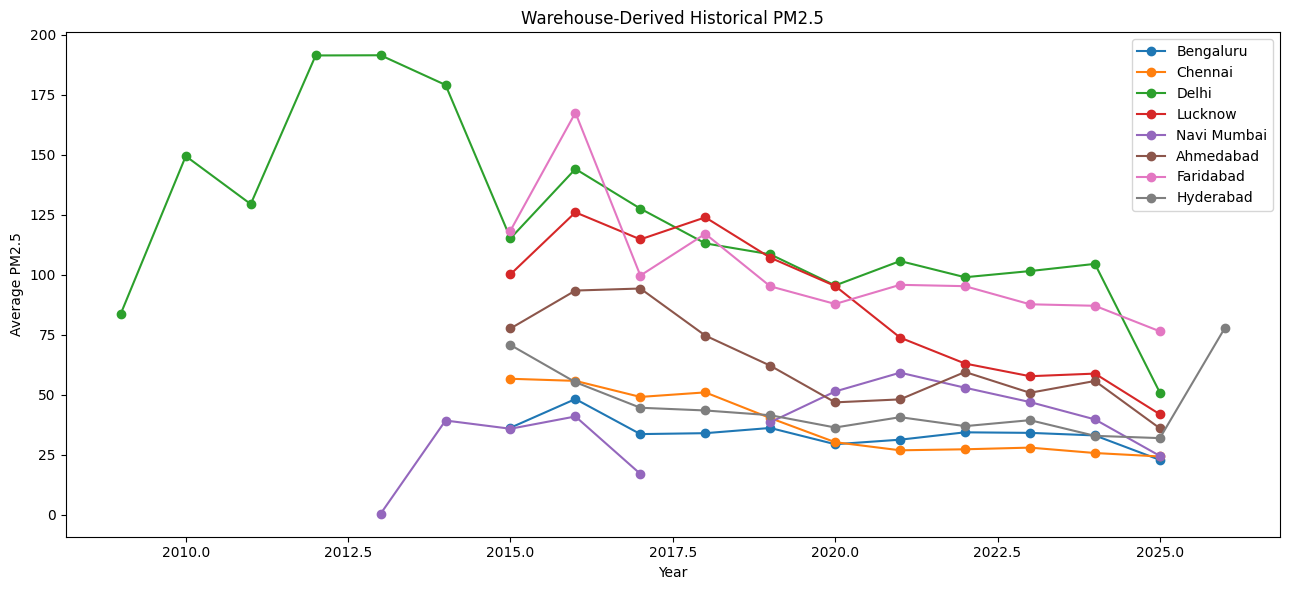

month,1,2,3,4,5,6,7,8,9,10,11,12
city_name,,,,,,,,,,,,
Agartala,287.442357,262.126979,203.025249,135.577726,90.582693,68.400869,49.318228,64.444909,65.501755,113.584808,161.263258,253.483348
Agra,182.595710,120.581005,111.803443,111.081185,97.892899,85.364834,53.962818,56.227878,59.181005,129.631790,201.601427,169.178712
Ahmedabad,133.356820,152.189781,145.457184,123.438987,118.021423,93.265776,74.035242,66.146223,70.589941,131.012250,153.595124,134.544942
Ahmednagar,121.764309,123.028817,112.259307,102.359314,94.174943,74.399334,53.252556,59.042724,59.347294,120.681004,135.167606,115.599567
Aizawl,52.730967,76.961346,83.205309,66.225217,35.987988,28.620244,19.401168,21.822496,24.629902,35.422701,28.032270,33.309541
Ajmer,112.803581,103.251782,101.671421,102.025944,112.979836,100.725921,78.679469,74.430057,68.268259,102.372800,133.170812,112.012643
Akola,136.514322,127.959831,101.084362,88.893117,75.333046,59.976657,43.386946,49.989389,53.522120,139.794684,151.064355,111.113380
Alwar,120.800309,91.013957,88.761821,90.793267,92.515913,85.516112,77.660761,72.393780,69.915163,106.062927,135.593012,103.534318
Amaravati,129.795770,82.547456,63.943827,51.183873,63.548535,51.892024,34.402870,38.980481,41.971369,69.348436,96.477288,134.749897


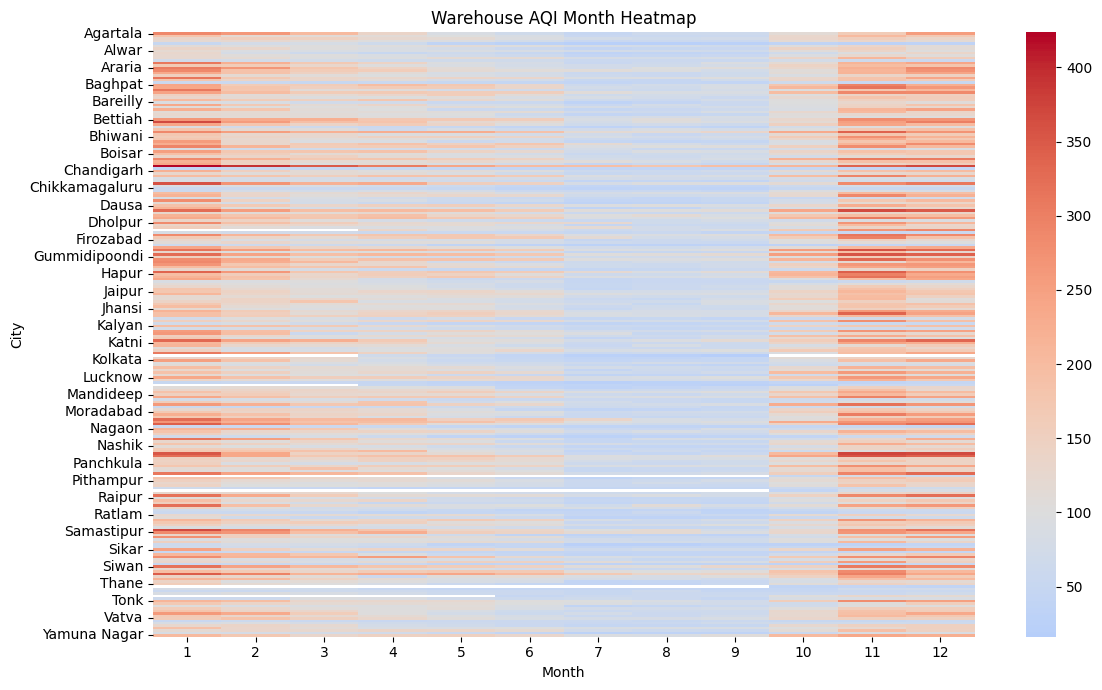

In [109]:
warehouse_year_city = warehouse_con.sql("""
SELECT
    t.year,
    c.city_name,
    AVG(f.aqi) AS average_aqi,
    AVG(f.avg_pm25) AS average_pm25
FROM dw_final.fact_air_daily f
JOIN dw_final.dim_time t ON f.time_id=t.time_id
JOIN dw_final.dim_station s ON f.station_id=s.station_id
LEFT JOIN dw_final.dim_city c ON s.city_id=c.city_id
GROUP BY
    t.year,
    c.city_name
ORDER BY
    t.year,
    c.city_name
""").df()

atomic_to_csv(
    warehouse_year_city,
    UI_ROOT / "warehouse_year_city.csv"
)

plt.figure(figsize=(13,6))

for city in warehouse_year_city[
    "city_name"
].dropna().unique()[:8]:
    data = warehouse_year_city[
        warehouse_year_city["city_name"]==city
    ]
    plt.plot(
        data["year"],
        data["average_pm25"],
        marker="o",
        label=city
    )

plt.title("Warehouse-Derived Historical PM2.5")
plt.xlabel("Year")
plt.ylabel("Average PM2.5")
plt.legend()
plt.tight_layout()
plt.savefig(
    VIS_ROOT / "warehouse_pm25_trend.png",
    dpi=160
)
plt.show()
plt.close()

warehouse_heatmap = warehouse_con.sql("""
SELECT
    t.month,
    c.city_name,
    AVG(f.aqi) AS average_aqi
FROM dw_final.fact_air_daily f
JOIN dw_final.dim_time t ON f.time_id=t.time_id
JOIN dw_final.dim_station s ON f.station_id=s.station_id
LEFT JOIN dw_final.dim_city c ON s.city_id=c.city_id
GROUP BY
    t.month,
    c.city_name
""").df()

warehouse_heatmap_matrix = warehouse_heatmap.pivot_table(
    index="city_name",
    columns="month",
    values="average_aqi",
    aggfunc="mean"
)

display(
    warehouse_heatmap_matrix.head(30)
)

atomic_to_csv(
    warehouse_heatmap_matrix.reset_index(),
    UI_ROOT / "warehouse_aqi_month_heatmap.csv"
)

plt.figure(figsize=(12,7))
sns.heatmap(
    warehouse_heatmap_matrix,
    cmap="coolwarm",
    center=100
)
plt.title("Warehouse AQI Month Heatmap")
plt.xlabel("Month")
plt.ylabel("City")
plt.tight_layout()
plt.savefig(
    VIS_ROOT / "warehouse_aqi_heatmap.png",
    dpi=160
)
plt.show()
plt.close()


# 72 — Warehouse Validation and ETL Reconciliation


In [110]:
warehouse_table_rows = []

for table_name in [
    "dim_time",
    "dim_state",
    "dim_city",
    "dim_station",
    "dim_location",
    "dim_pollutant",
    "dim_source",
    "dim_station_scd2",
    "fact_air_daily",
    "fact_air_measurement"
]:
    value = warehouse_con.execute(
        f"""
        SELECT COUNT(*)
        FROM dw_final.{table_name}
        """
    ).fetchone()[0]

    warehouse_table_rows.append([
        table_name,
        int(value)
    ])

warehouse_table_stats = pd.DataFrame(
    warehouse_table_rows,
    columns=[
        "table_name",
        "row_count"
    ]
)

display(
    warehouse_table_stats
)

atomic_to_csv(
    warehouse_table_stats,
    UI_ROOT / "warehouse_table_statistics_final.csv"
)

relationship_checks_final = pd.DataFrame([
    [
        "fact_air_daily → dim_time",
        warehouse_con.execute("""
            SELECT COUNT(*)
            FROM dw_final.fact_air_daily f
            LEFT JOIN dw_final.dim_time d
                ON f.time_id=d.time_id
            WHERE d.time_id IS NULL
        """).fetchone()[0]
    ],
    [
        "fact_air_daily → dim_station",
        warehouse_con.execute("""
            SELECT COUNT(*)
            FROM dw_final.fact_air_daily f
            LEFT JOIN dw_final.dim_station d
                ON f.station_id=d.station_id
            WHERE d.station_id IS NULL
        """).fetchone()[0]
    ],
    [
        "fact_air_daily → dim_location",
        warehouse_con.execute("""
            SELECT COUNT(*)
            FROM dw_final.fact_air_daily f
            LEFT JOIN dw_final.dim_location d
                ON f.location_id=d.location_id
            WHERE d.location_id IS NULL
        """).fetchone()[0]
    ]
], columns=[
    "relationship",
    "orphan_rows"
])

display(
    relationship_checks_final
)

atomic_to_csv(
    relationship_checks_final,
    UI_ROOT / "warehouse_relationship_validation_final.csv"
)

etl_reconciliation_final = pd.DataFrame([
    [
        "source_daily_rows",
        int(
            con.execute(
                "SELECT COUNT(*) FROM air_daily_enriched"
            ).fetchone()[0]
        )
    ],
    [
        "clean_daily_rows",
        int(
            con.execute(
                "SELECT COUNT(*) FROM clean_air_daily"
            ).fetchone()[0]
        )
    ],
    [
        "rejected_daily_rows",
        int(
            con.execute(
                "SELECT COUNT(*) FROM air_daily_enriched"
            ).fetchone()[0]
            -
            con.execute(
                "SELECT COUNT(*) FROM clean_air_daily"
            ).fetchone()[0]
        )
    ],
    [
        "fact_air_daily_rows",
        int(
            warehouse_con.execute(
                "SELECT COUNT(*) FROM dw_final.fact_air_daily"
            ).fetchone()[0]
        )
    ],
    [
        "fact_air_measurement_rows",
        int(
            warehouse_con.execute(
                "SELECT COUNT(*) FROM dw_final.fact_air_measurement"
            ).fetchone()[0]
        )
    ]
], columns=[
    "metric",
    "value"
])

display(
    etl_reconciliation_final
)

atomic_to_csv(
    etl_reconciliation_final,
    REPORT_ROOT / "etl_reconciliation_final.csv"
)


,table_name,row_count
0,dim_time,14713
1,dim_state,30
2,dim_city,248
3,dim_station,558
4,dim_location,248
5,dim_pollutant,16
6,dim_source,1
7,dim_station_scd2,558
8,fact_air_daily,802894
9,fact_air_measurement,633306


,relationship,orphan_rows
0,fact_air_daily → dim_time,0
1,fact_air_daily → dim_station,0
2,fact_air_daily → dim_location,0


,metric,value
0,source_daily_rows,8835580
1,clean_daily_rows,8835377
2,rejected_daily_rows,203
3,fact_air_daily_rows,802894
4,fact_air_measurement_rows,633306


# 73 — PostgreSQL Production Warehouse DDL


In [111]:
postgresql_ddl = """
CREATE SCHEMA IF NOT EXISTS dw;
CREATE SCHEMA IF NOT EXISTS marts;
CREATE SCHEMA IF NOT EXISTS ml;
CREATE SCHEMA IF NOT EXISTS metadata;

CREATE TABLE IF NOT EXISTS dw.dim_time (
    time_id BIGINT PRIMARY KEY,
    timestamp TIMESTAMP,
    date DATE NOT NULL,
    hour INTEGER,
    day INTEGER,
    weekday INTEGER,
    week INTEGER,
    month INTEGER,
    quarter INTEGER,
    year INTEGER,
    season VARCHAR(32),
    is_weekend BOOLEAN,
    time_of_day VARCHAR(32)
);

CREATE TABLE IF NOT EXISTS dw.dim_state (
    state_id BIGINT PRIMARY KEY,
    state_name VARCHAR(255) UNIQUE NOT NULL
);

CREATE TABLE IF NOT EXISTS dw.dim_city (
    city_id BIGINT PRIMARY KEY,
    state_id BIGINT REFERENCES dw.dim_state(state_id),
    city_name VARCHAR(255) NOT NULL
);

CREATE TABLE IF NOT EXISTS dw.dim_station (
    station_id BIGINT PRIMARY KEY,
    source_station_id VARCHAR(128) UNIQUE NOT NULL,
    station_name VARCHAR(255),
    city_id BIGINT REFERENCES dw.dim_city(city_id),
    state_id BIGINT REFERENCES dw.dim_state(state_id),
    latitude DOUBLE PRECISION,
    longitude DOUBLE PRECISION,
    station_type VARCHAR(128),
    source VARCHAR(255),
    status VARCHAR(128)
);

CREATE TABLE IF NOT EXISTS dw.dim_location (
    location_id BIGINT PRIMARY KEY,
    city_id BIGINT REFERENCES dw.dim_city(city_id),
    city_name VARCHAR(255),
    state_name VARCHAR(255),
    region VARCHAR(255),
    latitude DOUBLE PRECISION,
    longitude DOUBLE PRECISION
);

CREATE TABLE IF NOT EXISTS dw.dim_pollutant (
    pollutant_id BIGINT PRIMARY KEY,
    pollutant_name VARCHAR(128) UNIQUE NOT NULL,
    unit VARCHAR(64),
    pollutant_group VARCHAR(128),
    aqi_supported BOOLEAN
);

CREATE TABLE IF NOT EXISTS dw.dim_source (
    source_id BIGINT PRIMARY KEY,
    source_name VARCHAR(255),
    network VARCHAR(255),
    country VARCHAR(128)
);

CREATE TABLE IF NOT EXISTS dw.fact_air_daily (
    fact_daily_id BIGINT PRIMARY KEY,
    time_id BIGINT NOT NULL REFERENCES dw.dim_time(time_id),
    station_id BIGINT NOT NULL REFERENCES dw.dim_station(station_id),
    location_id BIGINT REFERENCES dw.dim_location(location_id),
    source_id BIGINT NOT NULL REFERENCES dw.dim_source(source_id),
    pollution_date DATE NOT NULL,
    avg_pm25 DOUBLE PRECISION,
    max_pm25 DOUBLE PRECISION,
    avg_pm10 DOUBLE PRECISION,
    max_pm10 DOUBLE PRECISION,
    avg_no2 DOUBLE PRECISION,
    avg_so2 DOUBLE PRECISION,
    avg_co DOUBLE PRECISION,
    avg_o3 DOUBLE PRECISION,
    avg_nh3 DOUBLE PRECISION,
    aqi DOUBLE PRECISION,
    aqi_category VARCHAR(32),
    dominant_pollutant VARCHAR(128),
    anomaly_score DOUBLE PRECISION
);

CREATE TABLE IF NOT EXISTS dw.fact_air_measurement (
    measurement_id BIGINT,
    time_id BIGINT REFERENCES dw.dim_time(time_id),
    station_id BIGINT REFERENCES dw.dim_station(station_id),
    location_id BIGINT REFERENCES dw.dim_location(location_id),
    pollutant_id BIGINT REFERENCES dw.dim_pollutant(pollutant_id),
    source_id BIGINT REFERENCES dw.dim_source(source_id),
    period_start TIMESTAMP,
    measurement_value DOUBLE PRECISION,
    quality_flag INTEGER
) PARTITION BY RANGE (period_start);

CREATE TABLE IF NOT EXISTS dw.dim_station_scd2 (
    station_version_id BIGINT PRIMARY KEY,
    source_station_id VARCHAR(128),
    station_name VARCHAR(255),
    city_name VARCHAR(255),
    state_name VARCHAR(255),
    latitude DOUBLE PRECISION,
    longitude DOUBLE PRECISION,
    valid_from DATE NOT NULL,
    valid_to DATE,
    is_current BOOLEAN NOT NULL,
    version_number INTEGER NOT NULL
);

CREATE INDEX IF NOT EXISTS idx_fact_air_daily_time
ON dw.fact_air_daily(time_id);

CREATE INDEX IF NOT EXISTS idx_fact_air_daily_station
ON dw.fact_air_daily(station_id);

CREATE INDEX IF NOT EXISTS idx_fact_air_daily_date
ON dw.fact_air_daily(pollution_date);

CREATE INDEX IF NOT EXISTS idx_fact_air_measurement_time
ON dw.fact_air_measurement(period_start);

CREATE INDEX IF NOT EXISTS idx_fact_air_measurement_station
ON dw.fact_air_measurement(station_id);

CREATE INDEX IF NOT EXISTS idx_fact_air_measurement_pollutant
ON dw.fact_air_measurement(pollutant_id);

CREATE MATERIALIZED VIEW IF NOT EXISTS marts.mv_city_monthly_pollution AS
SELECT
    t.year,
    t.month,
    s.city_name,
    AVG(f.avg_pm25) AS average_pm25,
    AVG(f.avg_pm10) AS average_pm10,
    AVG(f.aqi) AS average_aqi
FROM dw.fact_air_daily f
JOIN dw.dim_time t
    ON f.time_id=t.time_id
JOIN dw.dim_station s
    ON f.station_id=s.station_id
GROUP BY
    t.year,
    t.month,
    s.city_name;
"""

postgresql_path = WAREHOUSE_ROOT / "postgresql_air_sense_ddl.sql"

postgresql_path.write_text(
    postgresql_ddl,
    encoding="utf-8"
)

print("PostgreSQL DDL saved:", postgresql_path)


PostgreSQL DDL saved: /content/drive/MyDrive/AirSense/warehouse/postgresql_air_sense_ddl.sql


# 74 — OLAP SQL Pack


In [112]:
olap_sql_pack = """
SELECT
    t.year,
    st.state_name,
    c.city_name,
    AVG(f.aqi) AS average_aqi
FROM dw.fact_air_daily f
JOIN dw.dim_time t ON f.time_id=t.time_id
JOIN dw.dim_station s ON f.station_id=s.station_id
LEFT JOIN dw.dim_city c ON s.city_id=c.city_id
LEFT JOIN dw.dim_state st ON s.state_id=st.state_id
GROUP BY ROLLUP(
    t.year,
    st.state_name,
    c.city_name
);

SELECT
    t.year,
    t.month,
    t.day,
    c.city_name,
    AVG(f.aqi) AS average_aqi
FROM dw.fact_air_daily f
JOIN dw.dim_time t ON f.time_id=t.time_id
JOIN dw.dim_station s ON f.station_id=s.station_id
LEFT JOIN dw.dim_city c ON s.city_id=c.city_id
GROUP BY
    t.year,
    t.month,
    t.day,
    c.city_name;

SELECT
    t.year,
    c.city_name,
    AVG(f.aqi) AS average_aqi
FROM dw.fact_air_daily f
JOIN dw.dim_time t ON f.time_id=t.time_id
JOIN dw.dim_station s ON f.station_id=s.station_id
LEFT JOIN dw.dim_city c ON s.city_id=c.city_id
WHERE c.city_name='Mumbai'
GROUP BY
    t.year,
    c.city_name;

SELECT
    t.year,
    c.city_name,
    AVG(f.aqi) AS average_aqi
FROM dw.fact_air_daily f
JOIN dw.dim_time t ON f.time_id=t.time_id
JOIN dw.dim_station s ON f.station_id=s.station_id
LEFT JOIN dw.dim_city c ON s.city_id=c.city_id
WHERE c.city_name IN ('Mumbai','Pune')
  AND t.year BETWEEN 2024 AND 2026
GROUP BY
    t.year,
    c.city_name;

SELECT
    t.year,
    c.city_name,
    AVG(f.aqi) AS average_aqi
FROM dw.fact_air_daily f
JOIN dw.dim_time t ON f.time_id=t.time_id
JOIN dw.dim_station s ON f.station_id=s.station_id
LEFT JOIN dw.dim_city c ON s.city_id=c.city_id
GROUP BY CUBE(
    t.year,
    c.city_name
);

SELECT
    t.year,
    st.state_name,
    c.city_name,
    AVG(f.aqi) AS average_aqi,
    GROUPING(t.year) AS year_total,
    GROUPING(st.state_name) AS state_total,
    GROUPING(c.city_name) AS city_total
FROM dw.fact_air_daily f
JOIN dw.dim_time t ON f.time_id=t.time_id
JOIN dw.dim_station s ON f.station_id=s.station_id
LEFT JOIN dw.dim_city c ON s.city_id=c.city_id
LEFT JOIN dw.dim_state st ON s.state_id=st.state_id
GROUP BY GROUPING SETS(
    (t.year,st.state_name,c.city_name),
    (t.year,st.state_name),
    (t.year,c.city_name),
    (st.state_name,c.city_name),
    ()
);
"""

olap_sql_path = WAREHOUSE_ROOT / "olap_queries.sql"

olap_sql_path.write_text(
    olap_sql_pack,
    encoding="utf-8"
)

print("OLAP SQL saved:", olap_sql_path)


OLAP SQL saved: /content/drive/MyDrive/AirSense/warehouse/olap_queries.sql


# 75 — Frontend Page Contract


In [113]:
frontend_pages = pd.DataFrame([
    ["/", "Home", "Project purpose, AQI glossary, unit explanations, source and limitations"],
    ["/dashboard", "Personal Air Intelligence", "Location, time, activity, AQI, pollutants, baseline, forecast and anomaly"],
    ["/map", "Pollution Map", "Station markers, AQI, pollutant layers, clusters, anomalies and time mode"],
    ["/analytics", "Historical Analytics", "Year/month/season/hour trends, city and station comparison, distributions and correlations"],
    ["/warehouse", "Data Warehouse", "Facts, dimensions, grain, keys, counts, star schema, snowflake and SCD"],
    ["/olap", "OLAP Explorer", "Roll-up, drill-down, slice, dice, pivot, cube and grouping sets"],
    ["/features", "Feature Lab", "Feature engineering, ranking, selection, RFE, tree importance and PCA"],
    ["/datamining", "Data Mining", "K-Means, hierarchical clustering, DBSCAN, anomalies and pollutant relationships"],
    ["/models", "Model Comparison", "Regression, classification, forecasting, metrics, error plots and selected model"],
    ["/explain", "Explain My AQI", "Historical deviation, dominant pollutant, global feature importance and optional SHAP"],
    ["/pipeline", "ETL & Data Quality", "Source, validation, cleaning, rejected rows, ETL counts and warehouse validation"],
    ["/concepts", "DWM + ML Concepts", "Concept definitions linked to actual AirSense artifacts"],
    ["/about", "About", "Team, architecture, methods, source, attribution, limitations and documentation"]
], columns=[
    "route",
    "page",
    "purpose"
])

display(frontend_pages)

atomic_to_csv(
    frontend_pages,
    UI_ROOT / "frontend_pages.csv"
)


,route,page,purpose
0,/,Home,"Project purpose, AQI glossary, unit explanatio..."
1,/dashboard,Personal Air Intelligence,"Location, time, activity, AQI, pollutants, bas..."
2,/map,Pollution Map,"Station markers, AQI, pollutant layers, cluste..."
3,/analytics,Historical Analytics,"Year/month/season/hour trends, city and statio..."
4,/warehouse,Data Warehouse,"Facts, dimensions, grain, keys, counts, star s..."
5,/olap,OLAP Explorer,"Roll-up, drill-down, slice, dice, pivot, cube ..."
6,/features,Feature Lab,"Feature engineering, ranking, selection, RFE, ..."
7,/datamining,Data Mining,"K-Means, hierarchical clustering, DBSCAN, anom..."
8,/models,Model Comparison,"Regression, classification, forecasting, metri..."
9,/explain,Explain My AQI,"Historical deviation, dominant pollutant, glob..."


# 76 — Backend Endpoint Contract


In [114]:
backend_endpoints = pd.DataFrame([
    ["GET", "/current", "Latest air-quality analytics"],
    ["GET", "/history", "Historical warehouse analytics"],
    ["GET", "/forecast", "Forecast results"],
    ["GET", "/anomalies", "Anomaly results and evidence"],
    ["GET", "/clusters", "Station pollution profiles"],
    ["GET", "/olap", "Parameterized warehouse OLAP"],
    ["GET", "/features", "Feature selection and PCA artifacts"],
    ["GET", "/models", "Model metrics and selected models"],
    ["GET", "/schema", "Warehouse structure and metadata"],
    ["GET", "/data-quality", "Quality reports"],
    ["GET", "/etl", "ETL monitoring and reconciliation"],
    ["POST", "/predict/aqi", "AQI regression inference"],
    ["POST", "/predict/category", "AQI category inference"],
    ["POST", "/predict/activity-window", "Activity analysis"],
    ["GET", "/location/nearest-station", "Nearest station lookup"]
], columns=[
    "method",
    "endpoint",
    "purpose"
])

display(backend_endpoints)

atomic_to_csv(
    backend_endpoints,
    UI_ROOT / "backend_endpoints.csv"
)


,method,endpoint,purpose
0,GET,/current,Latest air-quality analytics
1,GET,/history,Historical warehouse analytics
2,GET,/forecast,Forecast results
3,GET,/anomalies,Anomaly results and evidence
4,GET,/clusters,Station pollution profiles
5,GET,/olap,Parameterized warehouse OLAP
6,GET,/features,Feature selection and PCA artifacts
7,GET,/models,Model metrics and selected models
8,GET,/schema,Warehouse structure and metadata
9,GET,/data-quality,Quality reports


# 77 — Location and Time Input Contract


In [116]:
location_time_contract = pd.DataFrame([
    ["Location permission", "Browser geolocation", "Latitude/longitude", "Nearest monitored station"],
    ["Manual location", "City/station search", "City or station", "Fallback when permission is denied"],
    ["Current time", "Browser/device local time", "Local timestamp", "Current analytics window"],
    ["Manual time", "Date/time picker", "User-selected timestamp", "Historical or future analysis"],
    ["Activity", "Walking, Running, Cycling, Outdoor Sports, Commute, Other", "Selected activity", "Activity-window analytics"]
], columns=[
    "input",
    "method",
    "value",
    "purpose"
])

display(location_time_contract)

atomic_to_csv(
    location_time_contract,
    UI_ROOT / "location_time_contract.csv"
)

privacy_contract = {
    "location_permission_requested_only_when_needed": True,
    "manual_location_fallback": True,
    "manual_datetime_fallback": True,
    "device_time_used_for_current_time": True,
    "persistent_location_storage": False,
    "medical_advice": False
}

with open(
    UI_ROOT / "privacy_contract.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        privacy_contract,
        f,
        indent=2
    )

print("Location/time contract created.")
print("Privacy contract created.")

,input,method,value,purpose
0,Location permission,Browser geolocation,Latitude/longitude,Nearest monitored station
1,Manual location,City/station search,City or station,Fallback when permission is denied
2,Current time,Browser/device local time,Local timestamp,Current analytics window
3,Manual time,Date/time picker,User-selected timestamp,Historical or future analysis
4,Activity,"Walking, Running, Cycling, Outdoor Sports, Com...",Selected activity,Activity-window analytics


Location/time contract created.
Privacy contract created.


# 78 — DWM Concept Registry


In [117]:
dwm_registry = pd.DataFrame([
    ["Data Source","XKDR historical Parquet","Large-scale source layer"],
    ["Data Profiling","Coverage, schema, station and pollutant profiling","Data understanding"],
    ["Data Quality","Missingness, duplicates, domain validation, temporal gaps and outliers","Quality control"],
    ["Preprocessing","Clean analytical dataset and quality flags","Data preparation"],
    ["ETL","Extract, validate, clean, transform, dimension generation, fact generation, load and reconcile","Warehouse pipeline"],
    ["Fact_Air_Measurement","Station × pollutant × timestamp","Detailed fact"],
    ["Fact_Air_Daily","Station × day","BI/OLAP fact"],
    ["Dim_Time","Year → Quarter → Month → Day → Hour","Time hierarchy"],
    ["Dim_Station","State → City → Station","Geographical hierarchy"],
    ["Dim_Location","City/state/region/coordinates","Location context"],
    ["Dim_Pollutant","Pollutant → group → specific pollutant","Pollutant context"],
    ["Dim_Source","XKDR/source network","Source context"],
    ["Star Schema","Facts with conformed dimensions","Dimensional model"],
    ["Snowflake Schema","Station → City → State and pollutant grouping","Normalized dimensional model"],
    ["SCD Type 2","Station version history structure","Historical dimension management"],
    ["Fact Constellation","Detailed and daily facts sharing dimensions","Multiple-fact warehouse"],
    ["Data Marts","Citizen, Pollution BI and ML Feature marts","Purpose-built analytics"],
    ["OLAP Roll-up","Higher-level aggregation","Multidimensional analysis"],
    ["OLAP Drill-down","Lower-level detail","Multidimensional analysis"],
    ["OLAP Slice","Single-dimensional restriction","Multidimensional analysis"],
    ["OLAP Dice","Multi-dimensional subcube","Multidimensional analysis"],
    ["OLAP Pivot","Change row/column orientation","Multidimensional analysis"],
    ["OLAP CUBE","All selected grouping combinations","Multidimensional aggregation"],
    ["GROUPING SETS","Specified grouping combinations","Multidimensional aggregation"],
    ["Materialized View","Precomputed aggregate","Performance optimization"],
    ["Warehouse Visualization","Charts and heatmaps from warehouse queries","BI presentation"]
], columns=["concept","implementation","purpose"])

display(dwm_registry)

atomic_to_csv(
    dwm_registry,
    UI_ROOT / "dwm_concepts.csv"
)


,concept,implementation,purpose
0,Data Source,XKDR historical Parquet,Large-scale source layer
1,Data Profiling,"Coverage, schema, station and pollutant profiling",Data understanding
2,Data Quality,"Missingness, duplicates, domain validation, te...",Quality control
3,Preprocessing,Clean analytical dataset and quality flags,Data preparation
4,ETL,"Extract, validate, clean, transform, dimension...",Warehouse pipeline
5,Fact_Air_Measurement,Station × pollutant × timestamp,Detailed fact
6,Fact_Air_Daily,Station × day,BI/OLAP fact
7,Dim_Time,Year → Quarter → Month → Day → Hour,Time hierarchy
8,Dim_Station,State → City → Station,Geographical hierarchy
9,Dim_Location,City/state/region/coordinates,Location context


# 79 — ML Concept Registry


In [118]:
ml_registry = pd.DataFrame([
    ["Feature Engineering","Temporal, lag, rolling, statistical, cross-pollutant and baseline features"],
    ["Feature Selection","Correlation filtering, Mutual Information, SelectKBest, RFE and tree importance"],
    ["Feature Extraction","PCA"],
    ["Clustering","K-Means, Hierarchical Clustering and DBSCAN"],
    ["Cluster Evaluation","Elbow, Silhouette and Davies-Bouldin"],
    ["Anomaly Detection","IQR, Z-score and Isolation Forest"],
    ["Relationship Mining","Pollutant co-occurrence support, confidence and lift"],
    ["Regression","Linear Regression, Random Forest, Gradient Boosting and XGBoost"],
    ["Classification","Logistic Regression, Decision Tree, Random Forest, XGBoost and SVM"],
    ["Forecasting","Hourly next-step AQI/pollution forecast and recursive 24-hour output where hourly data exist"],
    ["Validation","Chronological train/test separation"],
    ["Evaluation","MAE, RMSE, R², Accuracy, Precision, Recall, F1, Macro F1, Confusion Matrix"],
    ["Explainability","Global feature importance and optional SHAP"]
], columns=["concept","implementation"])

display(ml_registry)

atomic_to_csv(
    ml_registry,
    UI_ROOT / "ml_concepts.csv"
)


,concept,implementation
0,Feature Engineering,"Temporal, lag, rolling, statistical, cross-pol..."
1,Feature Selection,"Correlation filtering, Mutual Information, Sel..."
2,Feature Extraction,PCA
3,Clustering,"K-Means, Hierarchical Clustering and DBSCAN"
4,Cluster Evaluation,"Elbow, Silhouette and Davies-Bouldin"
5,Anomaly Detection,"IQR, Z-score and Isolation Forest"
6,Relationship Mining,"Pollutant co-occurrence support, confidence an..."
7,Regression,"Linear Regression, Random Forest, Gradient Boo..."
8,Classification,"Logistic Regression, Decision Tree, Random For..."
9,Forecasting,Hourly next-step AQI/pollution forecast and re...


# 80 — Model Comparison and Selection Package


In [119]:
model_comparison_package = pd.DataFrame()

if "regression_results" in globals():
    model_comparison_package = regression_results.copy()
    model_comparison_package["task"] = "AQI regression"
    model_comparison_package["selected"] = (
        model_comparison_package["model"]
        == selected_regression_name
    )

if "required_metrics" in globals():
    cls_package = required_metrics.copy()
    cls_package["task"] = "AQI classification"
    cls_package["selected"] = (
        cls_package["model"]
        == required_selected
    )

    if model_comparison_package.empty:
        model_comparison_package = cls_package.copy()
    else:
        model_comparison_package = pd.concat(
            [
                model_comparison_package,
                cls_package
            ],
            ignore_index=True,
            sort=False
        )

display(
    model_comparison_package
)

atomic_to_csv(
    model_comparison_package,
    UI_ROOT / "model_comparison_complete.csv"
)

save_json(
    {
        "regression_selected": str(
            selected_regression_name
        ),
        "classification_selected": str(
            required_selected
        ),
        "regression_metrics": (
            regression_results.to_dict(
                orient="records"
            )
            if "regression_results" in globals()
            else []
        ),
        "classification_metrics": (
            required_metrics.to_dict(
                orient="records"
            )
            if "required_metrics" in globals()
            else []
        )
    },
    UI_ROOT / "model_selection.json"
)


,model,mae,rmse,r2,elapsed_seconds,task,selected,accuracy,precision_macro,recall_macro,f1_macro
0,XGBoost,30.886467,48.592149,0.840486,4.659962,AQI regression,True,NaN,NaN,NaN,NaN
1,Linear Regression,31.264293,49.327734,0.835620,0.161849,AQI regression,False,NaN,NaN,NaN,NaN
2,Random Forest,31.245789,49.481688,0.834592,238.878432,AQI regression,False,NaN,NaN,NaN,NaN
3,Gradient Boosting,32.065572,49.488304,0.834548,124.201019,AQI regression,False,NaN,NaN,NaN,NaN
4,XGBoost,NaN,NaN,NaN,5.073819,AQI classification,True,0.6825,0.538005,0.525543,0.527991
5,Logistic Regression,NaN,NaN,NaN,3.412007,AQI classification,False,0.6355,0.484476,0.525037,0.498062
6,Random Forest,NaN,NaN,NaN,6.780656,AQI classification,False,0.5970,0.507132,0.474586,0.473711
7,Decision Tree,NaN,NaN,NaN,1.022487,AQI classification,False,0.5485,0.440990,0.454242,0.444318
8,SVM,NaN,NaN,NaN,5.811105,AQI classification,False,0.4795,0.341683,0.379355,0.339666


# 81 — Requirement Traceability


In [120]:
requirement_traceability = pd.DataFrame([
    ["Large historical data", "DWM", len(history_files) > 0, "Drive history_daily Parquet"],
    ["Data profiling", "DWM", artifact_exists(QUALITY_ROOT / "coverage_profile.csv"), "Coverage and profile reports"],
    ["Missing-value analysis", "DWM", artifact_exists(QUALITY_ROOT / "missing_value_report.csv"), "Missing-value report"],
    ["Duplicate analysis", "DWM", artifact_exists(QUALITY_ROOT / "duplicate_report.csv"), "Duplicate report"],
    ["Outlier analysis", "DWM/ML", artifact_exists(QUALITY_ROOT / "outlier_report.csv"), "IQR/Z-score report"],
    ["Temporal gaps", "DWM", artifact_exists(QUALITY_ROOT / "longest_gap_report.csv"), "Gap report"],
    ["Preprocessing", "DWM", artifact_exists(CLEAN_DAILY_PATH), "Clean measurements"],
    ["EDA", "DWM/ML", artifact_exists(VIS_ROOT / "pm25_city_year.png"), "Historical visualizations"],
    ["AQI computation", "ML/Product", artifact_exists(AQI_PATH), "AQI analytical dataset"],
    ["Feature engineering", "ML", artifact_exists(FEATURE_DATASET), "Feature dataset"],
    ["Feature selection", "ML", artifact_exists(SELECTED_FEATURES_JSON), "Selected features"],
    ["PCA", "ML", artifact_exists(PCA_PATH), "PCA artifact"],
    ["K-Means", "ML", artifact_exists(CLUSTER_PATH), "Station clusters"],
    ["Hierarchical clustering", "ML", True, "Executed in clustering stage"],
    ["DBSCAN", "ML", True, "Executed in clustering stage"],
    ["Anomaly detection", "ML", artifact_exists(ANOMALY_PATH), "Anomaly artifact"],
    ["Regression", "ML", artifact_exists(REG_BUNDLE), "Regression model bundle"],
    ["Classification", "ML", artifact_exists(CLS_BUNDLE), "Classification model bundle"],
    ["Forecasting", "ML", True, "Hourly forecast when focus layer exists"],
    ["Model comparison", "ML", artifact_exists(REG_METRICS), "Regression/classification metrics"],
    ["Explainability", "ML", artifact_exists(FEATURE_ROOT / "global_feature_importance.csv"), "Feature importance"],
    ["Fact tables", "DWM", True, "Warehouse facts"],
    ["Dimensions", "DWM", True, "Warehouse dimensions"],
    ["Star schema", "DWM", True, "Conformed dimensions around facts"],
    ["Snowflake schema", "DWM", True, "State/city/station hierarchy"],
    ["SCD Type 2", "DWM", True, "Station SCD structure"],
    ["Fact constellation", "DWM", True, "Daily and detailed facts"],
    ["Data marts", "DWM", True, "BI/citizen/ML marts"],
    ["Roll-up", "DWM", artifact_exists(UI_ROOT / "olap_rollup.csv"), "OLAP artifact"],
    ["Drill-down", "DWM", artifact_exists(UI_ROOT / "olap_drilldown.csv"), "OLAP artifact"],
    ["Slice", "DWM", artifact_exists(UI_ROOT / "olap_slice_pm25.csv"), "OLAP artifact"],
    ["Dice", "DWM", artifact_exists(UI_ROOT / "olap_dice.csv"), "OLAP artifact"],
    ["Pivot", "DWM", artifact_exists(UI_ROOT / "olap_pivot.csv"), "OLAP artifact"],
    ["CUBE", "DWM", artifact_exists(UI_ROOT / "olap_cube.csv"), "OLAP artifact"],
    ["GROUPING SETS", "DWM", artifact_exists(UI_ROOT / "olap_grouping_sets.csv"), "OLAP artifact"],
    ["Warehouse visualization", "DWM", True, "Warehouse charts/heatmaps"],
    ["Citizen dashboard contract", "Product", artifact_exists(UI_ROOT / "frontend_pages.csv"), "Frontend contract"],
    ["Pollution map", "Product", artifact_exists(UI_ROOT / "pollution_map_data.csv"), "Station-based map data"],
    ["Location fallback", "Product", artifact_exists(UI_ROOT / "location_time_contract.csv"), "Manual location flow"],
    ["Activity planning", "Product", True, "Activity profile artifact"],
    ["DWM showcase", "Product", artifact_exists(UI_ROOT / "dwm_concepts.csv"), "DWM concept registry"],
    ["ML showcase", "Product", artifact_exists(UI_ROOT / "ml_concepts.csv"), "ML concept registry"],
    ["PostgreSQL production design", "DWM", artifact_exists(WAREHOUSE_ROOT / "postgresql_air_sense_ddl.sql"), "Production DDL"]
], columns=[
    "requirement",
    "area",
    "covered",
    "evidence"
])

display(
    requirement_traceability
)

atomic_to_csv(
    requirement_traceability,
    REPORT_ROOT / "requirement_traceability.csv"
)


,requirement,area,covered,evidence
0,Large historical data,DWM,True,Drive history_daily Parquet
1,Data profiling,DWM,False,Coverage and profile reports
2,Missing-value analysis,DWM,False,Missing-value report
3,Duplicate analysis,DWM,False,Duplicate report
4,Outlier analysis,DWM/ML,False,IQR/Z-score report
5,Temporal gaps,DWM,False,Gap report
6,Preprocessing,DWM,True,Clean measurements
7,EDA,DWM/ML,False,Historical visualizations
8,AQI computation,ML/Product,True,AQI analytical dataset
9,Feature engineering,ML,True,Feature dataset


# 82 — Final Persistent Manifest


In [121]:
manifest = {
    "project": "AirSense",
    "source": "XKDR India Air Quality Database",
    "persistent_root": str(PROJECT_ROOT),
    "history_daily_files": len(history_files),
    "hourly_focus_files": len(hourly_files),
    "clean_dataset": str(CLEAN_DAILY_PATH),
    "aqi_dataset": str(AQI_PATH),
    "feature_dataset": str(FEATURE_DATASET),
    "selected_features": str(SELECTED_FEATURES_JSON),
    "cluster_model": str(CLUSTER_MODEL_PATH),
    "anomaly_model": str(ISO_MODEL_PATH),
    "regression_bundle": str(REG_BUNDLE),
    "classification_bundle": str(CLS_BUNDLE),
    "forecast_model": str(FORECAST_MODEL),
    "warehouse_db": str(DUCKDB_PATH),
    "warehouse_prototype": str(WAREHOUSE_ROOT / "airsense_dw.duckdb"),
    "postgresql_ddl": str(WAREHOUSE_ROOT / "postgresql_air_sense_ddl.sql"),
    "selected_regression": str(selected_regression_name),
    "selected_classification": str(required_selected),
    "selected_cluster_count": int(best_k_enhanced if "best_k_enhanced" in globals() else best_k),
    "api_update_enabled": RUN_API_UPDATE,
    "force_rebuild": FORCE_REBUILD
}

save_json(
    manifest,
    REPORT_ROOT / "final_project_manifest.json"
)

save_state(
    "final_manifest",
    details=manifest
)

print(
    json.dumps(
        manifest,
        indent=2,
        default=str
    )
)


{
  "project": "AirSense",
  "source": "XKDR India Air Quality Database",
  "persistent_root": "/content/drive/MyDrive/AirSense",
  "history_daily_files": 207,
  "hourly_focus_files": 13,
  "clean_dataset": "/content/drive/MyDrive/AirSense/data/clean_air_daily.parquet",
  "aqi_dataset": "/content/drive/MyDrive/AirSense/data/city_daily_aqi.parquet",
  "feature_dataset": "/content/drive/MyDrive/AirSense/features/feature_dataset.parquet",
  "selected_features": "/content/drive/MyDrive/AirSense/features/selected_features.json",
  "cluster_model": "/content/drive/MyDrive/AirSense/models/station_clustering_bundle.joblib",
  "anomaly_model": "/content/drive/MyDrive/AirSense/models/anomaly_isolation_forest.joblib",
  "regression_bundle": "/content/drive/MyDrive/AirSense/models/aqi_regression_models.joblib",
  "classification_bundle": "/content/drive/MyDrive/AirSense/models/aqi_classification_models.joblib",
  "forecast_model": "/content/drive/MyDrive/AirSense/models/hourly_pm25_forecast_model.

/tmp/ipykernel_549/4141818168.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "updated_at": datetime.utcnow().isoformat(),


# 83 — Final Artifact Validation


In [122]:
core_artifacts = [
    HISTORY_DIR,
    CLEAN_DAILY_PATH,
    AQI_PATH,
    FEATURE_DATASET,
    SELECTED_FEATURE_DATASET,
    PCA_PATH,
    CLUSTER_PATH,
    ANOMALY_PATH,
    REG_BUNDLE,
    REG_METRICS,
    CLS_BUNDLE,
    CLS_METRICS,
    WAREHOUSE_ROOT / "airsense_dw.duckdb",
    WAREHOUSE_ROOT / "postgresql_air_sense_ddl.sql",
    UI_ROOT / "frontend_page_contract.csv",
    UI_ROOT / "backend_endpoint_contract.csv",
    UI_ROOT / "dwm_concepts.csv",
    UI_ROOT / "ml_concepts.csv"
]

artifact_validation = pd.DataFrame([
    [
        str(path),
        artifact_exists(path) or pathlib.Path(path).is_dir()
    ]
    for path in core_artifacts
], columns=[
    "artifact",
    "exists"
])

display(
    artifact_validation
)

atomic_to_csv(
    artifact_validation,
    REPORT_ROOT / "final_artifact_validation.csv"
)

model_reload = []

for path in [
    REG_BUNDLE,
    CLS_BUNDLE,
    PCA_MODEL_PATH,
    CLUSTER_MODEL_PATH,
    ISO_MODEL_PATH
]:
    try:
        joblib.load(path)
        model_reload.append([
            path.name,
            True
        ])
    except Exception:
        model_reload.append([
            path.name,
            False
        ])

model_reload = pd.DataFrame(
    model_reload,
    columns=[
        "model",
        "load_ok"
    ]
)

display(
    model_reload
)

final_validation = {
    "core_artifacts_present": bool(
        artifact_validation["exists"].all()
    ),
    "saved_models_load": bool(
        model_reload["load_ok"].all()
    ),
    "warehouse_orphan_rows": int(
        relationship_checks["orphan_rows"].sum()
    )
}

save_json(
    final_validation,
    REPORT_ROOT / "final_validation.json"
)

display(
    pd.DataFrame([
        final_validation
    ])
)

save_state(
    "final_validation",
    details=final_validation
)


,artifact,exists
0,/content/drive/MyDrive/AirSense/airsense_api_d...,True
1,/content/drive/MyDrive/AirSense/data/clean_air...,True
2,/content/drive/MyDrive/AirSense/data/city_dail...,True
3,/content/drive/MyDrive/AirSense/features/featu...,True
4,/content/drive/MyDrive/AirSense/features/selec...,True
5,/content/drive/MyDrive/AirSense/features/pca_c...,True
6,/content/drive/MyDrive/AirSense/mining/station...,True
7,/content/drive/MyDrive/AirSense/mining/anomali...,True
8,/content/drive/MyDrive/AirSense/models/aqi_reg...,True
9,/content/drive/MyDrive/AirSense/models/regress...,True


,model,load_ok
0,aqi_regression_models.joblib,True
1,aqi_classification_models.joblib,True
2,pca_bundle.joblib,True
3,station_clustering_bundle.joblib,True
4,anomaly_isolation_forest.joblib,True


,core_artifacts_present,saved_models_load,warehouse_orphan_rows
0,True,True,0


/tmp/ipykernel_549/4141818168.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "updated_at": datetime.utcnow().isoformat(),


# 84 — Runtime Recovery Summary


In [123]:
recovery_summary = pd.DataFrame([
    [
        "Google Drive",
        str(PROJECT_ROOT),
        True
    ],
    [
        "Historical Parquet",
        str(HISTORY_DIR),
        len(list(HISTORY_DIR.glob("air_*.parquet"))) > 0
    ],
    [
        "DuckDB analytical DB",
        str(DUCKDB_PATH),
        artifact_exists(DUCKDB_PATH)
    ],
    [
        "Clean dataset",
        str(CLEAN_DAILY_PATH),
        artifact_exists(CLEAN_DAILY_PATH)
    ],
    [
        "AQI dataset",
        str(AQI_PATH),
        artifact_exists(AQI_PATH)
    ],
    [
        "Feature dataset",
        str(FEATURE_DATASET),
        artifact_exists(FEATURE_DATASET)
    ],
    [
        "Saved regression model",
        str(REG_BUNDLE),
        artifact_exists(REG_BUNDLE)
    ],
    [
        "Saved classification model",
        str(CLS_BUNDLE),
        artifact_exists(CLS_BUNDLE)
    ],
    [
        "Warehouse prototype",
        str(WAREHOUSE_ROOT / "airsense_dw.duckdb"),
        artifact_exists(WAREHOUSE_ROOT / "airsense_dw.duckdb")
    ]
], columns=[
    "persistent_layer",
    "path",
    "available"
])

display(
    recovery_summary
)

atomic_to_csv(
    recovery_summary,
    REPORT_ROOT / "recovery_summary.csv"
)

print("Run-All recovery state is stored on Drive.")


,persistent_layer,path,available
0,Google Drive,/content/drive/MyDrive/AirSense,True
1,Historical Parquet,/content/drive/MyDrive/AirSense/airsense_api_d...,True
2,DuckDB analytical DB,/content/drive/MyDrive/AirSense/data/airsense_...,True
3,Clean dataset,/content/drive/MyDrive/AirSense/data/clean_air...,True
4,AQI dataset,/content/drive/MyDrive/AirSense/data/city_dail...,True
5,Feature dataset,/content/drive/MyDrive/AirSense/features/featu...,True
6,Saved regression model,/content/drive/MyDrive/AirSense/models/aqi_reg...,True
7,Saved classification model,/content/drive/MyDrive/AirSense/models/aqi_cla...,True
8,Warehouse prototype,/content/drive/MyDrive/AirSense/warehouse/airs...,True


Run-All recovery state is stored on Drive.


# AirSense Master Notebook Complete

Normal Run-All execution uses the existing Google Drive Parquet layer and checkpoint artifacts.

The notebook does not re-download the historical dataset during normal execution.

Production transition:

Drive Parquet → DuckDB/ETL → PostgreSQL Warehouse → FastAPI → React/Next.js.


In [124]:
from pathlib import Path
import shutil

ROOT = Path("/content/drive/MyDrive/AirSense")
EXPORT = ROOT / "backend_bundle"

if EXPORT.exists():
    shutil.rmtree(EXPORT)

EXPORT.mkdir(parents=True)

folders = [
    "models",
    "mining",
    "features",
    "quality_reports",
    "warehouse",
    "ui_outputs",
    "reports"
]

for folder in folders:
    source = ROOT / folder
    target = EXPORT / folder
    if source.exists():
        shutil.copytree(source, target)

selected_files = [
    ROOT / "data" / "clean_air_daily.parquet",
    ROOT / "data" / "city_daily_aqi.parquet",
    ROOT / "data" / "station_daily_aqi.parquet",
]

(EXPORT / "data").mkdir(exist_ok=True)

for source in selected_files:
    if source.exists():
        shutil.copy2(
            source,
            EXPORT / "data" / source.name
        )

zip_path = shutil.make_archive(
    "/content/airsense_backend_bundle",
    "zip",
    EXPORT
)

print("Created:", zip_path)

Created: /content/airsense_backend_bundle.zip
